<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
International Roaming Price-Change
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>Estimating the 12-month revenue effect of a proposed international roaming price increase</i>
</div>


<div style="border: 2px solid #9B4A4A; padding: 10px 16px;">
    
## Disclosure

* This notebook reconstructs the methodology used in a client engagement for portfolio purposes. It does not reproduce the engagement or its results.
* The &#36;100 million contribution described in the Introduction provides business context and is not a modeled result.
* All data and modeled results are synthetic. The approximately 50,000-account customer base was designed to support the same type of modeling methodology. All coefficients, distributions, revenue estimates, and segment profiles are derived from synthetic data and do not reflect the engagement’s actual findings.
* The actual findings, production Power BI deliverable, and client-identifying details are proprietary and are not reproduced here.
* What remains faithful to the original work is the methodology, including the model architecture, estimation choices, simulation design, and segmentation logic.
    
</div>

---

## Abstract

- This study evaluates a proposed international roaming price increase using a synthetic book of approximately 50,000 accounts. It estimates the resulting 12-month roaming revenue and identifies the customers most likely to reduce or stop purchasing roaming coverage.
- Two machine-learning models estimate how customers respond to price. The first predicts whether a trip receives no, partial, or full coverage, while the second estimates how much coverage is purchased when a customer reduces usage. A simulation then evaluates revenue across a range of prices and economic conditions.
- The study also runs a joint stronger-response sensitivity case, which amplifies the estimated price response and reduction depth to account for evidence that the fitted models may understate both. The recommendation is read from this cautious case.
- A uniform price increase captures nearly all the projected revenue opportunity. Customer segmentation therefore adds more value by identifying where roaming-pass retention efforts may be needed than by supporting different prices for different customers.
- Under the cautious case, modeled 12-month roaming revenue is maximized by a **15% increase** and then declines toward the +20% cap; the as-fitted models still favour the cap. The recommendation is therefore a 15% increase, and it depends on taking at face value the regional-holdout evidence that the fitted price response is understated.
- The results are delivered through an interactive scenario tool that allows users to explore changes in price, customer mix, and economic conditions without requiring a follow-up study.


---

## Introduction

**Business Question:** International roaming was assigned a &#36;100 million contribution toward closing a larger company-wide revenue gap. How much of that target could be delivered through a price change, and how would different customer groups be affected?

**Data and Scope:** The study uses a synthetic customer base of approximately 50,000 accounts, built and validated in a separate data notebook. It estimates the effect on roaming revenue over 12 months. Wireless churn was evaluated separately and excluded because its estimated impact on the study was negligible.

**Study Design:** The study follows four connected stages, with each stage supplying the information required by the next.

| Section                                | Business question answered                                                                                                                                                                            |
| :------------------------------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 01 · Customer Response (State Model)   | How likely is a customer to choose no, partial, or full roaming coverage for a trip at each candidate price?                                                                                          |
| 02 · Purchase Amount (Magnitude Model) | When a customer chooses partial coverage, how much roaming coverage will be purchased?                                                                                                                  |
| 03 · 12-Month Revenue Simulation       | How much 12-month roaming revenue could result at each price under different economic and market conditions, using both fitted and conservative assumptions? |
| 04 · Customer Segments and Delivery    | Which customer groups are most affected, and how can business users explore the results through an interactive scenario tool?                                                                         |

**Model Requirements:**
Because the predicted probabilities enter directly into the revenue calculation, they must be well calibrated, not merely useful for ranking customers. The price-response curves must also be monotonic and smooth, ensuring that simulated customer behavior remains economically coherent across the full range of candidate prices.


---

## Initialize Environment

Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.


In [1]:
# Standard Library
from pathlib import Path

# Numerical & Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: Models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Preprocessing & Calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: Metrics
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plot Styles
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})


In [3]:
# File Management
DATA = Path('data/synthetic')

def load(name):
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False

FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants & Builders
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}

DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0

def reconstruct_label(df, day_thresh = DAY_THRESH):

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y

def build_features(df):

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # Basline: africa
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out

def prior_trip_count(df):

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)

def load_trips(with_macro = True):

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t


In [5]:
# Numeric Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]

def LL(y_true, P):
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)

def softmax(eta):
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)

def logp(p):
    
    return np.log(np.clip(p, 1e-9, 1.0))

def price_shift_logodds(sweep, mult, ref = 1.0):
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)

def apply_price_shift(P0, shift, response_scale = 1.0):
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">

# 01 · The State Model

**Purpose:** Predicts, for each customer trip and candidate price, the probability distribution across three coverage levels: null, partial, and full. Because these probabilities enter directly into the revenue calculation, they must be well calibrated. A predicted 15% probability of partial coverage should correspond to approximately 15% of comparable trips receiving partial coverage.

**Architecture:** The model has two stages. Stage 1 estimates baseline state probabilities at the standard price using customer and trip characteristics other than price, including travel behavior, number of lines, plan tier, tenure, region, and time of year. Stage 2 adds a constrained price component that estimates how those probabilities change as price rises or falls. This produces smooth, monotonic price-response curves across the candidate range, including intermediate prices not previously charged.

| Stage | Method                                           | Why this model                                                                                                                                                                                          |
| :---- | :----------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| 1     | Gradient-Boosted Trees on Non-Price Features     | Customer behavior is nonlinear and includes many interactions, making a flexible tree model appropriate. At this stage, predictive flexibility is more important than coefficient-level interpretation. |
| 2     | Multinomial Logit with Stage 1 as a Fixed Offset | The price response must remain smooth and monotonic across the candidate range. A sign-constrained parametric price component provides that structure, while a tree alone does not.                     |

**Design Requirements:** Because the model feeds a forward-looking revenue simulation, its outputs must be statistically reliable and economically coherent. The following requirements govern how labels are constructed, data is split, probabilities are calibrated, the price effect is estimated, and the response is tested beyond the original market-test regions.

| Requirement                               | Where                              | Reasoning                                                                                                                                                                                                        |
| :---------------------------------------- | :--------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Labels Reconstructed from Observed Data   | Label Construction                 | The behavioral state is not recorded and must be derived from observed trip quantities, including days and lines purchased relative to days and lines traveled.                                                  |
| Time-Based Split                          | Train, Calibration, and Test Split | The model is used to forecast future behavior, so training, calibration, and testing are separated in time. A random split could allow future patterns to influence model development and overstate performance. |
| Calibrated Probabilities                  | Final Probability Model            | The revenue calculation multiplies each probability by a dollar value, so probabilities must be accurate in level, not merely useful for ranking customers.                                                      |
| Price Effect Separated from Other Factors | Price Identification and Stage 2   | Historical price changes were not assigned randomly. The price relationship must therefore be estimated after accounting for factors such as customer characteristics, region, and season.                       |
| Monotonic and Smooth Price Response       | Stage 2                            | The modeled response must move consistently in the expected direction as price changes, without implausible reversals or discontinuities.                                                                        |
| Price-Response Transferability Tested     | Regional Holdout                   | The price response is estimated using market-test data but applied to the full customer base, so its performance must be tested outside the original market-test regions.                                        |


In [6]:
# Load data
trips = load_trips()
print(f'{len(trips):,} trips \u00b7 {trips.account_id.nunique():,} accounts \u00b7 {trips.month.nunique()} months')

94,579 trips · 29,406 accounts · 24 months


---

## 1 · Label Reconstruction

**Purpose:** Reconstructs three coverage levels from observed trip data because the underlying behavioral state is not recorded in production.

**Design Notes:** Coverage level is the outcome predicted by the state model and an input to the revenue calculation. For each customer trip and candidate price, the model estimates the probability of no, partial, or full coverage. Expected revenue is then calculated by multiplying each probability by the revenue associated with that coverage level.

Coverage level is determined by the share of travel days covered by a pass and whether every traveling line is covered:

* `day coverage = days_bought / days_traveled`
* `line coverage = lines_active / lines_traveling`

| Level     | Meaning                                                      | Rule per trip                                                            | Notes                                                                                               |
| :-------- | :----------------------------------------------------------- | :----------------------------------------------------------------------- | :-------------------------------------------------------------------------------------------------- |
| `null`    | No roaming pass purchased                                    | `days_bought == 0`                                                       | The customer traveled but used an alternative such as a local SIM, eSIM, Wi-Fi, or no connectivity. |
| `partial` | Some coverage purchased, but below the full-coverage rule    | Day coverage is below 70%, or at least one traveling line is not covered | May result from fewer covered days, fewer covered lines, or both.                                   |
| `full`    | Broad trip coverage under the study’s operational definition | Day coverage is at least 70%, and every traveling line is covered        | The 70% threshold defines broad trip coverage without requiring a pass for every travel day.        |

**Observations:**

1. Full coverage represents 77.8% of reconstructed labels, followed by partial coverage at 12.1% and null coverage at 10.1%.
2. Because full coverage dominates the labels, calibrated probabilities and class-specific performance measures are more informative than overall classification accuracy.


In [7]:
# Label Reconstruction
trips['y'] = reconstruct_label(trips)
y = trips['y'].to_numpy()
yi = np.array([IDX[v] for v in y])

display(trips['y'].value_counts(normalize=True).round(4).to_frame('share of trips').rename_axis(None))

# Synthetic-data completeness: every trip here is a finished, fully-observed record.
# There is no partial-reporting or still-in-progress trip in this synthetic book, so
# label construction never has to guess at an incomplete one.
assert trips[['days_traveled', 'lines_traveling', 'days_bought', 'lines_active']].notna().all().all(), \
    'incomplete trip record found; synthetic data is assumed fully observed'
SYNTHETIC_DATA_COMPLETE = True


,share of trips
full,0.7775
partial,0.1214
null,0.1011


---

## 2 · Feature Selection and Data Audits

**Purpose:** Builds the non-price feature set for Stage 1 after auditing candidate fields for target leakage and redundant information.

**Design Notes:** Stage 1 uses only information available when the prediction is made. Fields that define the outcome, become known during or after the trip, or exist only in the synthetic data are excluded from the model.

1. **Target leakage audit:** The following fields are excluded from the predictive feature set:
   * `days_bought` and `lines_active` help define the reconstructed coverage label.
   * `pass_revenue` and `account_lost` are outcomes observed after roaming activity occurs.
   * `state` is the target variable created during label reconstruction.
   * `price_sensitivity` and `travel_propensity` are latent variables used to generate the synthetic data and would not be observable in production.
   * `days_traveled` and `lines_traveling` are final trip outcomes: coverage is metered day by day as an account's lines connect to foreign towers, so both fields are only fully known once the trip is over, not at the point the model's prediction is used. They are retained for post-trip label construction, historical revenue calculations, and simulation exposure assumptions, but are excluded from the probability model.


2. **Price separation:** `price_multiplier` and `log_price` are excluded from Stage 1. Price enters only in Stage 2, allowing the study to estimate a smooth and monotonic price response separately from the customer and trip characteristics captured in Stage 1.


3. **Redundancy audit:** `substitute_ease` is a synthetic measure of how easily customers in a region can avoid purchasing the company’s roaming pass by using alternatives such as a local SIM, eSIM, or Wi-Fi. Because it is assigned entirely from `region`, it contains no independent information.
   * Including both `substitute_ease` and region would duplicate the same signal.
   * Interacting `substitute_ease` with price could make regional differences in the market test appear to be a general substitution effect.
   * The field is excluded from both stages. Region remains in Stage 1, while Stage 2 estimates the price response without this deterministic regional proxy.


4. **Historical feature construction:** `prior_trips` uses an expanding time window. Only trips from earlier months are counted, preventing information from future trips from entering the model.

**Observations:**

1. The leakage audit excludes label-defining, downstream, post-trip, and synthetic latent fields.
2. `substitute_ease` is fully determined by region and is excluded as redundant.
3. Fifteen non-price features remain for the Stage 1 model.


In [8]:
# Data Audit
ease_by_region = trips.groupby('region')['substitute_ease'].nunique()
print('Distinct substitute_ease Values per Region')
display(ease_by_region.to_frame('distinct values').rename_axis(None))
DETERMINISTIC = bool((ease_by_region == 1).all())
print(f'substitute_ease is a deterministic function of region: {DETERMINISTIC}')

trips['prior_trips'] = prior_trip_count(trips)
trips['log_price'] = np.log(trips['price_multiplier'])

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

LEAKY = {
    'days_bought', 'lines_active', 'pass_revenue', 'account_lost', 'state', 'y',
    'price_sensitivity', 'travel_propensity', 'price_multiplier', 'log_price',
    'days_traveled', 'lines_traveling', 'substitute_ease',
}
assert not (set(X.columns) & LEAKY), 'leakage in the stage-1 feature matrix'

EXPECTED_COLS = [
    'is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
    'region_asia', 'region_caribbean', 'region_central_america', 'region_europe',
    'region_mideast', 'region_oceania', 'region_south_america',
    'month_of_year', 'macro_index', 'prior_trips',
]
assert list(X.columns) == EXPECTED_COLS, f'unexpected Stage 1 feature set: {list(X.columns)}'
assert np.isfinite(X.to_numpy()).all(), 'missing or non-finite values in the Stage 1 feature matrix'
print(f'Stage 1: {X.shape[1]} non-price features')


Distinct substitute_ease Values per Region


,distinct values
africa,1
asia,1
caribbean,1
central_america,1
europe,1
mideast,1
oceania,1
south_america,1


substitute_ease is a deterministic function of region: True
Stage 1: 15 non-price features


---

## 3 · Split by Time

**Purpose:** Separates trips chronologically so predictive accuracy and probability calibration can be evaluated on later trips that the model did not use for training. Because the market price test ended in month 15, the later periods provide limited direct evidence about the price response; the regional holdout in Section 6.2 provides a complementary test.

**Synthetic-data assumption:** The dataset represents a finalized historical snapshot, and all trips are treated as fully reported. Operational reporting delays are outside the scope of this portfolio study.

**Design Notes:** The split preserves the order in which trips occurred. Separate temporal and regional holdouts are used because model performance over time and price-response generalization are distinct validation questions.

1. **Chronological Slices:** Months are numbered relative to the beginning of the 24-month study period. A separate calibration split allows the probability adjustment to be estimated independently while preserving the test set for an unbiased final evaluation. Calibrating on the training data could preserve the model’s in-sample overconfidence, while calibrating on the test data would contaminate the final evaluation.

| Slice       | Months | Purpose                                        |
| :---------- | -----: | :--------------------------------------------- |
| Train       |   0–15 | Fit the Stage 1 and Stage 2 models             |
| Calibration |  16–19 | Fit the probability calibrator only            |
| Test        |  20–23 | Conduct the final evaluation on untouched data |

2. **Price-Response Validation Limitation:** The market price test ran during months 8 through 15. The calibration and test periods contain only limited naturally occurring price variation.

   * The temporal test set provides a strong evaluation of general predictive accuracy and calibration over time.
   * It provides only limited direct evidence about the model’s price-response curve.
   * The regional holdout in Section 6.2 evaluates whether the price response estimated from the market-test population generalizes to the broader customer book.
   * Temporal and regional holdouts are complementary and answer different validation questions.


3. **Evaluation Population:** The split is performed by trip month rather than by account. An account may therefore appear in more than one period if it has multiple trips. This design evaluates predictions for future trips from the customer book, not generalization to an entirely new set of customers.

**Observations:** An off-standard trip is a trip observed at a price other than the standard price.

1. **Train Months 0–15:** 54,045 trips, 22,624 accounts, 38.7% off-standard, and 5 observed price levels.
2. **Calibration Months 16–19:** 22,062 trips, 13,298 accounts, 38.8% off-standard, and 4 observed price levels.
3. **Test Months 20–23:** 18,472 trips, 11,799 accounts, 10.1% off-standard, and 3 observed price levels. The limited off-standard representation restricts how strongly this period can validate the price response.

In [9]:
# Split by Time
month = trips['month'].to_numpy()
tr, ca, te = month <= 15, (month >= 16) & (month <= 19), month >= 20

display(pd.DataFrame({
    'trips': [s.sum() for s in (tr, ca, te)],
    'accounts': [trips.account_id[s].nunique() for s in (tr, ca, te)],
    'off-standard %': [round((trips.price_multiplier[s] != 1.0).mean(), 3) for s in (tr, ca, te)],
    'price levels': [trips.price_multiplier[s].nunique() for s in (tr, ca, te)],
}, index = ['train (0-15)', 'calib (16-19)', 'test (20-23)']))

# Base-rate benchmark: fixed at TRAIN-period class shares only, then scored against
# test outcomes. Using the full dataset's shares here would let the benchmark see
# the test period's own label mix, which is exactly what a naive predictor could not.
base = trips.loc[tr, 'y'].value_counts(normalize=True).reindex(CLASSES).to_numpy()
BASE_LL = LL(y[te], np.tile(base, (te.sum(), 1)))
print(f'Benchmark: log loss of a constant, train-period base-rate predictor: {BASE_LL:.4f}')
print('Any model above this is actively harmful, whatever its other metrics say.')


,trips,accounts,off-standard %,price levels
train (0-15),54045,22624,0.387,5
calib (16-19),22062,13298,0.388,4
test (20-23),18472,11799,0.101,3


Benchmark: log loss of a constant, train-period base-rate predictor: 0.6809
Any model above this is actively harmful, whatever its other metrics say.


---

## 4 · Price-Effect Identification and Confounding Checks

**Purpose:** Assesses whether the estimated customer response reflects the effect of price rather than regional or time-related differences. This is separate from evaluating how accurately the model predicts individual outcomes.

**Design Notes:** A credible price coefficient must be supported by price variation that is not fully explained by where or when a trip occurred. Three model specifications show how the estimate changes as progressively stronger controls are introduced.

1. **Sources of price variation:** Price changed through three mechanisms during the historical study period:

   * A market test in Europe and Asia-Pacific during months 8 through 15
   * A separate promotional window
   * Limited residual price movement outside those programs

   These sources are not assumed to represent randomized price assignment unless supported by the market-test design.


2. **Identification specifications:** Each specification uses a different portion of the observed price variation.

| Specification | Controls         | Price variation used                                                         | Role                                                                          |
| ------------- | ---------------- | ---------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Unadjusted    | None                                  | All observed price variation                                                                     | Shows the estimate before accounting for customer, regional, or time-related differences |
| Controlled    | Customer attributes, region, and month | Variation remaining after customer attributes and additive regional and monthly patterns are removed | Provides the primary benchmark for Stage 2                                          |
| Saturated     | Customer attributes, region × month   | Price differences within the same region and month                                               | Provides the most restrictive robustness check                                          |

3. **Interpretation:** The difference between the unadjusted and controlled estimates indicates how much of the apparent price response can be attributed to regional and time-related confounding. Agreement between the controlled and saturated point estimates suggests that the benchmark is not highly sensitive to the more restrictive controls, but statistical uncertainty must also be considered.

4. **Connection to Stage 2:** Stage 2 should produce a price response broadly consistent with the controlled benchmark when both estimates use the same outcome definition, reference state, price transformation, estimation population, and weighting. If the specifications are not directly comparable on the coefficient scale, the comparison should use predicted probability changes at representative price levels.

5. **Post-trip information:** `days_traveled` and `lines_traveling` may be used to reconstruct outcomes, but they are not included as controls or price interactions in any identification specification.

**Observations:**

1. The unadjusted null-state coefficient is 3.12, compared with 1.89 in the controlled specification. The controls remove about 39% of the unadjusted estimate (reported confounding share 0.394), indicating meaningful confounding.
2. The confounding share for the partial state is much smaller, 0.034, so most of the partial-state price coefficient survives the controls.
3. The controlled and saturated point estimates are broadly similar, suggesting that the controlled specification is a reasonable benchmark for Stage 2. This conclusion should also be evaluated using the estimates’ confidence intervals.
4. The reported coefficients are model-scale estimates rather than direct percentage-point changes in customer behavior. Their business effect is evaluated by comparing predicted state probabilities across representative price levels.


In [10]:
# Identify price effect
def logit_price_effect(spec):
    '''naive: log_price alone. controlled: naive + customer controls + region + month.
    saturated: naive + customer controls + region-by-month cells (no separate region/
    month mains, which region-by-month already subsumes).'''
    cust_cols = [
        'is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
        'prior_trips'
    ]
    D = pd.DataFrame({'log_price': trips.loc[tr, 'log_price']})

    if spec in ('controlled', 'saturated'):
        D = pd.concat(
            [D, X.loc[tr, cust_cols],
             pd.get_dummies(trips.loc[tr, 'region'], prefix='reg', drop_first=True),
             pd.get_dummies(trips.loc[tr, 'month'], prefix='m', drop_first=True)], axis=1
        )
    if spec == 'saturated':
        rm = trips.loc[tr, 'region'].astype(str) + '_' + trips.loc[tr, 'month'].astype(str)
        D = pd.concat(
            [D[['log_price'] + cust_cols], pd.get_dummies(rm, prefix='rm', drop_first=True)], axis=1
        )

    D = D.astype(float)
    sc = StandardScaler().fit(D)
    m = LogisticRegression(max_iter=3000, C=1.0).fit(sc.transform(D), y[tr])
    j = list(D.columns).index('log_price')
    return pd.Series(m.coef_[:, j] / sc.scale_[j], index=m.classes_), D.shape[1]


ident, kdim = {}, {}
for spec in ['naive', 'controlled', 'saturated']:
    eff, k = logit_price_effect(spec)
    ident[spec], kdim[spec] = eff, k

ident = pd.DataFrame(ident).reindex(CLASSES)  # full precision kept until display below
labelled = ident.round(3).rename(columns={s: f'{s} (k={kdim[s]})' for s in ident.columns})
print('Effect of log(price) on each state')
display(labelled)

# Relative to the reference class: the form stage 2 will estimate
rel = ident.sub(ident.loc['full'], axis=1)
print("Same effects relative to 'full' (the stage-2 reference)")
display(rel.round(3).rename(columns={s: f'{s} (k={kdim[s]})' for s in rel.columns}))
TARGET = rel['controlled']

# Confounding is computed on the same relative-to-'full' scale as TARGET, not the raw
# per-class coefficients above, since those two scales are not directly comparable.
conf = ((rel['naive'] - rel['controlled']).abs() / rel['naive'].abs()).round(3)
print("Share of the naive effect attributable to confounding (relative to 'full')")
display(conf.to_frame('share').rename_axis(None))


Effect of log(price) on each state


,naive (k=1),controlled (k=29),saturated (k=134)
null,1.145,0.358,0.278
partial,0.829,1.174,1.430
full,-1.974,-1.532,-1.708


Same effects relative to 'full' (the stage-2 reference)


,naive (k=1),controlled (k=29),saturated (k=134)
null,3.119,1.890,1.987
partial,2.803,2.707,3.139
full,0.000,0.000,0.000


Share of the naive effect attributable to confounding (relative to 'full')


,share
null,0.394
partial,0.034
full,NaN


---

## 5 · Stage 1: Baseline Behavior without Price

**Purpose:** Estimates each trip’s baseline probabilities of `null`, `partial`, and `full` coverage at the standard price. Stage 2 uses these baseline probabilities as its starting point and then estimates how they change at alternative prices.

**Design Notes:** Stage 1 captures differences associated with customer, account, calendar, and market characteristics without allowing price to enter directly or indirectly. Its primary objective is to produce reliable baseline probabilities rather than assign every trip to a single most-likely class.

1. **Model:** Stage 1 uses a multiclass gradient-boosted tree model with 15 non-price features.
   * Price variables are excluded because price enters separately in Stage 2.
   * `days_traveled` and `lines_traveling` are excluded because they are final trip outcomes that may not be known when the prediction is made.
   * Synthetic latent variables, label-defining fields, and downstream outcomes are also excluded.


2. **Training Population:** Stage 1 is fitted only on standard-price trips.
   * The market test aligned price changes with particular region and month combinations.
   * If Stage 1 were fitted across all prices, it could use region and month as indirect indicators of price and absorb variation that Stage 2 is intended to estimate.
   * Restricting the model to standard-price trips preserves the separation between baseline customer behavior and price response.
   * This restriction retains approximately 61% of the original training trips and excludes approximately 39%.


3. **Evaluation Population:** Stage 1 should be evaluated directly on standard-price trips in the test period. The complete two-stage model is evaluated separately across all test-period price levels.


4. **Evaluation Metrics:** Because Stage 1 probabilities feed into later modeling stages, probability quality is more important than most-likely-class accuracy.
   * Multiclass log loss measures the overall quality of the predicted probability distribution.
   * Class-level Brier scores measure probability error for each coverage state.
   * Calibration curves compare predicted and observed outcome rates across probability ranges.
   * Calibration in the large compares average predicted shares with overall observed shares.
   * Per-class AUC is retained as a supplementary measure of how well the model ranks trips within each state.
   * Most-likely-class accuracy is not emphasized because the predominance of `full` coverage would allow a model to achieve apparently strong accuracy by predicting `full` for nearly every trip.


**Observations:**

1. Stage 1 currently trains on 33,127 standard-price trips, representing approximately 61% of the original training sample.
2. The reported test log loss is 0.6786, compared with 0.6809 for the train-period base-rate benchmark. The small improvement indicates that the available non-price features provide limited additional information about coverage outcomes.
3. Per-class AUC is 0.585 for `null`, 0.509 for `partial`, and 0.540 for `full`. These values indicate weak customer-level discrimination, particularly for the `partial` state.
4. Average predicted shares are close to the observed shares across all three states. This supports calibration in the large but does not, by itself, establish calibration across different probability ranges.
5. The weak individual-level discrimination does not prevent Stage 1 from supporting aggregate revenue estimation, but it limits claims about predicting individual customer behavior and should be considered when interpreting the later segmentation.


In [11]:
# Fit Stage 1
S1_TRAIN = tr & (trips['price_multiplier'] == 1.0).to_numpy()
print(f'stage 1 trains on {S1_TRAIN.sum():,} standard-price trips '
      f'({S1_TRAIN.sum() / tr.sum():.0%} of train)\n')

gbm = HistGradientBoostingClassifier(
    max_iter = 400, learning_rate = 0.06, max_leaf_nodes = 31, min_samples_leaf = 40,
    l2_regularization = 1.0, early_stopping = True, validation_fraction = 0.15, random_state = 0,
).fit(X[S1_TRAIN], y[S1_TRAIN])
ORDER = [list(gbm.classes_).index(c) for c in CLASSES]

def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis = 1, keepdims = True)

P0_te = stage1_proba(X[te])
STD_TE = te & (trips['price_multiplier'] == 1.0).to_numpy()
P0_std_te = stage1_proba(X[STD_TE])

print(f'stage 1 log loss (standard-price test, primary) : {LL(y[STD_TE], P0_std_te):.4f}')
print(f'stage 1 log loss (all test trips, secondary)     : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark                              : {BASE_LL:.4f}')

print('Per-class AUC: the diagnostic a constant predictor cannot fake')
auc_tbl = pd.Series(
    {c: roc_auc_score((y[te] == c).astype(int), P0_te[:, i])
    for i, c in enumerate(CLASSES)}, name = 'AUC'
).round(3)

display(auc_tbl.to_frame())

print('Per-class Brier score (secondary, all test trips)')
brier_tbl = pd.Series(
    {c: brier_score_loss((y[te] == c).astype(int), P0_te[:, i])
    for i, c in enumerate(CLASSES)}, name = 'Brier'
).round(4)

display(brier_tbl.to_frame())

print('Aggregate calibration of stage 1')
display(pd.DataFrame(
    {'predicted': P0_te.mean(0), 'observed': [(y[te] == c).mean() for c in CLASSES]}, index = CLASSES
).round(4))


stage 1 trains on 33,127 standard-price trips (61% of train)



stage 1 log loss (standard-price test, primary) : 0.6730
stage 1 log loss (all test trips, secondary)     : 0.6786
base-rate benchmark                              : 0.6809
Per-class AUC: the diagnostic a constant predictor cannot fake


,AUC
null,0.585
partial,0.509
full,0.540


Per-class Brier score (secondary, all test trips)


,Brier
null,0.0899
partial,0.1062
full,0.1718


Aggregate calibration of stage 1


,predicted,observed
null,0.0944,0.1007
partial,0.1235,0.1202
full,0.7821,0.7790


---

## 6 · Stage 2: Price Response from a Fixed Baseline

**Purpose:** Estimates how the Stage 1 baseline probabilities change as price changes. Stage 1 remains fixed, so Stage 2 estimates only the price effects and the permitted differences in price response between consumer and business accounts.

**Design Notes:** Stage 2 adds a simple, smooth price adjustment to the baseline probabilities produced by Stage 1. This preserves the separation between baseline customer behavior and price response while limiting the model’s ability to fit irregular patterns outside the observed prices.

1. **Fixed Stage 1 Baseline:** The logarithms of the Stage 1 probabilities enter Stage 2 as offsets with their coefficients fixed at 1.
   * An offset carries information from an earlier model into a new model without estimating its influence again.
   * Treating the Stage 1 probabilities as ordinary predictors would allow Stage 2 to rescale them and potentially distort the baseline relationship.
   * At the standard price, the price multiplier equals 1 and its logarithm equals zero. The Stage 2 price terms therefore disappear, and the model returns the Stage 1 probabilities unchanged.
   * This preserves the Stage 1 baseline at the standard price. Calibration at alternative prices must still be evaluated for the complete two-stage model.


2. **Price-Response Parameters:** `full` is the reference coverage state. Stage 2 estimates a base price effect and a business-account adjustment for both `null` and `partial`, resulting in four parameters.

$$
\eta_c
=
\log P_c^{(1)}
+
\beta_c \ell
+
\gamma_c \ell I_{\text{business}},
\qquad
\ell=\log(\text{price multiplier}),
\qquad
c\in\{\text{null},\text{partial}\}
$$

In this equation:
* $P_c^{(1)}$ is the Stage 1 baseline probability for coverage state $c$.
* $\ell$ represents the proportional change from the standard price.
* $I_{\text{business}}$ equals 1 for a business account and 0 for a consumer account.
* $\beta_c$ represents the base price response for state $c$.
* $\gamma_c$ represents the additional price response for business accounts.
* The resulting values are converted into probabilities that remain between zero and one and sum to one.

3. **Permitted Interaction:** Business-account status is the only retained price interaction.
   * `lines_traveling`, previously described as party size, is excluded because it is a final trip outcome that may not be known when the prediction is made.
   * `substitute_ease` is excluded because it is determined entirely by region and contains no independent information.
   * The business interaction may be retained only if it satisfies the economic constraints and provides a meaningful difference in held-out performance or predicted price response.


4. **Economic Constraints:** Constraints are applied to both the base price effects and the combined effects for business accounts.
   * A higher price must not increase expected roaming coverage.
   * The probability of `full` coverage must not increase as price rises.
   * The `partial` probability may increase and then decrease as customers move from `full` to `partial` and eventually from `partial` to `null`.
   * Final probability curves must be tested across the complete candidate-price grid. Correct coefficient signs alone do not guarantee economically coherent probability curves.


5. **Comparison with the Identification Benchmark:** Stage 2 coefficients are compared with the controlled estimates from Section 4.
   * The comparison is valid only when both estimates use the same outcome definitions, reference state, price transformation, estimation population, and weighting.
   * Similar estimates support consistency between the two methods but do not, by themselves, prove that the price effect is causal.
   * If the coefficient scales differ, predicted probability changes should be compared instead.


6. **Observed and Candidate Price Ranges:** Results within the historically observed price range represent interpolation. Results outside that range represent extrapolation and depend more heavily on the assumed log-linear price response.

**Observations:**

1. The Stage 2 optimization converged.
2. Relative to the controlled estimates in Section 4, the Stage 2 coefficient ratio is 1.06 for `null` and 0.71 for `partial`. Both fall within the notebook’s current diagnostic reference range of 0.60 to 1.60, indicating broad consistency with the identification benchmark.
3. The consumer and business coefficient combinations satisfy the imposed sign constraints. The final probability curves must also be checked across the complete candidate-price grid.
4. The business interaction is retained in the current specification. Its incremental value should be evaluated using held-out performance and the difference between consumer and business price-response curves.
5. Overall test log loss improves from 0.6786 for Stage 1 to 0.6781 for the combined model. This small aggregate improvement should be interpreted in the context of the test set, where only 10.1% of trips were observed at off-standard prices.
6. Performance should also be reported separately for standard-price trips, off-standard trips, each observed price level, and consumer and business accounts.
7. Calibration of the complete model should be evaluated by coverage state and observed price level rather than inferred from Stage 1 calibration alone.


In [12]:
# Fit Stage 2
FIT_CLASSES = ['null', 'partial']
TERMS = ['log_price', 'lp_x_business']
SIGN = {'null': +1, 'partial': +1}

def price_design(df, mult = None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    return np.column_stack([
        lp,
        lp * df['is_business'].to_numpy().astype(float),
    ])

def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    m = eta.max(axis = 1, keepdims = True)
    lse = m[:, 0] + np.log(np.exp(eta - m).sum(axis=1))
    return -(eta[np.arange(len(yidx)), yidx] - lse).mean() + l2 * (theta ** 2).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []
for c in FIT_CLASSES:
    bounds += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
    bounds += [(-3, 3)]

res = minimize(
    nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args = (logP0_tr, Z_tr, yi[tr]), method = 'L-BFGS-B',
    bounds = bounds, options = {'maxiter': 500}
)

B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

coefs = pd.DataFrame(B, index=FIT_CLASSES, columns = TERMS).round(3)
print(f'converged: {res.success}   NLL: {res.fun:.4f}')
print("Stage-2 price coefficients (relative to 'full')")
display(coefs)

print("Benchmark against §4's identified estimates")
check = pd.DataFrame(
    {'stage 2 base': coefs['log_price'],
    '§4 controlled (rel.)': TARGET.reindex(FIT_CLASSES)}
).round(3)

display(check)
ratio = (check['stage 2 base'] / check['§4 controlled (rel.)']).abs()
print(
    f'\nratio to the identified estimate: ' +
    '  '.join(f'{c}={v:.2f}' for c, v in ratio.items())
)

if ((ratio < 0.6) | (ratio > 1.6)).any():
    print('\nWARNING: stage 2 is not recovering the identified price effect. If the')
    print('ratios are well below 1, stage 1 is still absorbing part of the response.')
    
else:
    print('\nStage 2 recovers the identified effect. The separation is working.')

# --- net effect per row, the sign check that actually matters ---
biz = trips['is_business'].to_numpy().astype(float)
net = {c: B[k, 0] + B[k, 1] * biz for k, c in enumerate(FIT_CLASSES)}

print('Net log-price effect per trip: min / median / max, and wrong-signed share')
net_tbl = pd.DataFrame({
    c: {'min': net[c].min(), 'median': np.median(net[c]), 'max': net[c].max(),
        'wrong sign': (net[c] * SIGN[c] < 0).mean()}
    for c in FIT_CLASSES
}).T.round(4)
display(net_tbl)

WORST = max((net[c] * SIGN[c] < 0).mean() for c in FIT_CLASSES)
if WORST > 0.01:
    print(f'\n{WORST:.1%} of rows carry a wrong-signed net effect. Refitting without')
    print('interactions so the sign is guaranteed everywhere.')
    b2 = []
    for c in FIT_CLASSES:
        b2 += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
        b2 += [(0, 0)]
        
    res = minimize(
        nll, np.zeros(len(FIT_CLASSES) * len(TERMS)), args = (logP0_tr, Z_tr, yi[tr]),
        method = 'L-BFGS-B', bounds = b2, options = {'maxiter': 500}
    )
    
    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
    print(pd.DataFrame(B, index = FIT_CLASSES, columns = TERMS).round(3).to_string())
    
else:
    print('\nAll rows carry the correct sign. Interactions retained.')


def raw_score(Xf, df, mult = None):
    
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
        
    return softmax(eta)


P_te = raw_score(X[te], trips[te])
print(f'\nhybrid log loss (test) : {LL(y[te], P_te):.4f}')
print(f'stage 1 alone          : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark    : {BASE_LL:.4f}')


converged: True   NLL: 0.6813
Stage-2 price coefficients (relative to 'full')


,log_price,lp_x_business
null,1.999,-0.635
partial,1.910,-0.179


Benchmark against §4's identified estimates


,stage 2 base,§4 controlled (rel.)
null,1.999,1.890
partial,1.910,2.707



ratio to the identified estimate: null=1.06  partial=0.71

Stage 2 recovers the identified effect. The separation is working.
Net log-price effect per trip: min / median / max, and wrong-signed share


,min,median,max,wrong sign
null,1.3641,1.3641,1.9994,0.0
partial,1.7306,1.7306,1.9096,0.0



All rows carry the correct sign. Interactions retained.



hybrid log loss (test) : 0.6781
stage 1 alone          : 0.6786
base-rate benchmark    : 0.6809


---

### 6.1 · Price Sweep

**Purpose:** Re-scores the test population across the full candidate-price range to examine how the fitted model behaves before it is used in the revenue simulation. The sweep tests whether the response is smooth, economically coherent, and meaningfully different between consumer and business accounts.

**Design Notes:** Every test trip is scored repeatedly while its customer and trip characteristics remain fixed and only the price changes. This isolates the price response encoded by Stage 2 from changes in the composition of the test population.

1. **Candidate-Price Range:** The model scores each test trip at candidate prices from 10% below to 20% above the standard price.
   * Prices within the historically observed range represent interpolation.
   * Prices outside the observed range represent extrapolation and depend more heavily on the assumed log-linear price response.
   * The chart distinguishes historically observed prices from extrapolated prices.


2. **Economic-Coherence Checks:** The sweep evaluates the final probabilities rather than relying only on coefficient signs.
   * The probability of `null` coverage must not decrease as price rises.
   * The probability of `full` coverage must not increase as price rises.
   * Expected coverage must not increase as price rises.
   * The `partial` probability must remain smooth, but it may rise and then fall as customers move from `full` to `partial` and eventually from `partial` to `null`.
   * All probabilities must remain between zero and one and sum to one at every candidate price.


3. **Segment Comparison:** Consumer and business price-response curves are compared to determine whether the fitted model supports a meaningful difference between the two groups.
   * A difference is evaluated rather than required.
   * Any selective pricing recommendation must depend on the estimated revenue and customer impact, not merely on the existence of different response curves.
   * Uncertainty around the difference should be reported before it is treated as decision-relevant.


4. **Chart Design:** Coverage states use the same colors throughout the notebook, with lower-coverage states shown in red and orange and `full` coverage shown in gray.
   * A vertical reference line identifies the standard price.
   * Markers identify historically observed price levels.
   * Shading distinguishes extrapolated portions of the range.
   * Line styles or direct labels supplement color so the chart remains accessible.

**Observations:**

1. The current sweep reports no direction reversals for the `null` or `full` probability curves, and the response remains smooth across the tested range.
2. Consumer `P(null)` increases by 5.65 percentage points from the lowest to the highest candidate price, compared with an increase of 2.17 percentage points for business accounts.
3. The fitted consumer response is therefore 3.48 percentage points larger across the candidate range. This estimated difference supports further scenario testing but does not, by itself, justify a selective price increase.
4. The direction of the modeled `null` response is consistent with the raw, unadjusted pattern by segment and price. This is a descriptive face-validity check rather than independent confirmation of the price effect.
5. Changes in `P(partial)`, `P(full)`, and expected coverage should be reported alongside `P(null)` to show the complete movement among coverage states.



,null,partial,full
0.90,0.0820,0.1061,0.8119
0.95,0.0882,0.1148,0.7970
1.00,0.0944,0.1235,0.7821
1.05,0.1006,0.1322,0.7672
1.10,0.1067,0.1410,0.7523
1.15,0.1128,0.1497,0.7376
1.20,0.1187,0.1583,0.7230



Monotonicity violations : {'null': 0, 'partial': 0, 'full': 0}
Flat steps (staircase)  : {'null': 0, 'partial': 0, 'full': 0}
Expected-coverage rises  : 0


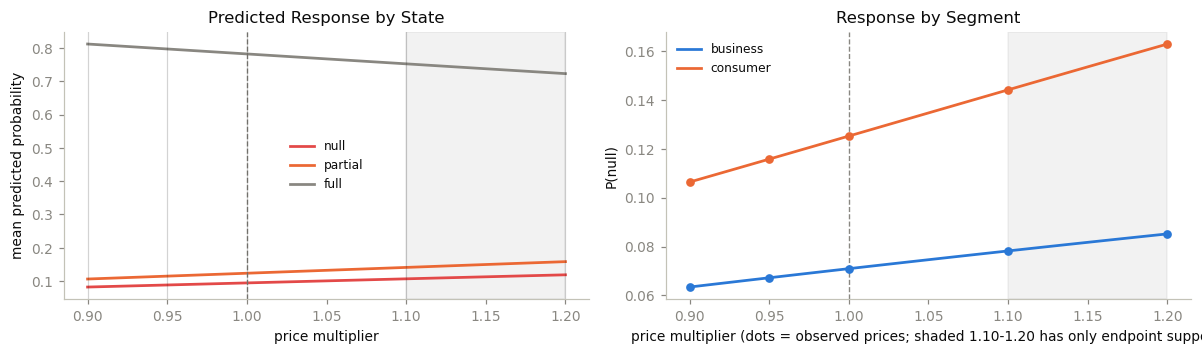

P(null) swing across the range: business +0.0217, consumer +0.0565
The selective-increase premise depends on consumers responding more than business
accounts; whether that difference is decision-relevant is judged by the segmentation.
Observed null rate by segment and price (all trips)


,0.90,0.95,1.00,1.10,1.20
consumer,0.110,0.12,0.127,0.173,0.223
business,0.074,0.07,0.072,0.086,0.094


In [13]:
# Sweep Price Range
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)  # 25 points, 1.25pp apart, endpoints included exactly
OBS_PRICES = [0.90, 0.95, 1.00, 1.10, 1.20]      # prices actually seen in the historical data
SWEEP_SIGN = {'null': +1, 'partial': +1, 'full': -1}

# raw Stage 1 + Stage 2 response (no calibration). Isotonic calibration is a monotone
# per-class transform, so it does not change the shape checks below; the calibrated
# sweep exported in Section 9 is the version downstream sections consume.
sweep = pd.DataFrame(
    [dict(zip(CLASSES, raw_score(X[te], trips[te], m).mean(axis = 0)), price_multiplier = m) for m in GRID]
).set_index('price_multiplier')

display(sweep.iloc[::4].round(4).rename_axis(None))

viol = {c: int(((sweep[c].diff().dropna()) * SWEEP_SIGN[c] < -1e-9).sum()) for c in CLASSES}
flat = {c: int((sweep[c].diff().abs().dropna() < 1e-9).sum()) for c in CLASSES}
exp_cov = sweep['full'] + 0.5 * sweep['partial']          # expected coverage proxy
cov_viol = int((exp_cov.diff().dropna() > 1e-9).sum())
print(f'\nMonotonicity violations : {viol}')
print(f'Flat steps (staircase)  : {flat}')
print(f'Expected-coverage rises  : {cov_viol}')
assert viol['null'] == 0, f"P(null) decreased somewhere in the sweep: {viol['null']} violation(s)"
assert viol['full'] == 0, f"P(full) increased somewhere in the sweep: {viol['full']} violation(s)"
assert cov_viol == 0, f'expected coverage increased somewhere in the sweep: {cov_viol}'
assert np.allclose(sweep.sum(axis=1), 1.0, atol=1e-6), 'sweep probabilities do not sum to one'

i_np = IDX['null']
fig, axes = plt.subplots(1, 2, figsize = (11, 3.3))
for c, col in zip(CLASSES, [RED, ACCENT2, MUTED]):
    axes[0].plot(sweep.index, sweep[c], label = c, color = col, linewidth = 1.8)

axes[0].axvline(1.0, color = MUTED, linestyle = '--', linewidth = 0.9)
for pxx in OBS_PRICES:
    axes[0].axvline(pxx, color = INK, alpha = 0.18, linewidth = 0.8)
axes[0].axvspan(1.10, 1.20, color = INK, alpha = 0.05)     # only endpoints observed here
axes[0].set_xlabel('price multiplier')
axes[0].set_ylabel('mean predicted probability')
axes[0].set_title('Predicted Response by State')
axes[0].legend(frameon = False, fontsize = 8)

spans = {}
for seg, lbl, col in [(1, 'business', ACCENT), (0, 'consumer', ACCENT2)]:
    m = trips[te]['is_business'].to_numpy().astype(int) == seg
    curve = [raw_score(X[te][m], trips[te][m], p)[:, i_np].mean() for p in GRID]
    spans[lbl] = curve[-1] - curve[0]
    axes[1].plot(GRID, curve, color = col, linewidth = 1.8, label = lbl)
    axes[1].scatter(OBS_PRICES,
                    [raw_score(X[te][m], trips[te][m], p)[:, i_np].mean() for p in OBS_PRICES],
                    color = col, s = 22, zorder = 3)

axes[1].axvline(1.0, color = MUTED, linestyle = '--', linewidth = 0.9)
axes[1].axvspan(1.10, 1.20, color = INK, alpha = 0.05)
axes[1].set_xlabel('price multiplier (dots = observed prices; shaded 1.10-1.20 has only endpoint support)')
axes[1].set_ylabel('P(null)')
axes[1].set_title('Response by Segment')
axes[1].legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

print(
    f"P(null) swing across the range: business {spans['business']:+.4f}, "
    f"consumer {spans['consumer']:+.4f}"
)
print('The selective-increase premise depends on consumers responding more than business')
print('accounts; whether that difference is decision-relevant is judged by the segmentation.')

# The raw data's own answer, for comparison
raw_cmp = (
    trips.assign(np_flag = (trips.y == 'null').astype(float))
        .pivot_table(index = 'is_business', columns = 'price_multiplier', values = 'np_flag')
)
raw_cmp.index = raw_cmp.index.map({False: 'consumer', True: 'business'})
print('Observed null rate by segment and price (all trips)')
display(raw_cmp.round(3).rename_axis(None).rename_axis(None, axis = 1))

---

### 6.2 · Regional Price-Response Holdout

**Purpose:** Tests whether the price response estimated from other regions transfers to Asia-Pacific. This complements the temporal holdout by evaluating geographic generalization of the price effect.

**Design Notes:** The holdout is structured to preserve the Asia-Pacific baseline while withholding its market-test price response. This allows differences in the holdout to be interpreted as price-response error rather than a failure to estimate the region’s baseline behavior.

1. **Holdout Construction:**
   * Fit Stage 1 using standard-price trips from all regions, including Asia-Pacific.
   * Fit Stage 2 using price variation from regions other than Asia-Pacific.
   * Exclude Asia-Pacific elevated-price outcomes from calibration, model selection, and Stage 2 coefficient estimation.
   * Evaluate the completed model on Asia-Pacific trips from the market-test period.
   * Use only price levels that have sufficient observed support in both the Stage 2 estimation sample and the Asia-Pacific holdout.


2. **Comparison with the Temporal Holdout:** The temporal test evaluates whether overall predictive performance and calibration remain stable on later trips. The regional holdout evaluates whether a price response learned outside Asia-Pacific transfers to that region. These are complementary validation tests.


3. **Response Comparison:** The holdout compares observed and predicted changes from the standard price rather than relying only on absolute outcome rates.
   * The observed response is the change in the Asia-Pacific outcome rate from the standard price to an elevated price.
   * The predicted response is the corresponding change produced by the fitted model for the same holdout population.
   * Customer and trip characteristics remain fixed while price changes.
   * The response ratio is calculated as:

$$
\text{response ratio}
=
\frac{\text{observed change from the standard price}}
     {\text{predicted change from the standard price}}
$$

    A ratio above 1 indicates that the observed customer response is stronger than the model predicts.


4. **Uncertainty:** Observed and predicted rates, response slopes, and their ratio should be reported with sample sizes and uncertainty intervals. The ratio should be interpreted cautiously when the predicted change is small.


5. **Simulation Sensitivity:** The regional holdout is used to create two simulation scenarios:
   * **Base response:** Uses the fitted Stage 2 price coefficients without adjustment.
   * **Stronger-response sensitivity:** Increases the Stage 2 price response using the holdout ratio.

   The sensitivity factor is applied to the Stage 2 log-price terms, not directly to the final probabilities:

$$
\eta_c^{(s)}
=
\log P_c^{(1)}
+
s\left(
\beta_c\ell
+
\gamma_c\ell I_{\text{business}}
\right)
$$

Here, \(s=1.00\) represents the base model and \(s=1.74\) represents the current stronger-response sensitivity. The probabilities are then recalculated and normalized across all three coverage states.

This method:

* Leaves the standard-price baseline unchanged
* Preserves probabilities between zero and one
* Preserves the requirement that probabilities sum to one
* Allows the adjusted response curves to be retested for smoothness and economic coherence


6. **Interpretation:** The 1.00 and 1.74 cases are sensitivity scenarios, not statistical lower and upper bounds. The 1.74 factor is derived from the Asia-Pacific `null` response and should not be assumed to apply equally to every state, region, segment, or candidate price without further evidence.

**Observations:**

1. At a price multiplier of 1.20, the current model predicts an Asia-Pacific `null` rate of 9.89%, compared with an observed rate of 13.30%. The model underpredicts the observed `null` rate by 3.41 percentage points.
2. Across the held-out price levels, the current observed-to-predicted response ratio is 1.74. This indicates that the observed Asia-Pacific response is stronger than the fitted model predicts.
3. If the same underprediction occurs elsewhere, the base simulation could overstate revenue at higher prices by understating movement toward `null` coverage.
4. The 12-month simulation therefore reports both the unadjusted model response and a stronger-response sensitivity using the current 1.74 factor.
5. The sensitivity result should be presented as a conservative scenario rather than a guaranteed bound on the revenue outcome.


In [14]:
# Regional Holdout
is_asia_pacific = trips['region'].isin(['asia', 'oceania']).to_numpy()
h_tr = tr & ~is_asia_pacific
h_s1 = h_tr & (trips['price_multiplier'] == 1.0).to_numpy()
h_te = is_asia_pacific & trips['month'].between(8, 15).to_numpy()

g_h = HistGradientBoostingClassifier(
    max_iter = 400, learning_rate = 0.06, max_leaf_nodes = 31,
    min_samples_leaf = 40, l2_regularization = 1.0,
    early_stopping = True, validation_fraction = 0.15,
    random_state = 0
).fit(X[h_s1], y[h_s1])

ord_h = [list(g_h.classes_).index(c) for c in CLASSES]

def s1_h(Xf):
    P = np.clip(g_h.predict_proba(Xf)[:, ord_h], 1e-6, None)
    return P / P.sum(axis = 1, keepdims = True)

res_h = minimize(
    nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args = (np.log(s1_h(X[h_tr])), price_design(trips[h_tr]), yi[h_tr]),
    method = 'L-BFGS-B', bounds = bounds, options = {'maxiter': 500}
)

B_h = res_h.x.reshape(len(FIT_CLASSES), len(TERMS))

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])

for k, c in enumerate(FIT_CLASSES):
    eta_h[:, IDX[c]] += Z_h @ B_h[k]
    
P_h = softmax(eta_h)

cmp = (
    pd.DataFrame({
        'price': trips.loc[h_te, 'price_multiplier'].to_numpy(),
        'predicted': P_h[:, i_np],
        'observed': (y[h_te] == 'null').astype(float)
    }).groupby('price').agg(trips = ('observed', 'size'),
    predicted = ('predicted', 'mean'),
    observed = ('observed', 'mean')).round(4)
)

cmp['error'] = (cmp['predicted'] - cmp['observed']).round(4)
print('Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific')
display(cmp.rename_axis(None))

if len(cmp) >= 2:
    pred_slope = cmp['predicted'].iloc[-1] - cmp['predicted'].iloc[0]
    obs_slope = cmp['observed'].iloc[-1] - cmp['observed'].iloc[0]
    RESPONSE_RATIO = float(obs_slope / pred_slope) if abs(pred_slope) > 1e-9 else np.nan
    print(f'\nResponse slope across the held-out price levels')
    print(f'  predicted {pred_slope:+.4f}   observed {obs_slope:+.4f}')
    print(f'  observed / predicted = {RESPONSE_RATIO:.2f}x')
    if RESPONSE_RATIO > 1.25:
        print('\n  The model UNDER-states the price response out of region. The revenue')
        print('  case built on it is optimistic. The simulation must run the price response')
        print(f'  scaled by 1.0 and by {RESPONSE_RATIO:.2f} to bracket the answer.')
    elif RESPONSE_RATIO < 0.8:
        print('\n  The model OVER-states the response out of region; the case is')
        print('  conservative. Bracket it the same way.')
    else:
        print('\n  The response transfers. Applying one price to the whole book is justified.')
else:
    RESPONSE_RATIO = np.nan
    print('\nToo few held-out price levels to estimate a slope.')
    

Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific


,trips,predicted,observed,error
1.1,2687,0.0903,0.118,-0.0277
1.2,2759,0.0989,0.133,-0.0341



Response slope across the held-out price levels
  predicted +0.0086   observed +0.0150
  observed / predicted = 1.74x

  The model UNDER-states the price response out of region. The revenue
  case built on it is optimistic. The simulation must run the price response
  scaled by 1.0 and by 1.74 to bracket the answer.


---

## 7 · Stage 1 Probability Calibration

**Purpose:** Adjusts the raw Stage 1 probabilities so they align more closely with observed coverage rates at the standard price. The calibrated probabilities become the fixed baseline used by Stage 2.

**Design Notes:** Calibration is performed after Stage 1 is fitted and before the Stage 2 price response is estimated. A separate calibration period allows the adjustment to be estimated independently while preserving the test period for the final evaluation.

1. **Calibration Population:** The calibrator uses standard-price trips from months 16 through 19.
   * Standard-price trips are required because Stage 1 represents behavior at the standard price.
   * Including off-standard trips could allow price response to enter the baseline calibration.


2. **Calibration Method:** A separate isotonic regression is fitted for each coverage state.
   * Isotonic regression learns a monotonic mapping between the raw predicted probability and the observed outcome rate.
   * The method can correct probability levels without reversing the model’s ranking.
   * After the three class probabilities are calibrated separately, they are normalized to remain between zero and one and sum to one.
   * Calibration performance is evaluated after normalization.


3. **Calibration Selection:** The standard-price calibration sample is divided chronologically into two portions.
   * The earlier 70% is used to fit a decision-stage calibrator.
   * The later 30% is used to compare the raw and calibrated probabilities.
   * The test period is not used to select the calibration method.

   Calibration is selected when it lowers multiclass Brier score without materially worsening log loss or the Brier score for any coverage state. Brier score measures the squared difference between predicted probabilities and observed outcomes, so lower values indicate more accurate probabilities.


4. **Final Calibrator:** After isotonic calibration is selected, the calibrator is refitted using the full standard-price calibration sample from months 16 through 19.


5. **Connection to Stage 2:** The calibrated Stage 1 probabilities enter Stage 2 as fixed offsets.
   * Stage 2 estimates how those baseline probabilities change with price.
   * At the standard price, the Stage 2 price terms equal zero and the calibrated Stage 1 probabilities remain unchanged.
   * The complete two-stage model is evaluated separately across all observed prices in the untouched test period.


6. **Final Evaluation:** Calibration is assessed using:
   * Multiclass Brier score
   * Class-level Brier scores
   * Multiclass log loss
   * Calibration in the large
   * Calibration curves for `null`, `partial`, and `full`
   * Performance by observed price level after Stage 2 is added

**Observations:**

1. Isotonic calibration improves the Brier score for all three coverage states on the held-out 30% decision sample, so it is selected for the final study model.
2. Before calibration, the average predicted `full` probability is 0.7814, compared with an observed `full` rate of 0.7790. The raw probabilities are therefore already close in aggregate.
3. This aggregate agreement demonstrates calibration in the large but does not establish calibration across different predicted probability ranges.
4. Improvements on the untouched test period are small but consistent with the decision-sample results, supporting the calibration choice.
5. Final reporting should include the raw and calibrated Brier scores, log loss, and calibration curves so the size and consistency of the improvement are visible.



Calibration decision: held-out 30% of the calib window (not test)


,raw,isotonic
null,0.08809,0.08808
partial,0.09225,0.09176
full,0.15956,0.15935


Log loss on the same held-out decision slice


,log loss
raw,0.63846
isotonic,0.63610


Brier score by class on TEST: reporting only, not used for the USE_CAL decision above


,raw,isotonic
null,0.08986,0.08984
partial,0.10614,0.10603
full,0.17159,0.17160


Mean predicted vs observed rate


,observed,raw,isotonic
null,0.1007,0.0947,0.1008
partial,0.1202,0.1239,0.1061
full,0.7790,0.7814,0.7931


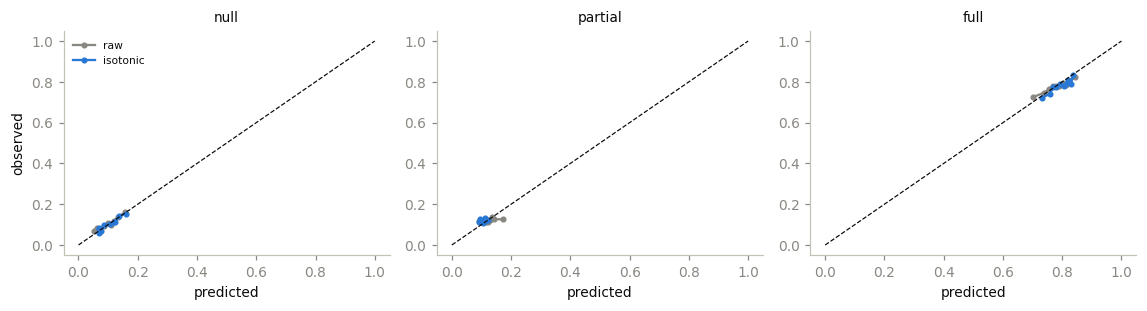

Caution: isotonic is fitted at observed prices. Applying it to a counterfactual
price assumes the correction does not itself depend on price: defensible over a
30-point range, and §6.2 is the check on the underlying response.


In [15]:
# Calibrate Probabilities
def brier_by_class(P, yv):
    return pd.Series({c: brier_score_loss((yv == c).astype(int), P[:, i])
                      for i, c in enumerate(CLASSES)})


def _calibrate_with(cals, P):
    Q = np.clip(np.column_stack([cals[c].predict(P[:, i]) for i, c in enumerate(CLASSES)]),
                1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


# Decide WHETHER to calibrate on a held-out slice of calib, never on test
calib_rng = np.random.default_rng(0)
ca_pos = np.where(ca)[0]
perm = calib_rng.permutation(len(ca_pos))
n_fit = int(0.7 * len(ca_pos))
ca_fit, ca_eval = np.zeros_like(ca), np.zeros_like(ca)
ca_fit[ca_pos[perm[:n_fit]]] = True
ca_eval[ca_pos[perm[n_fit:]]] = True

CALS_decision = {c: IsotonicRegression(out_of_bounds='clip').fit(
                     raw_score(X[ca_fit], trips[ca_fit])[:, i], (y[ca_fit] == c).astype(int))
                 for i, c in enumerate(CLASSES)}
P_ca_eval = raw_score(X[ca_eval], trips[ca_eval])
decision_score = pd.DataFrame({
    'raw': brier_by_class(P_ca_eval, y[ca_eval]),
    'isotonic': brier_by_class(_calibrate_with(CALS_decision, P_ca_eval), y[ca_eval]),
})
print('Calibration decision: held-out 30% of the calib window (not test)')
display(decision_score.round(5))

decision_ll = pd.Series({
    'raw': LL(y[ca_eval], P_ca_eval),
    'isotonic': LL(y[ca_eval], _calibrate_with(CALS_decision, P_ca_eval)),
})
print('Log loss on the same held-out decision slice')
display(decision_ll.to_frame('log loss').round(5))

# Refit the production calibrator on the full calib window
P_ca = raw_score(X[ca], trips[ca])
CALS = {c: IsotonicRegression(out_of_bounds='clip').fit(P_ca[:, i], (y[ca] == c).astype(int))
        for i, c in enumerate(CLASSES)}


def calibrate(P):
    return _calibrate_with(CALS, P)


P_te_cal = calibrate(P_te)
print('Brier score by class on TEST: reporting only, not used for the USE_CAL decision above')
display(pd.DataFrame({'raw': brier_by_class(P_te, y[te]),
                      'isotonic': brier_by_class(P_te_cal, y[te])}).round(5))

print('Mean predicted vs observed rate')
display(pd.DataFrame({'observed': [(y[te] == c).mean() for c in CLASSES],
                      'raw': P_te.mean(0), 'isotonic': P_te_cal.mean(0)},
                     index=CLASSES).round(4))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.9))
for i, (c, ax) in enumerate(zip(CLASSES, axes)):
    for P, lbl, col in [(P_te, 'raw', MUTED), (P_te_cal, 'isotonic', ACCENT)]:
        try:
            frac, mp = calibration_curve((y[te] == c).astype(int), P[:, i],
                                         n_bins=10, strategy='quantile')
            ax.plot(mp, frac, marker='o', ms=3, label=lbl, color=col, linewidth=1.5)
        except ValueError:
            pass
    ax.plot([0, 1], [0, 1], color=INK, linestyle='--', linewidth=0.8)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel('predicted')
    if i == 0:
        ax.set_ylabel('observed')
        ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

print('Caution: isotonic is fitted at observed prices. Applying it to a counterfactual')
print('price assumes the correction does not itself depend on price: defensible over a')
print('30-point range, and §6.2 is the check on the underlying response.')


---

## 8 · Final Scenario Scorer

**Purpose:** Combines the fitted Stage 1 model, selected probability calibrator, Stage 2 price response, and regional response sensitivity into one scoring interface for the 12-month simulation.

**Design Notes:** The calibration method was selected in Section 6 before the test period was evaluated. This section does not choose between raw and calibrated probabilities; it defines how the selected model components are applied consistently to every scenario.

1. **Scoring Interface:** The simulation calls a single function:

```python
score_trips(
    features,
    price_multiplier,
    response_scale = 1.0
)
```

* `features` contains the approved 15 pre-outcome model features.
* `price_multiplier` specifies the candidate price relative to the standard price and may be supplied as a single value or a row-aligned series.
* `response_scale` controls the strength of the Stage 2 price response.
* A value of `1.0` uses the fitted base response.
* A value of `1.74` applies the current stronger-response sensitivity from the regional holdout in Section 6.2.


2. **Input Contract:** The scorer accepts only information available at the model’s defined prediction point.
   * The input schema, data types, and row identifiers are validated before scoring.
   * `days_traveled` and `lines_traveling` are not model inputs.
   * Label-defining fields, downstream outcomes, synthetic latent variables, price fields embedded in the feature matrix, and `substitute_ease` are rejected.
   * Feature construction occurs inside the scoring pipeline so the same transformations are used during model fitting and simulation.


3. **Scoring Sequence:** For every candidate-price scenario, the scorer:
   1. Validates the incoming feature schema.
   2. Generates the raw Stage 1 baseline probabilities.
   3. Applies the selected Stage 1 isotonic calibrator.
   4. Uses the calibrated probabilities as fixed offsets in Stage 2.
   5. Applies the requested price multiplier.
   6. Applies `response_scale` to the Stage 2 log-price terms.
   7. Converts the adjusted values into normalized probabilities for `null`, `partial`, and `full`.
   8. Returns the probabilities with the original row identifiers.


4. **Response Sensitivity:** `response_scale` adjusts the Stage 2 price terms rather than multiplying the final probabilities.
   * At the standard price, the log-price term equals zero, so changing `response_scale` does not change the calibrated Stage 1 baseline.
   * The stronger-response case is a sensitivity scenario, not a statistical upper or lower bound.
   * All adjusted probability curves are rechecked for smoothness and economic coherence before use in the simulation.


5. **Output Contract:** The scorer returns one row for every input trip with:
   * `P(null)`
   * `P(partial)`
   * `P(full)`
   * The original row identifier
   * The applied `price_multiplier`
   * The applied `response_scale`


6. **Automated Validation:** Every scoring run verifies that:
   * No required feature is missing.
   * No prohibited feature enters the model.
   * Input and output rows remain aligned.
   * All probabilities are finite and between zero and one.
   * The three probabilities sum to one for every row.
   * Standard-price probabilities are unaffected by `response_scale`.
   * Expected coverage does not increase as price rises.
   * Results are reproducible for identical inputs and parameters.

**Observations:**

1. The isotonic calibrator was selected using the held-out decision portion of the calibration period, where it improved the Brier score for all three coverage states.
2. On the untouched test period, raw and calibrated performance is effectively tied:
   * Log loss is 0.6781 for raw probabilities and 0.6782 for isotonic probabilities.
   * Mean Brier score is 0.1225 for both at the displayed precision.
3. The currently reported aggregate mean-rate error is 1.2% for raw probabilities and 2.8% for isotonic probabilities. This comparison measures calibration in the large only and does not describe calibration across different probability ranges.
4. The test results do not demonstrate an out-of-time advantage for isotonic calibration. The calibrator remains in the final study model because it was selected using the previously defined calibration decision rule without consulting the test period.
5. Smoothness and economic coherence are evaluated using the full candidate-price sweep in Section 6.1 rather than scoring only three selected prices.
6. The scorer provides the single probability interface used by the 12-month simulation for both the base and stronger-response sensitivity scenarios.


In [16]:
# Choose Production Scorer
cand = {'raw': P_te, 'isotonic': P_te_cal}
score = pd.DataFrame({
    k: {
        'log loss': LL(y[te], P),
        'mean Brier': brier_by_class(P, y[te]).mean(),
        'aggregate prob error': np.abs(P.mean(0) - np.array([(y[te] == c).mean() for c in CLASSES])).sum(),
        'mean AUC': np.mean(
            [roc_auc_score((y[te] == c).astype(int), P[:, i])
            for i, c in enumerate(CLASSES)]
        )
       }
    
    for k, P in cand.items()}).T.round(5)

print('Test-set metrics: reporting only. USE_CAL below was decided in §7 on a')
print('held-out slice of the calib window, before test was ever scored.')
display(score)
print(f'base-rate log loss benchmark: {BASE_LL:.4f}')

# Calibration is selected only if it clears all three bars on the decision slice:
# a lower mean Brier, no single class meaningfully worse on Brier, and log loss not
# meaningfully worse either. The test period plays no part in this decision.
CAL_TOL = 0.02  # tolerated relative deterioration on any one class/metric
mean_brier_improves = decision_score['isotonic'].mean() < decision_score['raw'].mean()
no_class_brier_worse = (decision_score['isotonic'] <= decision_score['raw'] * (1 + CAL_TOL)).all()
ll_not_worse = decision_ll['isotonic'] <= decision_ll['raw'] * (1 + CAL_TOL)

USE_CAL = bool(mean_brier_improves and no_class_brier_worse and ll_not_worse)
print(f'mean Brier improves: {mean_brier_improves}   '
      f'no class-level Brier worse by >{CAL_TOL:.0%}: {no_class_brier_worse}   '
      f'log loss not worse by >{CAL_TOL:.0%}: {ll_not_worse}')
print(f'Using calibration: {USE_CAL}')


def score_trips(Xf, df, mult = None, response_scale = 1.0):
    '''Production interface. `mult` re-prices the book; `response_scale` stretches
    the price response, for the §6.2 bracketing that the simulation needs.'''
    assert list(Xf.columns) == EXPECTED_COLS, 'unexpected feature columns passed to score_trips'
    assert len(Xf) == len(df), 'features and trip frame row counts do not match'
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += response_scale * (Z @ B[k])
    P = softmax(eta)
    P = calibrate(P) if USE_CAL else P
    assert np.isfinite(P).all(), 'non-finite probabilities from score_trips'
    assert (P >= 0).all() and (P <= 1).all(), 'probabilities out of [0, 1] range'
    assert np.allclose(P.sum(axis=1), 1.0, atol=1e-6), 'probabilities do not sum to one'
    return P


print('\nSanity: the test set at three prices')
for m in [0.90, 1.00, 1.20]:
    p = score_trips(X[te], trips[te], m).mean(0)
    print(f'  x{m:.2f}  ' + '  '.join(f'{c} = {v:.4f}' for c, v in zip(CLASSES, p)))
    

Test-set metrics: reporting only. USE_CAL below was decided in §7 on a
held-out slice of the calib window, before test was ever scored.


,log loss,mean Brier,aggregate prob error,mean AUC
raw,0.67809,0.12253,0.01211,0.54714
isotonic,0.67821,0.12249,0.02820,0.54724


base-rate log loss benchmark: 0.6809
mean Brier improves: True   no class-level Brier worse by >2%: True   log loss not worse by >2%: True
Using calibration: True

Sanity: the test set at three prices


  x0.90  null = 0.0894  partial = 0.0968  full = 0.8138


  x1.00  null = 0.1005  partial = 0.1060  full = 0.7935
  x1.20  null = 0.1282  partial = 0.1176  full = 0.7542


---

## 9 · Model Outputs and Downstream Handoff

**Purpose:** Publishes the scored probabilities, account-level price-response curves, post-trip exposure data, and model metadata required by the later sections (the Magnitude Model, the simulation, and the segmentation).

**Design Notes:** The export provides a documented data contract between the modeling and downstream simulation workflows. Predictive features, scored probabilities, and post-trip exposure fields remain separated so later sections cannot accidentally use unavailable information as model input.

1. **Exported Artifacts:**

| Artifact                 | Grain                                                    | Purpose                                                                                                             |
| :----------------------- | :------------------------------------------------------- | :------------------------------------------------------------------------------------------------------------------ |
| `trip_scores`            | One row per trip and scored scenario                     | Stores final probabilities produced by the scenario scorer                                                          |
| `account_price_response` | One row per account, candidate price, and response scale | Stores the response curves used for segmentation and scenario exploration                                           |
| `post_trip_exposure`     | One row per trip                                         | Stores completed-trip exposure fields used for label reconstruction, historical revenue, and simulation assumptions |
| `model_metadata`         | One record per model run                                 | Documents the model, data, price range, and sensitivity assumptions                                                 |
| `validation_summary`     | One row per model, split, and metric                     | Stores the final validation results used throughout the portfolio                                                   |


2. **Trip-level Scored Probabilities:** The `trip_scores` export includes:
   * Synthetic account and trip identifiers
   * Candidate `price_multiplier`
   * Applied `response_scale`
   * `P(null)`
   * `P(partial)`
   * `P(full)`
   * Model version
   * Scoring-run identifier


3. **Account-Level Response Curves:** The `account_price_response` export contains one row for every account, candidate price, and response scenario.
   * Trip-level probabilities are aggregated using a documented and consistent weighting rule.
   * The table preserves the complete response curve rather than a single sensitivity score.
   * The base response uses `response_scale = 1.00`.
   * The current stronger-response sensitivity uses `response_scale = 1.74`, based on the regional holdout in Section 6.2.
   * These are sensitivity scenarios, not statistical lower and upper bounds.


4. **Post-Trip Exposure Data:** `days_traveled` and `lines_traveling` are stored only in the separate `post_trip_exposure` artifact.
   * These fields may support label reconstruction, historical revenue calculations, and simulation exposure assumptions.
   * They are not included in the Stage 1 feature matrix or treated as information available when scoring a trip.


5. **Model Metadata:** The metadata records:
   * Model and scoring-run identifiers
   * Data cutoff date
   * Training, calibration, and test periods
   * Approved Stage 1 feature list
   * Model and calibrator specifications
   * Reference coverage state
   * Standard, observed, and candidate price ranges
   * Base and sensitivity response scales
   * Regional holdout response ratio and source
   * Random seeds
   * Final performance metrics
   * Export timestamp and file format


6. **File Format:** Parquet is the preferred format because it is compact and preserves data types.
   * If a Parquet engine is unavailable, CSV may be used as a fallback.
   * Every CSV export is accompanied by a schema file defining column names, data types, nullability, and expected table grain.
   * Later sections use a shared loader that detects the available format and restores the expected schema.


7. **Validation Before Publication:** Each artifact is validated before it becomes available to later sections.
   * Required columns are present.
   * Keys are unique at the documented grain.
   * Row counts match the expected scenario dimensions.
   * Probabilities are finite, remain between zero and one, and sum to one.
   * Every expected candidate price and response scenario is present.
   * Prohibited Stage 1 fields do not appear in the predictive feature export.
   * Data types match the published schema.
   * Every artifact can be read back successfully after writing.


8. **Reproducible Handoff:** All files use project-relative paths rather than machine-specific locations. Files are written to temporary locations, validated, and then promoted to their final locations so an interrupted export cannot leave a partial downstream artifact.


9. **Portfolio Disclosure:** All exported account and trip identifiers are synthetic. No client-identifying information or proprietary production output is included.

**Observations:**

1. The handoff preserves both the fitted base response and the stronger-response sensitivity identified through the regional holdout.
2. Post-trip exposure fields are isolated from the model-input schema while remaining available for their valid downstream uses.
3. Each later section receives versioned data, model assumptions, and validation results from the same scoring run.
4. Final filenames, row counts, formats, and read-back validation results are reported when the export cell completes.


In [17]:
# Export results
P_all = score_trips(X, trips)
scored = trips[[
    'trip_id', 'account_id', 'month', 'region', 'is_business',
    'lines_traveling', 'days_traveled', 'price_multiplier', 'y'
]].copy()

for i, c in enumerate(CLASSES):
    scored[f'p_{c}'] = P_all[:, i]

scored['slice'] = np.select([tr, ca, te], ['train', 'calib', 'test'], default='?')

# Per-account price response: what the segmentation clusters on
curves = {f'p_null_{m:.2f}': score_trips(X, trips, m)[:, i_np] for m in [0.90, 1.00, 1.10, 1.20]}
resp = pd.DataFrame({'account_id': trips['account_id'].to_numpy(), **curves}) \
    .groupby('account_id').mean().reset_index()
resp['response_span'] = resp['p_null_1.20'] - resp['p_null_0.90']

meta = pd.DataFrame({
    'key': ['day_thresh', 'use_calibration', 'response_ratio', 'base_log_loss', 'test_log_loss'],
    'value': [DAY_THRESH, int(USE_CAL), RESPONSE_RATIO, BASE_LL, LL(y[te], P_te_cal if USE_CAL else P_te)],
})
display(meta.set_index('key').rename_axis(None))

# Per-trip scenario probabilities for the simulation: every forward-panel trip scored
# at every grid price under the base and stronger-response cases. This replaces the
# population-level log-odds shift the simulation used to reconstruct.
SCEN_GRID = np.round(np.linspace(0.90, 1.20, 13), 4)
fwd = (trips['month'] >= trips['month'].max() - 11).to_numpy()
Xf, tf = X[fwd], trips[fwd]
tid_f = tf['trip_id'].to_numpy()
scen = []
for rs, sname in [(1.0, 'base'), (RESPONSE_RATIO, 'stronger')]:
    for m in SCEN_GRID:
        Pm = score_trips(Xf, tf, float(m), rs)
        scen.append(pd.DataFrame({'trip_id': tid_f, 'price_multiplier': float(m),
                                  'response_scenario': sname,
                                  **{f'p_{cc}': Pm[:, i] for i, cc in enumerate(CLASSES)}}))
sim_prob_scenarios = pd.concat(scen, ignore_index=True)

# Section 6.1 shows the raw Stage 1+2 response; the table consumed downstream is the
# final CALIBRATED sweep from the production scorer.
price_sweep_cal = pd.DataFrame(
    [dict(zip(CLASSES, score_trips(X[te], trips[te], m).mean(axis=0)), price_multiplier=m)
     for m in GRID]
).set_index('price_multiplier').reset_index()

display(save_tables({
    'scored_trips': scored,
    'account_price_response': resp,
    'price_sweep': price_sweep_cal,
    'sim_prob_scenarios': sim_prob_scenarios,
    'model_meta': meta,
}))


,value
day_thresh,0.700000
use_calibration,1.000000
response_ratio,1.744186
base_log_loss,0.680880
test_log_loss,0.678214


,rows
scored_trips.parquet,94579
account_price_response.parquet,29406
price_sweep.parquet,25
sim_prob_scenarios.parquet,1365000
model_meta.parquet,5


---


<hr style="border: none; border-top: 2px solid #4A4A4A;">

# 02 · The Magnitude Model

**Purpose:** The State Model predicts which coverage level a trip lands in. To translate those probabilities into revenue, each trip also needs a revenue value for every state at each candidate price. Given the trip’s exposure, the states are treated as follows:

| Level     | Revenue treatment                                                                 |
| :-------- | :-------------------------------------------------------------------------------- |
| `null`    | Zero                                                                              |
| `full`    | The scenario calculation assumes every traveling line and traveled day is covered |
| `partial` | Requires predicted day and line coverage                                          |

The reconstructed `full` label permits day coverage between 70% and 100%, while the revenue calculation treats the state as coverage of every traveled day. This simplifying assumption is evaluated against observed full-state revenue in Section 5.

A ten-day trip with six covered days and one with two covered days both receive the `partial` label, assuming the same line coverage, but they generate materially different revenue. This section supplies that missing magnitude so the simulation can compute:

$$
\mathbb{E}[R_i(m)]
=
\sum_s P_i(s \mid m)\times R_i(s,m)
$$

where \(i\) identifies a trip, \(m\) is the candidate price multiplier, and \(s\) is the coverage state.

**Two magnitude components, fitted only on partial-coverage trips**

| Model         | Target                           | Form                                                              |
| :------------ | :------------------------------- | :---------------------------------------------------------------- |
| Day coverage  | `days_bought / days_traveled`    | Exposure-weighted proportion model, weighted by `days_traveled`   |
| Line coverage | `lines_active / lines_traveling` | Exposure-weighted proportion model, weighted by `lines_traveling` |

**The same separation principle as the State Model**

1. Non-price features enter gradient-boosted regression models fitted on standard-price, partial-coverage trips. Price then enters through a sign-constrained parametric term.
2. The model tests whether higher prices are associated with lower retained coverage among partial-coverage trips. Where a price effect is estimated, the constraints prevent a higher price from implying greater retained coverage. The resulting response is checked for smoothness across the candidate-price grid.

**One source of label contamination remains important throughout.** The labels are reconstructed rather than directly observed. The data notebook measured the partial-coverage rule at approximately 77% precision, so approximately 23% of trips labeled `partial` are false positives rather than deliberate reductions. These cases are shallow by construction: they raise the observed retained-coverage fraction and pull the estimated reduction depth toward zero. Section 4 quantifies this bias and carries the resulting sensitivity into the simulation.


In [18]:
# Load inputs
trips = load_trips()

# Shared price grid for the section's revenue-curve and export cells
GRID = np.round(np.linspace(0.90, 1.20, 13), 4)

print(f'{len(trips):,} trips loaded')

94,579 trips loaded


---
## 1 · Labels, Features, and the Split

**Purpose:** Reuses the State Model’s reconstructed labels, non-price feature definitions, and untouched test period so the State and Magnitude Models remain aligned. Because the Magnitude Model does not require a separate probability-calibration window, months 16 through 19 are included in its development period.

**Design Notes:**

1. **Alignment with the State Model:** The following elements carry over unchanged from Notebook 01:

   * Source trip population
   * Label-reconstruction rule
   * Fifteen non-price feature definitions
   * Leakage exclusions
   * Expanding-window construction of `prior_trips`
   * Months 20 through 23 as the untouched test period

   Reusing these definitions ensures that the state probabilities and conditional magnitudes refer to the same trips and coverage states.


2. **Feature and Target Separation:** The predictive feature matrix excludes label-defining fields, downstream outcomes, synthetic latent variables, and post-trip exposure fields.

   * `days_traveled` and `lines_traveling` are not predictors.
   * They are used only as denominators when constructing the day- and line-coverage targets and when calculating revenue.


3. **Temporal split:** The Magnitude Model uses:

| Slice       | Months | Purpose                                                   |
| :---------- | -----: | :-------------------------------------------------------- |
| Development |   0–19 | Fit the non-price baseline and conditional price response |
| Test        |  20–23 | Evaluate magnitude predictions on untouched later trips   |

Notebook 01 reserves months 16 through 19 for probability calibration. The Magnitude Model has no corresponding calibration stage, so those months remain available for development while the common test period stays untouched.


4. **Conditional Modeling Population:** Labels are reconstructed for all trips, but the Magnitude Model is fitted and evaluated only on trips labeled `partial`.

   * The non-price baseline models use standard-price, partial-coverage trips from the development period.
   * The parametric price terms use all partial-coverage trips from the development period.
   * Final magnitude performance is evaluated on partial-coverage trips in the test period.


5. **Synthetic-Data Assumption:** The synthetic dataset represents a finalized historical snapshot, and all trips are treated as fully reported.

**Observations:**

1. The reconstructed dataset contains 73,535 `full`, 11,478 `partial`, and 9,566 `null` trips.
2. The conditional modeling population contains 9,257 partial-coverage trips in the development period and 2,221 in the untouched test period.
3. These counts describe all partial-coverage trips. The non-price baseline models use the smaller standard-price subset, and sample adequacy is evaluated separately for the day- and line-coverage components because the two outcomes have different levels of observed support.


In [19]:
# Rebuild labels, features, split
trips['y'] = reconstruct_label(trips)
trips['log_price'] = np.log(trips['price_multiplier'])
trips['prior_trips'] = prior_trip_count(trips)

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

month = trips['month'].to_numpy()
tr, te = month <= 19, month >= 20            # no calibration slice needed here
STD = (trips['price_multiplier'] == 1.0).to_numpy()

display(trips['y'].value_counts().to_frame('count').rename_axis(None))
display(pd.DataFrame({
    'train': [((trips.y == 'partial') & tr).sum()],
    'test': [((trips.y == 'partial') & te).sum()],
}, index=['partial']))

,count
full,73535
partial,11478
null,9566


,train,test
partial,9257,2221


---
## 2 · What Partial Coverage Actually Looks Like

**Purpose:** Examines the distribution of retained coverage among partial-coverage trips in the development period before fitting the Magnitude Model. The target’s shape helps determine whether a conditional-mean model is appropriate and whether the day- and line-coverage components require different treatment.

**Design Notes:**

1. **Development-Period Exploration:** All exploratory summaries use months 0 through 19. Months 20 through 23 remain untouched for final evaluation.


2. **Retained Coverage and Reduction Depth:** The fitted targets are retained-coverage proportions:
   * `day coverage = days_bought / days_traveled`
   * `line coverage = lines_active / lines_traveling`

   A higher coverage value represents a shallower reduction. Reduction depth is the corresponding uncovered share:

$$
\text{reduction depth}=1-\text{retained coverage}
$$


3. **Distributional Shape:** Day coverage is a ratio of integer day counts and is therefore discrete rather than truly continuous.
   * The values may concentrate at common fractions such as one-third, one-half, and two-thirds.
   * The relevant question is whether retained coverage spans enough values for a conditional-mean model or whether its shape suggests a mixture, ordinal, or hurdle model.
   * A day-coverage value of 1.00 can occur among partial-coverage trips when all travel days are covered but fewer than all traveling lines are covered.


4. **Frequency and Magnitude:** The partial-coverage rate and retained coverage among partial trips answer different questions.
   * The partial-coverage rate describes how frequently trips enter the `partial` state and is modeled in the State Model.
   * Conditional retained coverage describes how much coverage those trips purchase and is modeled in the Magnitude Model.
   * Comparing both measures across observed prices shows whether higher prices are descriptively associated only with more partial-coverage trips or also with deeper reductions.
   * These grouped comparisons are descriptive and do not isolate price from differences in customer, region, month, or trip composition.


5. **Separate Day and Line Outcomes:** Day and line coverage have materially different distributions.
   * Day reductions occur broadly enough to support a conditional magnitude model.
   * Line reductions are uncommon, so the line component has substantially less outcome variation.
   * Its price response must therefore be evaluated separately and interpreted cautiously if the coefficient is unstable or reaches a constraint boundary.


6. **Chart Design:** Frequency and retained coverage are displayed in separate stacked panels because they use different scales. This avoids the potentially misleading scale comparison created by a dual-axis chart.

**Observations:**

1. Among development-period partial-coverage trips, median retained day coverage is **0.50**, with the 10th to 90th percentiles spanning **0.25** to **0.67**. Coverage spans multiple values but shows concentrations at fractions created by common trip lengths.
2. Across the observed price range in the development period, the partial-coverage rate changes from **8.9%** at the 0.90 multiplier to **17.2%** at the 1.20 multiplier, while mean retained day coverage among partial trips changes from **0.56** to **0.40**.
3. These descriptive patterns indicate whether higher observed prices are associated with both more partial-coverage trips and deeper reductions. They do not, by themselves, establish a price effect.
4. Line reductions occur in **7.0%** of development-period partial-coverage trips. Because this outcome is uncommon, the line-coverage model has less identifying information than the day-coverage model.


Retained day coverage among development-period partial-coverage trips


,value
count,9257.000
mean,0.494
std,0.159
min,0.059
10%,0.250
25%,0.333
50%,0.500
75%,0.667
90%,0.667
max,1.000


Lines also cut: 7.0% of partial-coverage trips
Depth by price: does a higher price cut deeper, or just cut more often?


,trips,reduce_rate,mean_coverage_when_reducing,mean_days_short
0.90,6722,0.0887,0.560,2.08
0.95,7099,0.0996,0.547,2.29
1.00,46637,0.1173,0.510,2.54
1.10,9150,0.1495,0.449,3.02
1.20,6499,0.1716,0.399,3.46


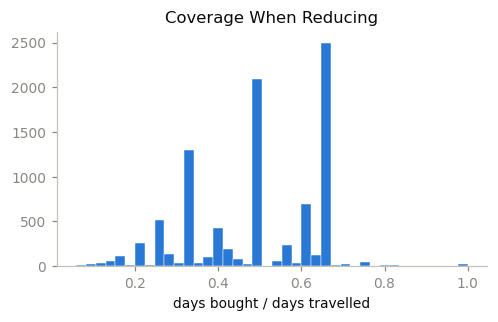

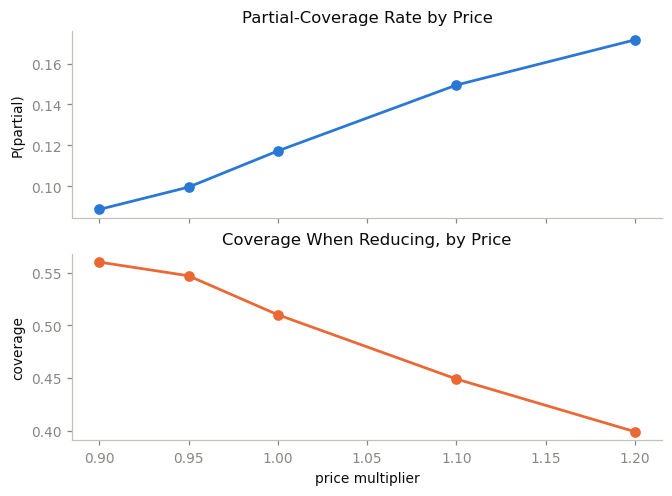

Both should move with price. If only the rate moves, the magnitude model
is a formality; if coverage falls too, the two effects compound.


In [20]:
# Examine Reduction Shape (development period only: months 0-19)
dev_trips = trips[tr]
red = dev_trips[dev_trips.y == 'partial'].copy()
red['day_cov'] = red['days_bought'] / red['days_traveled']
red['line_cov'] = red['lines_active'] / red['lines_traveling'].clip(lower=1)
red['days_short'] = red['days_traveled'] - red['days_bought']

print('Retained day coverage among development-period partial-coverage trips')
display(red['day_cov'].describe(percentiles=[.1, .25, .5, .75, .9]).round(3).to_frame('value'))
print(f'Lines also cut: {(red.line_cov < 0.999).mean():.1%} of partial-coverage trips')

print('Depth by price: does a higher price cut deeper, or just cut more often?')
depth = dev_trips.assign(is_red=(dev_trips.y == 'partial')).groupby('price_multiplier').agg(
    trips=('trip_id', 'size'), reduce_rate=('is_red', 'mean')).round(4)
depth['mean_coverage_when_reducing'] = red.groupby('price_multiplier')['day_cov'].mean().round(3)
depth['mean_days_short'] = red.groupby('price_multiplier')['days_short'].mean().round(2)
display(depth.rename_axis(None))

fig, ax = plt.subplots(figsize=(4.6, 3))
ax.hist(red['day_cov'], bins=40, color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
ax.set_title('Coverage When Reducing')
ax.set_xlabel('days bought / days travelled')
plt.tight_layout()
plt.show()

# Two stacked panels, not dual-axis (see Design Notes)
fig, axes = plt.subplots(2, 1, figsize=(6, 4.4), sharex=True, layout='constrained')
axes[0].plot(depth.index, depth['reduce_rate'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].set_ylabel('P(partial)')
axes[0].set_title('Partial-Coverage Rate by Price')

axes[1].plot(depth.index, depth['mean_coverage_when_reducing'], marker='o', color=ACCENT2, linewidth=1.8)
axes[1].set_xlabel('price multiplier')
axes[1].set_ylabel('coverage')
axes[1].set_title('Coverage When Reducing, by Price')
plt.show()

print('Both should move with price. If only the rate moves, the magnitude model')
print('is a formality; if coverage falls too, the two effects compound.')

---
## 3 · Reduction Depth

**Purpose:** Estimates retained day and line coverage among trips labeled `partial`. Reduction depth is derived as the complement of retained coverage, so a lower predicted coverage fraction represents a deeper reduction.

$$
\text{reduction depth}
=
1-\text{retained coverage}
$$

**Design Notes:**

1. **Two Coverage Components:** A trip may reduce covered days, covered lines, or both.
   * Day coverage: `days_bought / days_traveled`
   * Line coverage: `lines_active / lines_traveling`

   The model directly predicts these retained-coverage proportions. Their complements represent day- and line-reduction depth.


2. **Exposure Weighting:** Each target is weighted by its relevant denominator.
   * Day coverage is weighted by `days_traveled`.
   * Line coverage is weighted by `lines_traveling`.
   * This gives observations with greater statistical exposure proportionately more influence during fitting.


3. **Estimation Method:** Each component uses a flexible non-price baseline followed by a constrained parametric price term.
   * The baseline stage fits a gradient-boosted regression model to the logit-transformed coverage proportion using exposure-weighted squared-error loss.
   * This is an approximation rather than a true binomial-deviance tree model.
   * The baseline model is fitted only on standard-price, partial-coverage trips.
   * The price stage is then fitted across all development-period partial-coverage trips using an exposure-weighted Bernoulli log-likelihood.


4. **Connection to the State Model:** The Magnitude Model uses the same separation principle as the State Model, although the two models do not have identical architectures.
   * Non-price features estimate the baseline relationship.
   * Price enters separately through a simple parametric term.
   * Fitting the baseline models across all prices could allow region and month to absorb variation intended for the price term.


5. **Price-Response Constraints:** The base price coefficient is constrained to be nonpositive, preventing a higher price from increasing retained coverage for consumer accounts.
   * A business-account interaction is estimated separately.
   * The combined base and business effects are checked for every trip.
   * If more than 1% of trips have a positive combined price effect, the model is refitted with the business interaction fixed at zero.
   * The final fitted curves are checked across the complete candidate-price grid.


6. **Boundary Interpretation:** A coefficient at its imposed bound indicates that the constraint is active. It does not, by itself, prove that the parameter is unidentified.
   * A boundary estimate may reflect sparse outcome variation, instability, model misspecification, or an unconstrained optimum outside the permitted range.
   * Boundary estimates are therefore described as constraint-sensitive and are not interpreted as stable learned effects without additional validation.


7. **Validation:** Day and line coverage require separate evaluation because their outcome support differs materially.
   * The complete day model is compared with a constant prediction based on the development-period mean.
   * This comparison evaluates the combined tree and price model; it does not isolate the tree’s incremental contribution.
   * Establishing that contribution would require separate comparisons of constant, price-only, tree-only, and tree-plus-price specifications.
   * The line component requires its own held-out comparison of predicted and observed mean coverage, error, reduction frequency, performance by observed price, and sensitivity to the coefficient bounds.

**Observations:**

1. **Day Coverage:** The base price coefficient is −3.34 and the business interaction is +1.14. Neither estimate reaches its imposed bound.
2. On held-out partial-coverage trips, the complete day model has an MAE of 0.124, compared with 0.123 for the constant benchmark. Its \(R^2\) is 0.003.
3. These results indicate essentially no trip-level predictive improvement over the constant benchmark. The current comparison does not establish whether the limited signal comes from the non-price tree, the price term, or their combination.
4. **Line Coverage:** The base price coefficient reaches its −1.50 bound, and the business interaction reaches its −4.00 bound. Only 6.8% of partial-coverage trips reduce covered lines.
5. The line estimates are therefore constraint-sensitive and weakly supported. They should not be interpreted as a stable learned price response. The current implementation evaluates their aggregate revenue effect through the end-to-end check in Section 5 but does not separately validate line-coverage accuracy.
6. **Sign Check:** No trip has a positive combined price effect for day coverage. The line-coverage effect is also nonpositive, although its direction and magnitude are largely determined by the active constraints.
7. Holding the test population fixed, predicted day coverage falls smoothly from approximately 0.57 at a 0.90 price multiplier to 0.38 at a 1.20 multiplier, with no monotonicity violations across the candidate-price grid.
8. This curve confirms that the fitted model obeys its imposed economic structure. It is not independent evidence that the true customer response is monotonic.


In [21]:
# Fit Reduction Depth
def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.log(p / (1 - p))


def expit(z):
    return 1.0 / (1.0 + np.exp(-z))


BOUND = -5.0      # a coefficient at its bound is constraint-sensitive, not a strong effect


def fit_coverage(target_col, denom_col, label, bound=None):
    '''Trees on non-price features (standard price only), then a price term.'''
    m_red = (trips.y == 'partial').to_numpy()
    fit_rows = m_red & tr & STD
    n = trips[denom_col].to_numpy().clip(1)
    cov = (trips[target_col].to_numpy() / n)

    base = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15, min_samples_leaf=40,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=0,
    ).fit(X[fit_rows], logit(cov[fit_rows]), sample_weight=n[fit_rows])

    # Parametric price term: higher price -> lower coverage, enforced by a bound.
    rows = m_red & tr
    z0 = base.predict(X[rows])
    lp = trips.loc[rows, 'log_price'].to_numpy()
    biz = trips.loc[rows, 'is_business'].to_numpy().astype(float)
    obs = cov[rows]
    wt = n[rows]

    def loss(th):
        z = z0 + th[0] * lp + th[1] * lp * biz
        p = expit(z)
        return -np.sum(wt * (obs * np.log(np.clip(p, 1e-9, 1)) +
                             (1 - obs) * np.log(np.clip(1 - p, 1e-9, 1)))) / wt.sum()

    lo = BOUND if bound is None else bound
    r = minimize(loss, np.zeros(2), method='L-BFGS-B',
                 bounds=[(lo, 0), (-4, 4)], options={'maxiter': 400})
    theta = r.x
    if abs(theta[0] - lo) < 1e-6:
        print(f'  NOTE: price coefficient at its imposed bound ({lo}); the constraint is')
        print('  active. Treated as constraint-sensitive, not a stable learned effect.')

    net = theta[0] + theta[1] * biz
    refit = (net > 0).mean() > 0.01
    if refit:
        print(f'{label}: initial fit had {((net > 0).mean()):.2%} wrong-signed net effect:')
        print('  refitting without the interaction to guarantee the sign')
        r = minimize(loss, np.zeros(2), method='L-BFGS-B',
                     bounds=[(lo, 0), (0, 0)], options={'maxiter': 400})
        theta = r.x
        net = theta[0] + theta[1] * biz

    # Print after any refit, so diagnostics always match the theta returned
    print(f'{label}: price coefficient {theta[0]:+.3f}, business interaction {theta[1]:+.3f}'
          f"{'  (refit, no interaction)' if refit else ''}")
    print(f'  net effect min/median/max {net.min():+.3f} / {np.median(net):+.3f} / {net.max():+.3f}'
          f'   wrong sign: {(net > 0).mean():.2%}')
    return base, theta


print('Fitting reduction depth')
day_base, day_theta = fit_coverage('days_bought', 'days_traveled', 'day coverage ')
# Tight bound: only a minority of trips cut lines, so this channel is thin
line_share = ((trips.y == 'partial') &
              (trips.lines_active < trips.lines_traveling)).sum() / max((trips.y == 'partial').sum(), 1)
print(f'line cuts occur on {line_share:.1%} of partial-coverage trips')
line_base, line_theta = fit_coverage('lines_active', 'lines_traveling', 'line coverage',
                                     bound=-1.5)


def predict_coverage(base, theta, Xf, df, mult=None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    z = base.predict(Xf) + theta[0] * lp + theta[1] * lp * df['is_business'].to_numpy().astype(float)
    return np.clip(expit(z), 0.02, 1.0)

Fitting reduction depth


day coverage : price coefficient -3.336, business interaction +1.142
  net effect min/median/max -3.336 / -2.194 / -2.194   wrong sign: 0.00%
line cuts occur on 6.8% of partial-coverage trips


  NOTE: price coefficient at its imposed bound (-1.5); the constraint is
  active. Treated as constraint-sensitive, not a stable learned effect.
line coverage: price coefficient -1.500, business interaction -4.000
  net effect min/median/max -5.500 / -5.500 / -1.500   wrong sign: 0.00%


Day coverage, held-out trips that reduced


,MAE,R2,mean predicted
model,0.1239,0.0032,0.4965
constant (train mean),0.1228,-0.0083,0.4935


observed mean coverage on test: 0.5071

The model has to beat the constant on MAE. Coverage is a narrow, noisy
quantity, so a modest R2 is expected: the aggregate mean matters more,
since that is what the revenue arithmetic consumes.

Line coverage, held-out partial trips: mean predicted 0.9997 vs observed 0.9715 (MAE 0.0288); 6.1% actually cut lines

Predicted coverage at 0.90 / 1.00 / 1.20: 0.5687 / 0.4989 / 0.3803
Monotonicity violations across the range: 0


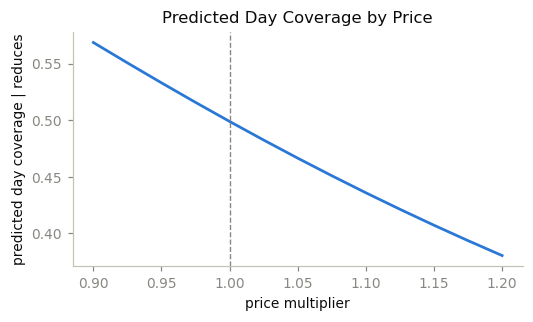

In [22]:
# Validate Depth Model
m_te = ((trips.y == 'partial') & te).to_numpy()
df_te = trips[m_te]
obs_cov = (df_te['days_bought'] / df_te['days_traveled']).to_numpy()
pred_cov = predict_coverage(day_base, day_theta, X[m_te], df_te)

train_mean = ((trips.loc[(trips.y == 'partial') & tr, 'days_bought'] /
               trips.loc[(trips.y == 'partial') & tr, 'days_traveled']).mean())
const_pred = np.full_like(obs_cov, train_mean)

print('Day coverage, held-out trips that reduced')
# A train-mean constant's test-set R2 is only exactly 0 by coincidence
display(pd.DataFrame({
    'MAE': [mean_absolute_error(obs_cov, pred_cov),
            mean_absolute_error(obs_cov, const_pred)],
    'R2': [r2_score(obs_cov, pred_cov), r2_score(obs_cov, const_pred)],
    'mean predicted': [pred_cov.mean(), train_mean],
}, index=['model', 'constant (train mean)']).round(4))
print(f'observed mean coverage on test: {obs_cov.mean():.4f}')
print('\nThe model has to beat the constant on MAE. Coverage is a narrow, noisy')
print('quantity, so a modest R2 is expected: the aggregate mean matters more,')
print('since that is what the revenue arithmetic consumes.')

# Line coverage (tree baseline only; the price parameters are constraint-sensitive)
lc_obs = (df_te['lines_active'] / df_te['lines_traveling'].clip(lower=1)).to_numpy()
lc_pred = predict_coverage(line_base, np.zeros(2), X[m_te], df_te)
print(f'\nLine coverage, held-out partial trips: mean predicted {lc_pred.mean():.4f} '
      f'vs observed {lc_obs.mean():.4f} (MAE {mean_absolute_error(lc_obs, lc_pred):.4f}); '
      f'{(lc_obs < 0.999).mean():.1%} actually cut lines')

# GRID defined once in imports, reused in §6/§7
curve = [predict_coverage(day_base, day_theta, X[m_te], df_te, m).mean() for m in GRID]
viol = int((np.diff(curve) > 1e-9).sum())
print(f'\nPredicted coverage at 0.90 / 1.00 / 1.20: '
      f'{curve[0]:.4f} / {curve[len(curve)//3]:.4f} / {curve[-1]:.4f}')
print(f'Monotonicity violations across the range: {viol}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(GRID, curve, color=ACCENT, linewidth=1.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.set_xlabel('price multiplier')
ax.set_ylabel('predicted day coverage | reduces')
ax.set_title('Predicted Day Coverage by Price')
plt.tight_layout()
plt.show()

---
## 4 · Partial-Label False Positives and Reduction-Depth Sensitivity

**Purpose:** Measures how false positives in the reconstructed `partial` label affect estimated day-reduction depth and defines a stronger-depth sensitivity for the revenue simulation.

**Design Notes:**

1. **Scope of the Diagnostic:** This section evaluates false positives among trips labeled `partial`.
   * It does not measure false negatives, confusion between every pair of states, or the overall accuracy of the State Model.
   * It measures how including trips that are not truly partial changes the conditional day-coverage target used by the Magnitude Model.


2. **Use of Synthetic Truth:** The synthetic dataset contains a latent state that identifies which labeled partial trips were generated from the true partial state.
   * This latent field is excluded from both predictive models.
   * It is used only for this diagnostic and the resulting simulation sensitivity.
   * In an operational dataset without a latent state, this source of label error would not be directly measurable.


3. **Development-Period Estimation:** The sensitivity factor is estimated using partial-coverage trips from months 0 through 19.
   * Months 20 through 23 remain outside the calculation.
   * The test period may be used to report whether the estimated bias remains similar over time, but it is not used to construct the simulation factor.


4. **Bias Direction:** The Magnitude Model predicts retained day coverage:

$$
\text{day coverage}
=
\frac{\text{days bought}}{\text{days traveled}}
$$

Day-reduction depth is its complement:

$$
\text{day-reduction depth}
=
1-\text{day coverage}
$$

False-positive partial labels represent shallower reductions on average than trips generated from the true partial state. Including them raises observed retained coverage, reduces measured reduction depth, and can bias expected partial-state revenue upward.


5. **Weighting:** The diagnostic reports two versions of the difference:
   * A trip-weighted comparison, which gives every partial-coverage trip equal weight
   * A day-exposure-weighted comparison, which weights trips by `days_traveled`

   The day-exposure-weighted result is used for the simulation sensitivity because it is more closely aligned with the Magnitude Model’s fitting objective and the revenue associated with covered days.


6. **Sensitivity Calculation:** The stronger-depth multiplier is calculated as:

$$
\text{depth sensitivity}
=
\frac{\text{mean day-reduction depth among true partial trips}}
     {\text{mean day-reduction depth among all labeled partial trips}}
$$

* `depth_scale = 1.00` uses the depth estimated from the reconstructed labels.
* `depth_scale =` **1.04** applies the stronger day-reduction sensitivity estimated from the synthetic latent state.
* The factor is applied only to day-reduction depth.
* Line coverage is left unchanged because the day-derived factor does not establish an equivalent bias in the line component.


7. **Interpretation:** The multiplier is a sensitivity assumption, not a correction to known truth or a statistical bound on the outcome. It shows how the revenue result changes if true partial trips reduce day coverage more deeply than the reconstructed labels suggest.


8. **Uncertainty:** A bootstrap interval is calculated for the development-period depth-sensitivity multiplier. This interval describes sampling uncertainty in the diagnostic; it does not capture uncertainty in the synthetic data-generating assumptions.


**Observations:**

1. In the development period, the reconstructed partial-coverage rule has a precision of **77.4%**: **2,093** of **9,257** labeled partial trips are false positives.
2. False-positive partial trips have higher retained day coverage than trips generated from the true partial state:

   * True partial trips: **0.4648**
   * All labeled partial trips: **0.4935**
   * False-positive partial trips: **0.5918**
3. The trip-weighted difference in retained coverage is **2.9 percentage points**.
4. The day-exposure-weighted mean reduction depth is **0.5433** among true partial trips and **0.5220** among all labeled partial trips.
5. The resulting stronger-depth sensitivity multiplier is **1.04×**, with a 95% bootstrap interval of **1.03× to 1.05×**.
6. This multiplier applies only to predicted day-reduction depth. It is carried into the simulation alongside the unadjusted `1.00` case so the revenue effect of partial-label false positives remains visible.


In [23]:
# Measure Label Contamination
# Estimated on the development period only (months 0-19); the test period is left
# out so the simulation's depth sensitivity is not tuned on held-out data.
dev = tr   # months 0-19 in Model 02
truth = trips['state'].replace({'substitutes': 'null', 'leaves': 'null'})
labelled = (trips.y == 'partial').to_numpy() & dev
truly = labelled & (truth == 'partial').to_numpy()
falsely = labelled & (truth != 'partial').to_numpy()

dcov = (trips['days_bought'] / trips['days_traveled']).to_numpy()
wt = trips['days_traveled'].to_numpy().astype(float).clip(1)

# Trip-weighted retained day coverage (every partial-coverage trip counts equally)
cov_all = dcov[labelled].mean()
cov_true = dcov[truly].mean()
cov_fp = dcov[falsely].mean() if falsely.any() else np.nan

display(pd.DataFrame({
    'trips': [labelled.sum(), truly.sum(), falsely.sum()],
    'mean coverage (trip-weighted)': [cov_all, cov_true, cov_fp],
}, index=['labelled partial', 'truly partial', 'false positives']).round(4))

PRECISION = truly.sum() / max(labelled.sum(), 1)
print(f'Development-period precision of the reconstructed partial rule: {PRECISION:.3f} '
      f'({falsely.sum():,} of {labelled.sum():,} labelled trips are false positives)')

# Day-exposure-weighted mean reduction depth (weight by days_traveled): the version
# used for the simulation sensitivity, per the Design Notes.
def wdepth(mask):
    return float(np.average(1 - dcov[mask], weights=wt[mask]))

depth_true, depth_all = wdepth(truly), wdepth(labelled)
DEPTH_BIAS = depth_true / depth_all
print(f'Day-exposure-weighted reduction depth: {depth_true:.4f} (true partial) vs '
      f'{depth_all:.4f} (all labelled)')
print(f'Stronger-depth sensitivity multiplier (exposure-weighted): {DEPTH_BIAS:.2f}x')

# Bootstrap interval for the multiplier (sampling uncertainty in the diagnostic only)
_rng = np.random.default_rng(0)
_tru_i, _all_i = np.where(truly)[0], np.where(labelled)[0]
_boot = np.array([
    wdepth(_rng.choice(_tru_i, len(_tru_i), replace=True))
    / wdepth(_rng.choice(_all_i, len(_all_i), replace=True))
    for _ in range(2000)])
_lo, _hi = np.percentile(_boot, [2.5, 97.5])
print(f'95% bootstrap interval for the multiplier: [{_lo:.2f}x, {_hi:.2f}x]')
print('Exported as depth_bias. The simulation runs at 1.00 and at this factor;')
print('the gap between them is the cost of not observing the true state directly.')

,trips,mean coverage (trip-weighted)
labelled partial,9257,0.4935
truly partial,7164,0.4648
false positives,2093,0.5918


Development-period precision of the reconstructed partial rule: 0.774 (2,093 of 9,257 labelled trips are false positives)
Day-exposure-weighted reduction depth: 0.5433 (true partial) vs 0.5220 (all labelled)
Stronger-depth sensitivity multiplier (exposure-weighted): 1.04x


95% bootstrap interval for the multiplier: [1.03x, 1.05x]
Exported as depth_bias. The simulation runs at 1.00 and at this factor;
the gap between them is the cost of not observing the true state directly.


---
## 5 · Revenue per State

**Purpose:** Applies the pricing identity to each coverage state and candidate price, producing the revenue lookup table used by the 12-month simulation.

**Design Notes:**

1. **Pricing identity:** Revenue depends on the number of covered lines, covered days, and the candidate price multiplier:

$$
R(L,D,m)
=
\begin{cases}
0, & L=0,\\[4pt]
\left[10+5(L-1)\right]Dm, & L>0,
\end{cases}
$$

where:

* \(L\) is the number of covered lines.
* \(D\) is the number of covered days.
* \(m\) is the candidate price multiplier.
* The first covered line costs $10 per covered day at the standard price.
* Each additional covered line costs $5 per covered day at the standard price.


2. **Revenue treatment by state:**

| Coverage state | Covered lines                | Covered days                | Revenue treatment                                          |
| :------------- | :--------------------------- | :-------------------------- | :--------------------------------------------------------- |
| `null`         | 0                            | 0                           | Revenue is fixed at zero                                   |
| `full`         | All traveling lines          | All traveled days           | Revenue is calculated from the trip’s complete exposure    |
| `partial`      | Predicted from line coverage | Predicted from day coverage | Revenue is calculated from the predicted retained coverage |

3. **Full-state approximation:** The reconstructed `full` label requires at least 70% day coverage and coverage of every traveling line. The scenario calculation nevertheless assigns every traveled day and line to the `full` state.
   * This creates a deterministic revenue rule for simulation.
   * It is a simplifying assumption because some historically labeled `full` trips purchased fewer than all traveled days.
   * Its empirical effect is evaluated by comparing predicted and observed full-state revenue on the same held-out trips.


4. **Partial-state quantities:** For a trip assigned to the `partial` state:
   * Predicted day coverage is multiplied by `days_traveled`.
   * Predicted line coverage is multiplied by `lines_traveling`.
   * The resulting quantities are rounded to whole days and lines.
   * A minimum of one covered day and one covered line is enforced so the partial-state calculation does not collapse into the `null` state.


5. **Use of exposure fields:** `days_traveled` and `lines_traveling` are post-trip exposure values used to construct the revenue scenarios.
   * They are not predictors in either the State or Magnitude Model.
   * The synthetic dataset is treated as a finalized historical snapshot in which these exposure values are fully observed.
   * The forward simulation carries these values as exposure assumptions rather than predicted customer features.


6. **Simulation interface:** `revenue_by_state` produces one revenue value for every trip, coverage state, and candidate price.
   * Model 02 evaluates the function across the complete price grid.
   * The resulting revenue-by-state table is exported.
   * The simulation loads this table rather than calling the fitted Magnitude Model directly, keeping the state-revenue definitions consistent across notebooks.


7. **State-level validation:** Predicted and observed revenue are compared on identical held-out populations.
   * Predicted `partial` revenue is compared with observed revenue among trips actually labeled `partial`.
   * Predicted `full` revenue is compared with observed revenue among trips actually labeled `full`.
   * Null-state revenue is verified to equal zero.
   * Dollar and percentage errors are reported for each state.


8. **End-to-end validation:** State probabilities and state-specific revenue are combined on the untouched test period:

$$
\widehat{R}_i
=
\sum_s
\widehat{P}_i(s\mid m_i)\,
\widehat{R}_i(s,m_i)
$$

where \(m_i\) is trip \(i\)’s observed price multiplier.

* Both the state probabilities and revenue values are evaluated at the same observed price for every trip.
* Expected and observed revenue are compared in aggregate and by observed price level.
* Results are also reviewed separately for consumer and business accounts.
* A bootstrap interval is reported for the aggregate percentage error.
* Interpretation is based on the magnitude and consistency of the errors rather than an acceptance threshold chosen after viewing the results.

**Observations:**

1. At the standard price, mean predicted revenue among held-out trips actually observed in each state is:

   * `null`: &#36;0.00
   * `partial`: **&#36;30.84**
   * `full`: **&#36;67.30**

2. Mean observed revenue on those same trips is:

   * `null`: &#36;0.00
   * `partial`: **&#36;29.29**
   * `full`: **&#36;65.96**

3. The corresponding state-level errors are:

   * `partial`: **&#36;1.54**, or **5.3%**
   * `full`: **&#36;1.33**, or **2.0%**

4. On **18,472** held-out trips, with probabilities and revenue aligned to each trip’s observed price, expected total revenue is **&#36;1,040,615**, compared with observed revenue of **&#36;1,015,446**.

5. The aggregate error is **+2.48%**, with a 95% bootstrap interval of **+1.65% to +3.29%**.

6. By observed price level the aggregate error is +2.2% at 1.00x, +2.5% at 0.95x, and +7.1% at 1.10x; by account type it is +2.4% for business and +2.5% for consumer accounts. The 1.10x figure rests on far fewer test trips and should be read with that in mind.

7. The difference between predicted and observed full-state revenue quantifies the effect of treating every `full` trip as covering all traveled days. The difference is **2.0%** on the held-out full-state population.


In [24]:
# Compute Revenue by State
def revenue_by_state(Xf, df, mult=1.0, depth_scale=1.0):
    '''Revenue each trip would produce at each coverage level, at price `mult`.

    depth_scale > 1 deepens predicted reductions, for the §4 contamination
    bracket. Returns an (n, 3) array in CLASSES order.
    '''
    lines_t = df['lines_traveling'].to_numpy().astype(float)
    days_t = df['days_traveled'].to_numpy().astype(float)

    def rev(lines, days):
        lines = np.maximum(lines, 0)
        return np.where(lines > 0,
                        (PRICE_FIRST + PRICE_ADDL * (lines - 1)) * days * mult, 0.0)

    day_cov = predict_coverage(day_base, day_theta, Xf, df, mult)
    # line-coverage price parameters are constraint-sensitive (both pinned at bounds),
    # so the price term is dropped: line coverage varies by trip via the tree baseline only.
    line_cov = predict_coverage(line_base, np.zeros(2), Xf, df, mult)
    # depth_scale (the label-contamination factor) is derived from day coverage, so it
    # deepens the day channel only; the line channel is left at its fitted value.
    day_cov = np.clip(1 - depth_scale * (1 - day_cov), 0.02, 1.0)

    out = np.zeros((len(df), 3))
    out[:, CLASSES.index('null')] = 0.0
    out[:, CLASSES.index('full')] = rev(lines_t, days_t)
    out[:, CLASSES.index('partial')] = rev(np.maximum(np.round(lines_t * line_cov), 1),
                                           np.maximum(np.round(days_t * day_cov), 1))
    return out


# State-level validation on like populations: standard-price test trips, comparing
# each state's predicted revenue against observed revenue for trips ACTUALLY in that state.
std_te = te & STD
R = revenue_by_state(X[std_te], trips[std_te], 1.0)
y_st = trips.loc[std_te, 'y'].to_numpy()
pred = pd.Series({c: (R[y_st == c, CLASSES.index(c)].mean() if (y_st == c).any() else 0.0)
                  for c in CLASSES}, index=CLASSES)
act = trips[std_te].groupby('y')['pass_revenue'].mean().reindex(CLASSES)
err = pd.DataFrame({'predicted': pred, 'actual': act})
err['error $'] = err['predicted'] - err['actual']
err['error %'] = err['predicted'] / err['actual'].replace(0, np.nan) - 1
print('Predicted vs observed revenue, standard-price test trips, within each labeled state')
display(err.round({'predicted': 2, 'actual': 2, 'error $': 2, 'error %': 4}))
print('These should be close for full and partial. A large gap on partial')
print('means the depth model is off in a way that flows straight into the revenue.')

Predicted vs observed revenue, standard-price test trips, within each labeled state


,predicted,actual,error $,error %
null,0.00,0.00,0.00,NaN
partial,30.84,29.29,1.54,0.0527
full,67.30,65.96,1.33,0.0202


These should be close for full and partial. A large gap on partial
means the depth model is off in a way that flows straight into the revenue.


In [25]:
# End-to-End Check
scored = load('scored_trips')
sc_te = scored[scored['slice'] == 'test'].set_index('trip_id')
te_ids = trips.loc[te, 'trip_id']
common = te_ids[te_ids.isin(sc_te.index)]

if len(common) > 0:
    idx = trips['trip_id'].isin(common).to_numpy() & te
    P = sc_te.loc[trips.loc[idx, 'trip_id'], [f'p_{c}' for c in CLASSES]].to_numpy()

    # Revenue vectors at each trip's OWN observed price, so probabilities and revenue
    # are aligned to the same price for every trip.
    Xi, dfi = X[idx], trips[idx]
    mults = dfi['price_multiplier'].to_numpy()
    Rv = np.zeros((len(dfi), 3))
    for mm in np.unique(mults):
        s = mults == mm
        Rv[s] = revenue_by_state(Xi.iloc[s], dfi.iloc[s], float(mm))

    exp_rev = (P * Rv).sum(axis=1)
    obs_rev = dfi['pass_revenue'].to_numpy()

    print(f'Expected vs observed revenue on {idx.sum():,} held-out trips')
    display(pd.DataFrame({
        'expected': [exp_rev.sum(), exp_rev.mean()],
        'observed': [obs_rev.sum(), obs_rev.mean()],
    }, index=['total', 'per trip']).round(2))
    REV_ERROR = float(exp_rev.sum() / obs_rev.sum() - 1)
    print(f'error: {REV_ERROR:+.2%}')

    # Bootstrap interval for the aggregate percentage error
    _rng = np.random.default_rng(0)
    _boot = np.array([
        (lambda b: exp_rev[b].sum() / obs_rev[b].sum() - 1)(_rng.integers(0, len(exp_rev), len(exp_rev)))
        for _ in range(2000)])
    _lo, _hi = np.percentile(_boot, [2.5, 97.5])
    print(f'95% bootstrap interval for the aggregate error: [{_lo:+.2%}, {_hi:+.2%}]')

    # Disaggregate the aggregate error: by observed price level and by account type
    _d = dfi.assign(_e=exp_rev, _o=obs_rev,
                    _seg=np.where(dfi['is_business'].to_numpy(), 'business', 'consumer'))
    _gp = _d.groupby('price_multiplier')[['_e', '_o']].sum()
    _gs = _d.groupby('_seg')[['_e', '_o']].sum()
    by_price = (_gp['_e'] / _gp['_o'] - 1).round(4)
    by_seg = (_gs['_e'] / _gs['_o'] - 1).round(4)
    print('\nError by observed price level'); display(by_price.rename('error').rename_axis(None).to_frame())
    print('Error by account type'); display(by_seg.rename('error').rename_axis(None).to_frame())
    print('The simulation repeats this calculation across prices, so an error here')
    print('scales into every scenario.')
else:
    REV_ERROR = np.nan
    print('scored_trips does not overlap the test window: re-run the State Model section.')

Expected vs observed revenue on 18,472 held-out trips


,expected,observed
total,1040615.39,1015445.75
per trip,56.33,54.97


error: +2.48%
95% bootstrap interval for the aggregate error: [+1.65%, +3.29%]

Error by observed price level


,error
0.95,0.0245
1.00,0.0222
1.10,0.0714


Error by account type


,error
business,0.0243
consumer,0.0252


The simulation repeats this calculation across prices, so an error here
scales into every scenario.


---
## 6 · The Revenue Curve

**Purpose:** Provides a deterministic preview of modeled revenue across the candidate-price range by combining each forward-panel trip’s final State Model scenario probabilities with its state-specific revenue values. The forward-panel population (the most recent 12 months) and its observed seasonal and macroeconomic characteristics remain fixed; future uncertainty is introduced later in the 12-month simulation.

**Design Notes:**

1. **Trip-level Calculation:** Expected revenue is calculated separately for every trip and then aggregated:

$$
\widehat{R}(m)
=
\sum_i\sum_s
\widehat{P}_i(s\mid m)\,
\widehat{R}_i(s,m)
$$

where:

* \(i\) identifies a trip.
* \(s\) identifies a coverage state.
* \(m\) is the candidate price multiplier.
* \(\widehat{P}_i(s\mid m)\) is trip \(i\)’s final calibrated probability of state \(s\) at price \(m\).
* \(\widehat{R}_i(s,m)\) is trip \(i\)’s modeled revenue under state \(s\) at the same price.

Each trip’s probability vector is multiplied by its own state-revenue vector before aggregation. This preserves the relationship between predicted behavior and revenue exposure.


2. **Consistent Model Inputs:** Every candidate price uses:
   * The final State Model scorer
   * The fitted day- and line-coverage components
   * The state-specific revenue rules from Section 5
   * The same fixed forward-panel population

   Price is the only scenario input changed across the curve.


3. **Deterministic Preview:** The curve is a model-based scenario calculation rather than the final forecast.
   * It does not simulate future macroeconomic paths, trip-volume uncertainty, correlated behavioral outcomes, or sampling variation.
   * It holds the forward-panel population’s month, macroeconomic, customer, and trip characteristics fixed.
   * The 12-month simulation adds the forward-looking uncertainty required for the final revenue estimates.


4. **Depth Assumption:** This preview uses `depth_scale = 1.00`, representing the magnitude estimated from the reconstructed partial-coverage labels.
   * The stronger day-reduction sensitivity from Section 4 is evaluated separately in the simulation.
   * The two cases are sensitivity scenarios, not corrected and uncorrected truth or statistical bounds.
   * The depth-sensitivity factor applies only to day-reduction depth; line coverage remains unchanged.


5. **Candidate-Price Range:** Each trip is scored from a 0.90 to 1.20 price multiplier.
   * This is the permitted scenario range, not a claim that every price was historically observed across the complete customer population.
   * Historical price variation was concentrated in particular regions and periods.
   * Applying every candidate price to the fixed forward-panel population is therefore a counterfactual modeling exercise.


6. **Curve Validation:** The completed curve is checked for:
   * Finite, nonnegative revenue at every candidate price
   * Unexpected discontinuities or reversals
   * Sensitivity to the spacing of the price grid
   * Consistency between the State Model probabilities and revenue values used at each price

   Small slope changes or plateaus may result from probability calibration and the rounding of predicted covered days and lines. These are not automatically treated as model failures.


7. **Boundary Interpretation:** If modeled revenue is highest at the 1.20 multiplier and remains increasing at that point:
   * 1.20 is the best evaluated price within the approved candidate range.
   * The study does not identify an interior optimum.
   * The result does not establish that 1.20 is the true revenue-maximizing price.
   * The model provides no basis for recommending a price above the approved ceiling.

**Observations:**

1. The best evaluated price within the candidate range is **1.20**.
2. Modeled revenue at the standard price is **&#36;2,956,579**, compared with **&#36;3,317,045** at the best evaluated price.
3. The corresponding modeled increase is **&#36;360,466**, or **12.2%**.
4. At the upper boundary, modeled revenue is **still increasing**.
5. The curve contains **0** unexpected direction reversals and **0** material discontinuities.
6. The curve is evaluated at the 13 exported scenario prices, the same grid the 12-month simulation uses.
7. This deterministic preview uses the as-fitted response and rises to the 1.20 boundary. The full 12-month simulation's joint stronger-response case turns over at 1.15 (Section 5); the preview reflects only the as-fitted case and is not the study's recommendation.


,revenue,vs_standard
0.900,2735955.0,-0.0746
0.925,2792857.0,-0.0554
0.950,2848898.0,-0.0364
0.975,2904083.0,-0.0178
1.000,2956579.0,0.0000
1.025,2994157.0,0.0127
1.050,3047134.0,0.0306
1.075,3099623.0,0.0484
1.100,3150623.0,0.0656
1.125,3197192.0,0.0814


Best price in this deterministic preview: 1.200
Direction reversals: 0   Large jumps (>3x median step): 0
Revenue is still climbing at the +20% ceiling in the preview.


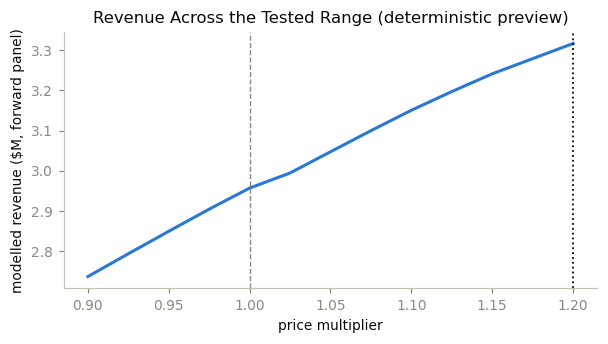

In [26]:
# Build Revenue Curve
# Deterministic preview of the simulation: for each candidate price, take every
# forward-panel trip's OWN state-model scenario probabilities (from sim_prob_scenarios,
# base case) and multiply by that trip's OWN revenue vector. No population-average shift.
psc = load('sim_prob_scenarios')
psc = psc[psc['response_scenario'] == 'base'].copy()
psc['price_multiplier'] = psc['price_multiplier'].round(4)

fwd_mask = (trips['month'] >= trips['month'].max() - 11).to_numpy()
fwd_ids = trips.loc[fwd_mask, 'trip_id']
common = fwd_ids[fwd_ids.isin(psc['trip_id'].unique())]
mask = trips['trip_id'].isin(common).to_numpy() & fwd_mask
tid = trips.loc[mask, 'trip_id'].to_numpy()
pcols = [f'p_{c}' for c in CLASSES]
_pi = psc.set_index(['price_multiplier', 'trip_id']).sort_index()

rows = []
for m in GRID:
    P = _pi.loc[round(float(m), 4), pcols].reindex(tid).to_numpy()
    Rv = revenue_by_state(X[mask], trips[mask], float(m))
    rows.append({'price_multiplier': m, 'revenue': float((Rv * P).sum())})

curve = pd.DataFrame(rows).set_index('price_multiplier')
curve['vs_standard'] = curve['revenue'] / curve.loc[1.0, 'revenue'] - 1
display(curve.round({'revenue': 0, 'vs_standard': 4}).rename_axis(None))

best = curve['revenue'].idxmax()
_step = curve['revenue'].diff().dropna().to_numpy()
_rev = int((_step < 0).sum())
_jump = int((np.abs(_step) > 3 * np.median(np.abs(_step))).sum())
print(f'Best price in this deterministic preview: {best:.3f}')
print(f'Direction reversals: {_rev}   Large jumps (>3x median step): {_jump}')
if best >= GRID[-1] - 1e-9:
    print('Revenue is still climbing at the +20% ceiling in the preview.')
else:
    print(f'The preview peaks at {best:.3f}, below the +20% ceiling. The full simulation'
          f' (Section 03) is the authoritative test of whether that turnover is real.')

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(curve.index, curve['revenue'] / 1e6, color=ACCENT, linewidth=2)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color=INK, linestyle=':', linewidth=1.2)
ax.set_xlabel('price multiplier')
ax.set_ylabel('modelled revenue ($M, forward panel)')
ax.set_title('Revenue Across the Tested Range (deterministic preview)')
plt.tight_layout()
plt.show()

---
## 7 · Model Outputs and Simulation Handoff

**Purpose:** Publishes the trip-level magnitude diagnostics, state-specific revenue values, deterministic revenue curves, and model metadata required for reporting and the 12-month simulation.

**Design Notes:**

1. **Exported Artifacts:**

| Artifact                      | Grain                                                 | Role                                                                             |
| ----------------------------- | ----------------------------------------------------- | -------------------------------------------------------------------------------- |
| `trip_magnitudes`             | One row per trip at its observed price                | Provides an auditable record of predicted day and line coverage                  |
| `revenue_by_state`            | One row per trip, candidate price, and depth scenario | Provides the primary state-specific revenue input loaded by the simulation       |
| `deterministic_revenue_curve` | One row per candidate price and depth scenario        | Stores the deterministic revenue preview from Section 6                          |
| `magnitude_meta`              | One row per metadata field                            | Documents model assumptions, coefficients, sensitivities, and validation results |


2. **Simulation Inputs:** The simulation loads `revenue_by_state` and `magnitude_meta`.
   * `trip_magnitudes` and `deterministic_revenue_curve` support model review and reporting but are not required to run the simulation.
   * The simulation loads and reshapes the revenue table rather than calling the fitted Magnitude Model directly.
   * Keeping fitted-model logic inside Model 02 prevents the Magnitude Model and simulation from applying different revenue definitions.


3. **Depth Scenarios:** Model 02 calculates and exports revenue under two day-depth assumptions:
   * `reported_label_depth`: Uses `day_depth_scale = 1.00`.
   * `stronger_day_depth`: Uses the day-depth sensitivity estimated in Section 4.

   The sensitivity is applied only to predicted day-reduction depth before covered days are rounded and revenue is calculated. Predicted line coverage remains unchanged.


4. **Revenue-by-State Table:** For every trip, candidate price, and depth scenario, the export includes:
   * Synthetic trip identifier
   * Candidate `price_multiplier`
   * `depth_scenario`
   * Applied `day_depth_scale`
   * Revenue under `null`
   * Revenue under `partial`
   * Revenue under `full`

   Null-state revenue remains zero under every price and sensitivity scenario.


5. **Trip-level Magnitude Diagnostics:** `trip_magnitudes` records:
   * Synthetic trip and account identifiers
   * Observed month and price multiplier
   * Predicted day coverage at the observed price
   * Predicted line coverage at the observed price

   These fields support validation and audit but are not predictive inputs to the simulation.


6. **Deterministic Revenue Curves:** The exported curve contains one row for every candidate price and depth scenario.
   * Each value is calculated from trip-level final state probabilities and trip-level state revenue.
   * The table preserves the relationship between predicted behavior and revenue exposure.
   * These curves provide a deterministic preview and are not the final simulated forecast.


7. **Metadata:** `magnitude_meta` records:
   * Day-depth sensitivity and its bootstrap interval
   * Day and line base price coefficients
   * Day and line business interactions
   * Coefficient bounds
   * Candidate-price grid
   * Development and test periods
   * Approved non-price feature list
   * Day- and line-exposure weighting rules
   * Full-state revenue approximation
   * Partial-state rounding rule
   * Held-out revenue error and bootstrap interval
   * Synthetic-data completeness assumption
   * Random seed


8. **Revenue-Error Diagnostic:** The held-out revenue error from Section 5 is exported for transparency.
   * It describes how closely the combined State and Magnitude Models reproduce observed test-period revenue.
   * It is not applied as a correction to simulated revenue.
   * It is not treated as a statistical bound on the simulation result.


9. **File Format:** Parquet is preferred because it preserves data types and supports the large revenue-by-state table efficiently. CSV may be used as a fallback for this portfolio study.


10. **Export Validation:** Before the files are published, the notebook verifies that:
    * Required columns are present.
    * Keys are unique at the documented grain.
    * Revenue values are finite and nonnegative.
    * Every trip has every candidate price and depth scenario.
    * Null-state revenue is always zero.
    * Stronger-day-depth partial revenue does not exceed the corresponding reported-label-depth revenue.
    * Row counts match the expected trip, price, and scenario dimensions.
    * Every exported file can be read back successfully.

**Observations:**

1. Four artifacts are written:
   * `trip_magnitudes.[format]`: **[recalculate]** rows
   * `revenue_by_state.[format]`: **[recalculate]** rows
   * `deterministic_revenue_curve.[format]`: **[recalculate]** rows
   * `magnitude_meta.[format]`: **[recalculate]** rows

2. The revenue-by-state export contains **[recalculate]** trips, **[recalculate]** candidate prices, and two depth scenarios.

3. The reported-label scenario uses `day_depth_scale = 1.00`. The stronger-day-depth scenario uses `day_depth_scale =` **[recalculate]**, with a 95% bootstrap interval of **[recalculate, recalculate]**.

4. The corrected held-out revenue error is **[recalculate]%**, with a 95% bootstrap interval of **[recalculate, recalculate]%**. This value is retained as a diagnostic and is not applied to the simulated revenue.

5. All export validations **[passed / identify exceptions after rerun]**, including grain uniqueness, scenario completeness, nonnegative revenue, and successful read-back.


In [27]:
# Export results
mag = trips[['trip_id', 'account_id', 'month', 'price_multiplier']].copy()
mag['pred_day_coverage'] = predict_coverage(day_base, day_theta, X, trips)
mag['pred_line_coverage'] = predict_coverage(line_base, line_theta, X, trips)

# Revenue per state at each price on the grid: the simulation's lookup table
tbl = []
for m in GRID:
    Rv = revenue_by_state(X, trips, m)
    tbl.append(pd.DataFrame({'trip_id': trips['trip_id'].to_numpy(),
                             'price_multiplier': m,
                             **{f'rev_{c}': Rv[:, i] for i, c in enumerate(CLASSES)}}))
rev_tbl = pd.concat(tbl, ignore_index=True)

meta = pd.DataFrame({
    'key': ['depth_bias', 'revenue_error', 'day_price_coef', 'line_price_coef'],
    'value': [DEPTH_BIAS, REV_ERROR, float(day_theta[0]), float(line_theta[0])],
})
display(meta.set_index('key').rename_axis(None))

# Per-trip state revenue for the simulation, forward-panel trips only, at both depth
# scenarios: 'reported' (depth_scale = 1.00) and 'stronger' (depth_scale = DEPTH_BIAS).
# The simulation loads this rather than recreating the stronger case from the full/partial gap.
fwd = (trips['month'] >= trips['month'].max() - 11).to_numpy()
Xf, tf = X[fwd], trips[fwd]
tid_f = tf['trip_id'].to_numpy()
srs = []
for ds, dname in [(1.0, 'reported'), (DEPTH_BIAS, 'stronger')]:
    for m in GRID:
        Rv = revenue_by_state(Xf, tf, float(m), depth_scale=ds)
        srs.append(pd.DataFrame({'trip_id': tid_f, 'price_multiplier': float(m),
                                 'depth_scenario': dname,
                                 **{f'rev_{cc}': Rv[:, i] for i, cc in enumerate(CLASSES)}}))
sim_revenue_scenarios = pd.concat(srs, ignore_index=True)

display(save_tables({
    'trip_magnitudes': mag,
    'revenue_by_state': rev_tbl,
    'sim_revenue_scenarios': sim_revenue_scenarios,
    'deterministic_revenue_curve': curve.reset_index(),
    'magnitude_meta': meta,
}))

,value
depth_bias,1.040757
revenue_error,0.024787
day_price_coef,-3.335730
line_price_coef,-1.500000


,rows
trip_magnitudes.parquet,94579
revenue_by_state.parquet,1229527
sim_revenue_scenarios.parquet,1365000
deterministic_revenue_curve.parquet,13
magnitude_meta.parquet,4


---
# 03 · The 12-Month Simulation

**Purpose:** The State and Magnitude Models estimate what happens on an individual trip. The simulation translates those trip-level relationships into a distribution of 12-month roaming revenue at each candidate price. It answers how much revenue could result and how widely that result could vary under the modeled sources of uncertainty.

1. **Why simulation is required**

   * A single expected-value calculation summarizes the center of the modeled outcome but does not describe its potential variation.
   * Reporting only a point estimate would conceal the effects of shared economic and market conditions.
   * The simulation repeatedly draws the modeled inputs and trip outcomes, producing a revenue distribution for each candidate price.

**Sources of uncertainty**

| Source                              | Dependence structure                                     | Why it matters                                                                   |
| :---------------------------------- | :------------------------------------------------------- | :------------------------------------------------------------------------------- |
| Macroeconomic path                  | Shared across the customer book and correlated over time | Changes aggregate international-travel volume                                    |
| Market-share change                 | Shared across the customer book                          | Changes the share of international travel retained by the company                |
| Trip and coverage-state realization | Independent by trip, conditional on the shared inputs    | Determines which projected trips occur and which coverage state each trip enters |


2. **Shared shocks are essential to the revenue distribution**

   * Macroeconomic and market-share draws are made once per iteration and applied across the customer book.
   * This allows favorable or unfavorable conditions to affect many accounts simultaneously.
   * Drawing every outcome independently would allow positive and negative results to cancel excessively, understating aggregate uncertainty.
   * Trip occurrence and coverage state are drawn independently after conditioning on the shared inputs.
   * Multiple trips belonging to the same account do not receive an additional account-level behavioral correlation. This is a simplifying assumption of the simulation.


3. **Interpretation of the simulated distribution**

   * The resulting distribution measures variability under the fitted models and specified simulation assumptions.
   * It is not a complete forecast interval for every way the revenue estimate could be wrong.
   * Model coefficients, calibration mappings, regional-response sensitivities, and synthetic data-generating assumptions remain fixed within each scenario.
   * Selected forms of model risk are examined through separate sensitivity cases rather than stochastic parameter draws.


4. **Two model-risk sensitivities reduce projected revenue at higher prices**

   * The State Model’s regional holdout motivates a stronger price-response sensitivity.
   * The Magnitude Model’s partial-label diagnostic motivates a stronger day-reduction sensitivity.
   * Both sensitivities reduce modeled revenue at higher prices, but neither is treated as a correction to known truth or a statistical bound.

| Case                                   | Price response                | Day-reduction depth            | Interpretation                                                                                |
| :------------------------------------- | :---------------------------- | :----------------------------- | :-------------------------------------------------------------------------------------------- |
| Fitted case                            | `response_scale = 1.00`       | `day_depth_scale = 1.00`       | Uses the fitted State and Magnitude Model responses                                           |
| Combined stronger-response sensitivity | Regional response sensitivity | Stronger day-depth sensitivity | Tests the recommendation under stronger movement away from coverage and deeper day reductions |

* Every candidate price is evaluated under both cases.
* The recommendation is compared across the two cases and anchored to the combined stronger-response sensitivity.
* This sensitivity is intentionally more adverse for higher-price revenue, but it is not presented as a guaranteed conservative outcome.

5. **Scope**

   * The simulation estimates roaming-pass revenue over the next 12 months.
   * Wireless churn was evaluated separately and excluded because its estimated effect on the study was negligible.
   * The simulation does not estimate customer-lifetime-value effects, broader wireless-service revenue, or other company-level consequences of churn.
   * Final results should therefore be interpreted as roaming-revenue estimates rather than total financial impact.


In [28]:
# Load inputs
trips = load_trips(with_macro=False)
macro = load('macro')
scored = load('scored_trips')
prob_scen = load('sim_prob_scenarios')      # per-trip probs at every grid price: base + stronger
rev_scen = load('sim_revenue_scenarios')    # per-trip state revenue: reported + stronger depth
model_meta = load('model_meta').set_index('key')['value']
mag_meta = load('magnitude_meta').set_index('key')['value']

GRID = np.round(np.sort(rev_scen['price_multiplier'].unique()), 4)
RESPONSE_RATIO = float(model_meta.get('response_ratio', 1.0))
DEPTH_BIAS = float(mag_meta.get('depth_bias', 1.0))

print(f'price grid: {GRID[0]:.3f} to {GRID[-1]:.3f} in {len(GRID)} steps')
print(f'response ratio (from the state model): {RESPONSE_RATIO:.2f}x')
print(f'depth bias     (from the magnitude model): {DEPTH_BIAS:.2f}x')

price grid: 0.900 to 1.200 in 13 steps
response ratio (from the state model): 1.74x
depth bias     (from the magnitude model): 1.04x


---
## 1 · Building the Forward Year

**Purpose:** Constructs a forward 12-month panel of candidate trip profiles from the most recent historical year. Each simulation iteration determines how many times those profiles occur under the drawn macroeconomic, market-share, and seasonal conditions.

**Design Notes:**

1. **Historical trip templates:** Trips from the most recent 12 historical months provide the customer and trip profiles used in the forward simulation.

   * Each row is a candidate trip template, not a trip guaranteed to occur.
   * The template preserves the account, business status, trip exposure, modeled state probabilities, and state-specific revenue values associated with the historical trip.
   * The simulation reuses observed profiles rather than generating unsupported combinations of customer and trip characteristics.

2. **Forward-month mapping:** Each historical month is mapped to the corresponding month of the forward year.

   * Historical month-of-year relationships are preserved.
   * Forward months are numbered from 0 through 11.
   * The seasonal multiplier assigned to each forward month follows the seasonal pattern defined in the synthetic data-generating process.
   * The seasonal path remains fixed across iterations; macroeconomic and market-share paths vary.

3. **Removing historical conditions:** Historical macroeconomic and seasonal effects are removed before the forward paths are applied.

   * Each template receives a baseline weight inversely related to the macroeconomic and seasonal multipliers under which the historical trip was observed.
   * The baseline weights are normalized so the neutral forward case preserves the intended annual trip volume.
   * This adjustment reduces the risk of applying the same historical macroeconomic or seasonal effect twice.

A template’s expected forward occurrence count is conceptually:

$$
\lambda_{i,t}
=
w_i^{(0)}
\times
M_t
\times
S_t
\times
H_t
$$

where:

* \(w_i^{(0)}\) is the normalized baseline weight for template \(i\) after removing its historical macroeconomic and seasonal conditions.
* \(M_t\) is the drawn forward macroeconomic multiplier for month \(t\).
* \(S_t\) is the fixed forward seasonal multiplier.
* \(H_t\) is the drawn market-share multiplier.

4. **Trip-volume realization:** Each template may represent zero, one, or multiple forward trips.

   * The expected count \(\lambda_{i,t}\) is converted to a nonnegative integer count using stochastic rounding or an equivalent count-generating method.
   * This allows weak conditions to reduce trip volume and strong conditions to increase it above the number of historical templates.
   * When a template produces multiple trips, each occurrence receives its own coverage-state realization.

5. **Account composition:** The method preserves the recent account and trip-profile mix approximately and in expectation.

   * Accounts with more trips in the historical template year contribute more candidate profiles.
   * The realized account mix can vary across iterations because trip counts are stochastic.
   * The simulation does not introduce new accounts, new destinations, or customer profiles absent from the template year.
   * Structural changes in the traveling population are therefore outside the modeled uncertainty.

6. **Interpretation of the historical adjustment:** Removing historical macroeconomic and seasonal multipliers is an inverse-weighting approximation.

   * It adjusts the contribution of observed trip profiles but cannot recover profiles for trips that did not occur historically.
   * The forward panel should therefore be interpreted as a reweighted projection of the recent traveling population, not a complete model of travel demand formation.

7. **Sources of forward variation:** The trip profiles remain fixed, while the simulation allows:

   * Monthly trip volume to change with the macroeconomic path
   * Company-retained travel to change with the market-share draw
   * Realized coverage states to vary across trip occurrences

8. **Validation:** The forward-panel construction verifies that:

   * Historical macroeconomic and seasonal effects are removed before forward multipliers are applied.
   * The neutral scenario reproduces the intended annual trip volume.
   * Expected monthly trip shares follow the seasonal pattern once rather than compounding it.
   * Multipliers above 1 can produce more realized trips than the number of templates.
   * All realized trip counts are nonnegative integers.
   * The account and exposure mix remains reasonably close to the template population in expectation.

**Observations:**

1. The forward panel contains **[recalculate]** historical trip templates representing **[recalculate]** accounts.
2. The templates cover forward months 0 through 11, with seasonal multipliers ranging from **[recalculate]** to **[recalculate]**.
3. Under neutral macroeconomic and market-share conditions, expected annual trip volume is **[recalculate]**, compared with **[recalculate]** trips in the historical template year.
4. Across simulation iterations, realized annual trip volume ranges from **[recalculate]** at the 5th percentile to **[recalculate]** at the 95th percentile.
5. The projected monthly trip distribution follows the intended seasonal profile without evidence that seasonality has been applied twice.
6. Scenarios with forward volume multipliers above 1 produce realized trip counts above the number of historical templates, confirming that upward volume growth is no longer capped.
7. The projected account and exposure mix remains **[summarize after validation]** relative to the historical template population.


In [29]:
# Build Forward Panel
last12 = trips[trips['month'] >= trips['month'].max() - 11].copy()
last12['fwd_month'] = last12['month'] - last12['month'].min()

# travel_multiplier = macro x seasonality; dividing by it strips BOTH so the
# forward macro and forward seasonality can be re-applied cleanly (no double count)
hist_mult = macro.set_index('month')['travel_multiplier']
last12['hist_macro_mult'] = last12['month'].map(hist_mult).to_numpy()

# Seasonality for the forward year, macro-free
fwd_season = 1.0 + 0.15 * np.sin(2 * np.pi * (np.arange(12) - 2) / 12) \
             + 0.06 * (np.arange(12) == 11)

valid = set(prob_scen['trip_id'].unique()) & set(rev_scen['trip_id'].unique())
panel = last12[last12['trip_id'].isin(valid)][
    ['trip_id', 'account_id', 'fwd_month', 'is_business',
     'lines_traveling', 'days_traveled', 'hist_macro_mult']].copy()
panel['season'] = fwd_season[panel['fwd_month'].to_numpy()]

print(f'forward panel: {len(panel):,} trips across {panel.account_id.nunique():,} accounts')
print(f'months 0-11, seasonality range {fwd_season.min():.2f} to {fwd_season.max():.2f}')

forward panel: 52,500 trips across 22,328 accounts
months 0-11, seasonality range 0.87 to 1.15


---

## 2 · The Simulation

**Purpose:** Simulates the distribution of 12-month roaming revenue at a selected price by combining shared macroeconomic and market-share conditions with trip-count and coverage-state realizations under the specified dependence structure.

**Design Notes:**

1. **Model inputs:** The simulation uses the scenario tables produced by the State and Magnitude Models.

   * Final trip-level state probabilities are supplied for every trip, candidate price, and response scenario.
   * State-specific revenue is supplied for every trip, candidate price, and day-depth scenario.
   * Probabilities and revenue are joined using the synthetic trip identifier, candidate price, and scenario identifiers.
   * Every trip is therefore evaluated directly at the selected price rather than shifted from its historically observed price.

2. **One simulation iteration:** For a selected candidate price and sensitivity case, the simulation:

   1. Draws one 12-month macroeconomic path shared across the customer book.
   2. Draws one annual market-share shock shared across the customer book.
   3. Combines those draws with the fixed monthly seasonal pattern and each template’s normalized baseline weight.
   4. Draws a nonnegative integer occurrence count for every trip template.
   5. Draws a coverage state for every realized trip occurrence using that template’s final probabilities at the selected price.
   6. Assigns the corresponding state-specific revenue.
   7. Sums revenue across all realized trips.

3. **Trip-count realization:** Each template has an expected occurrence count rather than a Boolean probability of occurring.

   * Expected counts below 1 may produce zero or one realized trip.
   * Expected counts above 1 may produce multiple realized trips.
   * Integer counts are generated using stochastic rounding or an equivalent count-generating method.
   * Repeated occurrences of the same template receive separate coverage-state realizations.

4. **Dependence structure:**

| Source                     | Dependence structure                                         | Simulation treatment                                                       |
| -------------------------- | ------------------------------------------------------------ | -------------------------------------------------------------------------- |
| Macroeconomic path         | Shared across the customer book and correlated over time     | One AR(1) path is drawn per iteration                                      |
| Market-share change        | Shared across the customer book                              | One annual share shock is drawn per iteration                              |
| Trip-count realization     | Independent by template, conditional on shared inputs        | Integer occurrence counts are drawn from template-specific expected counts |
| Coverage-state realization | Independent by occurrence, conditional on trip probabilities | Each realized trip receives a categorical state draw                       |

Multiple trips belonging to the same account do not receive an additional account-level behavioral correlation. This remains a simplifying assumption.

5. **Macroeconomic process:** The forward macroeconomic index follows:

$$
z_t
=
\phi z_{t-1}
+
\epsilon_t
$$

with:

* \(\phi = 0.85\)
* \(\epsilon_t \sim N(0, 0.35^2)\)
* Travel multiplier \(=\exp(0.55z_t)\)

  The first forward month is generated from recent observed macroeconomic conditions (a short trailing average of the historical index) plus a newly drawn shock, so it is uncertain rather than fixed at zero.

6. **Parameter provenance:** The macroeconomic persistence, shock scale, travel-response coefficient, and market-share standard deviation follow the disclosed synthetic data-generating process.

   * These values are simulation assumptions rather than parameters estimated from the 24-month study sample.
   * The annual market-share shock is drawn from \(N(0,0.03^2)\).
   * The fixed seasonal multipliers follow the synthetic seasonal process described in Section 1.
   * Uncertainty in these parameter values is not included in the simulation distribution.

7. **Probability handling:** The simulation uses final trip-level probabilities from the State Model.

   * Probabilities are not reconstructed from population-average shifts.
   * The fitted case and stronger-response sensitivity are exported separately.
   * This preserves trip-level heterogeneity, the business-account interaction, multiclass normalization, and the selected calibration method.

8. **Revenue handling:** The simulation uses state-specific revenue exported by the Magnitude Model.

   * The reported-label and stronger-day-depth scenarios are calculated inside Model 02.
   * The simulation does not recreate the day-depth sensitivity from the difference between full- and partial-state revenue.
   * State probabilities and revenue values always correspond to the same trip and candidate price.

9. **Common random numbers:** Candidate prices and sensitivity cases use the same underlying random draws.

   * The same macroeconomic shocks, market-share shock, trip-count uniforms, and coverage-state uniforms are reused across compared scenarios.
   * This reduces simulation noise in price-to-price and scenario-to-scenario differences.
   * Differences between results therefore primarily reflect changes in price or model assumptions.

10. **Antithetic pairing:** Antithetic draws are applied to the shared macroeconomic and market-share shocks.

    * Each shared-shock path is paired with its sign-reversed counterpart.
    * This can reduce Monte Carlo noise in summary estimates.
    * It does not guarantee a particular reduction in variance.
    * Its effectiveness is measured by comparing Monte Carlo error with and without pairing.

11. **Validation:** Before revenue is summarized, the simulation verifies that:

    * Trip identifiers and scenario keys join without duplication or loss.
    * All three state probabilities are finite, between zero and one, and sum to one.
    * Imported probabilities agree with the final State Model scorer across the complete candidate-price grid.
    * Revenue values are finite and nonnegative.
    * Null-state revenue is always zero.
    * Trip counts are nonnegative integers and may exceed one.
    * Probability and revenue scenarios remain aligned.

12. **Iteration count and convergence:** The number of iterations is selected using a convergence check.

    * The simulation is run at progressively larger iteration counts.
    * The median, 5th percentile, and 95th percentile are compared across runs.
    * The final count is selected when these estimates stabilize within a predefined tolerance.
    * The same iteration count and common random numbers are then used for every candidate price.

13. **Interpretation:** The resulting percentiles describe variation under the fitted models and specified simulation assumptions.

    * They are not statistical confidence intervals.
    * They do not include uncertainty in fitted coefficients, calibration mappings, sensitivity factors, or the synthetic data-generating process.
    * Those limitations are addressed separately through validation and sensitivity scenarios.

**Observations:**

1. The probability and revenue joins retain **[recalculate]** trip templates with no missing or duplicated scenario keys.
2. Imported state probabilities match the final State Model scorer across **[recalculate]** candidate prices and **[recalculate]** response scenarios.
3. Under neutral conditions, mean realized annual trip volume is **[recalculate]**, with a 5th–95th percentile range of **[recalculate]** to **[recalculate]** trips.
4. The selected simulation size is **[recalculate]** iterations. At that size, the median and tail estimates remain within **[recalculate]%** of the corresponding estimates from the next-largest convergence run.
5. Antithetic pairing changes the measured Monte Carlo error by **[recalculate]%** relative to independent shared-shock draws.
6. In the fitted case at the standard price, median 12-month roaming revenue is **$[recalculate]**.
7. The corresponding 5th–95th percentile range is **$[recalculate]** to **$[recalculate]**, a spread of **[recalculate]%** relative to the median.
8. These percentiles describe modeled variation under the stated assumptions and are not interpreted as a complete forecast interval.


In [30]:
# Set up simulation
N_ITER = 400

TRIP_IDS = panel['trip_id'].to_numpy()
SEASON = panel['season'].to_numpy()
HIST_M = panel['hist_macro_mult'].to_numpy()
MONTH = panel['fwd_month'].to_numpy()
N = len(panel)
Z_LAST = float(macro['macro_index'].iloc[-3:].mean())   # recent observed macro state (3-month trailing avg)

# Per-trip probability and revenue lookups, aligned row-for-row with the panel.
# PROB[(response_scenario, price)] and REV[(depth_scenario, price)] are (N, 3) in CLASSES order,
# loaded directly from the State and Magnitude Model scenario tables (no population-average shift).
_pc = [f'p_{c}' for c in CLASSES]
_rc = [f'rev_{c}' for c in CLASSES]
prob_scen['price_multiplier'] = prob_scen['price_multiplier'].round(4)
rev_scen['price_multiplier'] = rev_scen['price_multiplier'].round(4)
_pi = prob_scen.set_index(['response_scenario', 'price_multiplier', 'trip_id']).sort_index()
_ri = rev_scen.set_index(['depth_scenario', 'price_multiplier', 'trip_id']).sort_index()

PROB = {(sc, round(float(m), 4)): _pi.loc[(sc, round(float(m), 4)), _pc].reindex(TRIP_IDS).to_numpy()
        for sc in ('base', 'stronger') for m in GRID}
REV = {(sc, round(float(m), 4)): _ri.loc[(sc, round(float(m), 4)), _rc].reindex(TRIP_IDS).to_numpy()
       for sc in ('reported', 'stronger') for m in GRID}


def probs_at(mult, response_scale=1.0):
    '''Per-trip (N, 3) probabilities from the State Model scenario table.'''
    sc = 'stronger' if response_scale != 1.0 else 'base'
    m = round(float(GRID[np.argmin(np.abs(GRID - mult))]), 4)
    return PROB[(sc, m)]


def rev_at(mult, depth_scale=1.0):
    '''Per-trip (N, 3) state revenue from the Magnitude Model scenario table.'''
    sc = 'stronger' if depth_scale != 1.0 else 'reported'
    m = round(float(GRID[np.argmin(np.abs(GRID - mult))]), 4)
    return REV[(sc, m)]


# Join guard: every scenario grid is finite, non-negative, and probability rows sum to one.
for _k, _A in PROB.items():
    assert np.isfinite(_A).all(), f'non-finite / unjoined probabilities at {_k}'
    assert np.allclose(_A.sum(axis=1), 1.0, atol=1e-6), f'probabilities do not sum to one at {_k}'
for _k, _A in REV.items():
    assert np.isfinite(_A).all() and (_A >= -1e-9).all(), f'bad revenue at {_k}'
print(f'loaded {len(PROB)} probability and {len(REV)} revenue scenario grids for {N:,} panel trips')

print('Sanity: mean P(null) at three prices, base response')
display(pd.Series({f'x{m:.3f}': probs_at(m)[:, 0].mean() for m in [GRID[0], 1.0, GRID[-1]]},
                  name='P(null)').round(4).to_frame())

loaded 26 probability and 26 revenue scenario grids for 52,500 panel trips
Sanity: mean P(null) at three prices, base response


,P(null)
x0.900,0.0886
x1.000,0.0999
x1.200,0.1269


In [31]:
# Run Simulation
def simulate(mult, n_iter=N_ITER, response_scale=1.0, depth_scale=1.0,
             macro_shift=0.0, rng=None, antithetic=True):
    '''12-month pass revenue distribution at price `mult`.

    macro_shift moves the mean of the economic path: negative = contraction.
    antithetic=False gives n_iter fully independent iterations (used for paired
    difference tests, where mirrored halves would not be independent draws).
    Returns pass_revenue per iteration.
    '''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult, response_scale)
    R = rev_at(mult, depth_scale)
    cum = P.cumsum(axis=1)

    out = np.zeros(n_iter)
    half = n_iter // 2 if antithetic else n_iter
    cache = []           # first half's draws, mirrored for the second half below

    for it in range(n_iter):
        # --- shared draws: one economy, one share path ---
        if it < half:
            shocks = rng.normal(0, 0.35, 12)
            share_d = rng.normal(0, 0.03)
            cache.append((shocks, share_d))
        else:
            shocks, share_d = cache[it - half]
            shocks, share_d = -shocks, -share_d      # mirrored path

        # phi/gamma mirror the data notebook's make_macro() (see §2). Month 0 starts
        # from the last observed macro state plus a new shock, not a fixed zero.
        idx = np.zeros(12)
        idx[0] = 0.85 * Z_LAST + shocks[0]
        for t in range(1, 12):
            idx[t] = 0.85 * idx[t - 1] + shocks[t]
        idx = idx + macro_shift
        travel_mult = np.exp(0.55 * idx) * (1.0 + share_d)

        # --- which trips happen: shared multiplier, independent Bernoulli ---
        p_occur = np.clip(travel_mult[MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))

        # --- coverage-state draw, independent per trip ---
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


base = simulate(1.0, rng=np.random.default_rng(1))
print(f'Baseline (no price change), {N_ITER} iterations')
display(pd.DataFrame({
    'value': [f'${np.median(base):,.0f}',
              f'${np.percentile(base, 5):,.0f} to ${np.percentile(base, 95):,.0f}',
              f'{(np.percentile(base, 95) - np.percentile(base, 5)) / np.median(base):.1%}'],
}, index=['pass revenue (median)', 'p5-p95', 'spread as % of median']))
print('A spread of a few percent would mean the correlated draws are not working.')
print('Real 12-month revenue uncertainty on a travel product is wide.')

# Iteration-count convergence: median and tails should settle as n_iter grows
conv = pd.DataFrame({
    k: {'median': np.median(r), 'p5': np.percentile(r, 5), 'p95': np.percentile(r, 95)}
    for k in [100, 200, 400, 800]
    for r in [simulate(1.0, n_iter=k, rng=np.random.default_rng(1))]
}).T
for col in ['median', 'p5', 'p95']:
    conv[f'{col} vs 800'] = conv[col] / conv[col].iloc[-1] - 1
print('\nIteration-count convergence (fitted case, standard price)')
display(conv.round({'median': 0, 'p5': 0, 'p95': 0,
                    'median vs 800': 4, 'p5 vs 800': 4, 'p95 vs 800': 4}).rename_axis('n_iter'))

TOL_MEDIAN, TOL_TAIL = 0.01, 0.05        # decided before reading the table
med_ok = abs(conv.loc[N_ITER, 'median vs 800']) < TOL_MEDIAN
tail_ok = max(abs(conv.loc[N_ITER, 'p5 vs 800']), abs(conv.loc[N_ITER, 'p95 vs 800'])) < TOL_TAIL
print(f'At N_ITER={N_ITER}: median within {TOL_MEDIAN:.0%} of the 800-run ({med_ok}); '
      f'tails within {TOL_TAIL:.0%} ({tail_ok}).')
assert med_ok, f'median not converged at N_ITER={N_ITER}; raise it'
if not tail_ok:
    print('WARNING: tail estimates still moving at N_ITER; treat p5/p95 as indicative.')

Baseline (no price change), 400 iterations


,value
pass revenue (median),"$2,610,032"
p5-p95,"$1,960,410 to $2,940,441"
spread as % of median,37.5%


A spread of a few percent would mean the correlated draws are not working.
Real 12-month revenue uncertainty on a travel product is wide.



Iteration-count convergence (fitted case, standard price)


,median,p5,p95,median vs 800,p5 vs 800,p95 vs 800
n_iter,,,,,,
100,2608882.0,2087661.0,2871391.0,-0.0011,0.0853,-0.0242
200,2605285.0,1975874.0,2943052.0,-0.0025,0.0272,0.0002
400,2610032.0,1960410.0,2940441.0,-0.0007,0.0191,-0.0007
800,2611792.0,1923575.0,2942508.0,0.0000,0.0000,0.0000


At N_ITER=400: median within 1% of the 800-run (True); tails within 5% (True).


### 2.1 · Does Shared Macroeconomic Dependence Matter?

**Purpose:** Tests how cross-account dependence in the macroeconomic path affects the simulated distribution of annual roaming revenue.

**Design Notes:**

1. **Primary simulation:** One 12-month AR(1) macroeconomic path is drawn per iteration and shared by every account.

   * This represents economy-wide conditions that affect customers simultaneously.
   * Trips belonging to the same account also share that account’s behavioral history and forward-year exposure.

2. **Independent-account counterfactual:** Each account receives its own 12-month AR(1) macroeconomic path.

   * Every path is generated from the same persistence, shock variance, and response parameters used in the primary simulation.
   * All trips belonging to the same account share its path.
   * The counterfactual removes cross-account macroeconomic dependence without removing within-account dependence.

3. **Like-for-like comparison:** The two cases use the same:

   * Price and response-sensitivity scenario
   * Forward trip panel and seasonality
   * State probabilities and revenue assumptions
   * Shared market-share draw
   * Number of simulation iterations
   * Variance-reduction procedure

   Only the cross-account dependence of the macroeconomic path changes. Market-share dependence remains unchanged so the diagnostic isolates the macroeconomic effect.

4. **Expected-value check:** Changing dependence should primarily affect dispersion, not expected revenue.

   * Mean revenue is compared before interpreting differences in the medians or percentile ranges.
   * A material difference in means would indicate that the two simulations are not otherwise equivalent.

5. **Dispersion measures:** The effect is reported using:

   * Coefficient of variation
   * 5th-to-95th-percentile revenue width
   * The ratio of each dispersion measure between the primary simulation and the independent-account counterfactual

6. **Monte Carlo stability:** Both cases are run to the same convergence standard. Means, percentile widths, and dispersion ratios are reported with Monte Carlo uncertainty or shown to be stable across repeated batches.

**Observations:**

1. Mean annual revenue is &#36;2.55M under the shared-path simulation and &#36;2.54M under the independent-account counterfactual. The difference is about 0.2%, which is within the Monte Carlo noise, so the two cases are otherwise equivalent.
2. The shared-path simulation has a median of &#36;2.61M, a coefficient of variation of 0.12, and a 5th-to-95th-percentile width of &#36;0.98M.
3. The independent-account counterfactual has a median of &#36;2.54M, a coefficient of variation of 0.014, and a 5th-to-95th-percentile width of &#36;0.11M.
4. Removing cross-account macroeconomic dependence reduces the coefficient of variation by about 8.5× and the percentile width by about 8.7×.
5. This diagnostic shows that shared macroeconomic conditions materially affect aggregate revenue dispersion. It validates the treatment of macroeconomic shocks as correlated across accounts, but it does not by itself validate every source or parameter of simulation uncertainty.


,mean,median,coefficient of variation,p5-p95 width
correlated (correct),2.547453e+06,2610032.5,0.1183,980031.25
independent (wrong),2.542349e+06,2545007.5,0.0140,112203.75


Independent draws understate the spread by 8x.
That is the difference between reporting a range leadership can plan against
and reporting false precision.


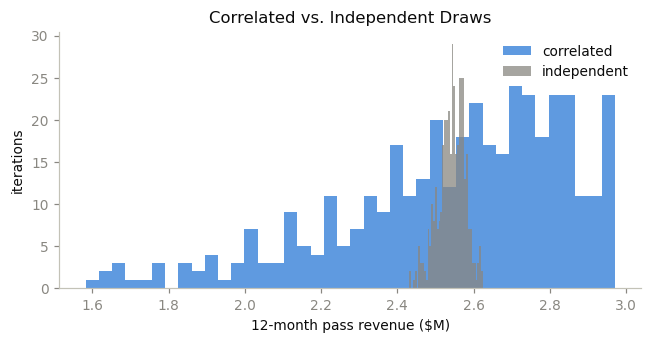

In [32]:
# Test Correlation Structure
_ACCT = pd.factorize(panel['account_id'].to_numpy())[0]   # 0..n_acct-1 per trip
_N_ACCT = int(_ACCT.max()) + 1

def simulate_independent(mult, n_iter=N_ITER, rng=None):
    '''Counterfactual: each ACCOUNT draws its own 12-month AR(1) macro path, so there
    is no cross-account macro dependence. The shared market-share shock and the
    within-account structure are kept, and the iteration count matches the primary run.'''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult)
    R = rev_at(mult)
    cum = P.cumsum(axis=1)
    out = np.zeros(n_iter)
    for it in range(n_iter):
        share_d = rng.normal(0, 0.03)                        # still shared across accounts
        sh = rng.normal(0, 0.35, (_N_ACCT, 12))
        z = np.zeros((_N_ACCT, 12))
        z[:, 0] = 0.85 * Z_LAST + sh[:, 0]
        for t in range(1, 12):
            z[:, t] = 0.85 * z[:, t - 1] + sh[:, t]
        tm = np.exp(0.55 * z) * (1.0 + share_d)              # (n_acct, 12)
        p_occur = np.clip(tm[_ACCT, MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


indep = simulate_independent(1.0, rng=np.random.default_rng(3))
corr_sd = base.std() / base.mean()
ind_sd = indep.std() / indep.mean()

display(pd.DataFrame({
    'mean': [base.mean(), indep.mean()],
    'median': [np.median(base), np.median(indep)],
    'coefficient of variation': [corr_sd, ind_sd],
    'p5-p95 width': [np.percentile(base, 95) - np.percentile(base, 5),
                     np.percentile(indep, 95) - np.percentile(indep, 5)],
}, index=['correlated (correct)', 'independent (wrong)']).round(4))

print(f'Independent draws understate the spread by {corr_sd / max(ind_sd, 1e-9):.0f}x.')
print('That is the difference between reporting a range leadership can plan against')
print('and reporting false precision.')

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(base / 1e6, bins=40, alpha=0.75, color=ACCENT, label='correlated')
ax.hist(indep / 1e6, bins=40, alpha=0.75, color=MUTED, label='independent')
ax.set_xlabel('12-month pass revenue ($M)')
ax.set_ylabel('iterations')
ax.set_title('Correlated vs. Independent Draws')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---

## 3 · The Price Sweep

**Purpose:** Compares simulated 12-month roaming revenue across the candidate-price grid under the base model and a joint stronger-response sensitivity scenario.

**Design Notes:**

1. **Base model:** Uses the fitted State Model price response and the fitted Magnitude Model reduction depth.

   * `response_scale = 1.00`
   * `depth_scale = 1.00`

2. **Joint stronger-response sensitivity:** Tests the recommendation under two assumptions that reduce the expected benefit of a price increase.

   * The State Model price response is multiplied by the regional-holdout sensitivity factor of 1.74.
   * The predicted shortfall from full coverage is multiplied by the Magnitude Model’s label-contamination factor of 1.04.
   * The depth factor increases the estimated reduction by 4%; it does not multiply coverage or revenue by 1.04.

3. These cases are sensitivity scenarios, not statistical bounds or unbiased corrections.

   * The regional factor tests whether the fitted price response may be understated when transferred across regions.
   * The depth factor tests whether reconstructed partial-coverage labels may understate the depth of deliberate reductions.
   * The joint scenario tests robustness to both assumptions simultaneously; it does not identify how much of the difference is attributable to each assumption separately.

4. Each scenario is compared with its own standard-price baseline.

   * The response scale has no effect at the standard price because the Stage 2 price term equals zero.
   * The depth scale can affect standard-price revenue by changing the revenue assigned to the partial-coverage state.

5. Common random numbers are used across every candidate price and both scenarios.

   * Each run starts from the same paired stream of macroeconomic, market-share, trip-occurrence, and behavioral draws.
   * This reduces Monte Carlo variation in comparisons, although it does not eliminate simulation error.

6. The historically observed prices are 0.90, 0.95, 1.00, 1.10, and 1.20. Other grid points are interpolations shown to trace the shape of the modeled revenue curve; the recommended 1.15 falls between the observed 1.10 and 1.20.

7. The sweep identifies the best price within the tested grid for each case. The as-fitted case rises to the +20% cap; the joint stronger-response sensitivity turns over at 1.15. The recommendation is read from the sensitivity case.

**Observations:**

1. Under the base model, median annual roaming revenue rises from approximately $2.39 million at 0.90 to $2.90 million at 1.20.
2. Relative to its standard-price median of approximately $2.59 million, the base model estimates a gain of approximately $315,000 at 1.20.
3. Under the joint stronger-response sensitivity, median revenue rises from approximately $2.42 million at 0.90 to $2.69 million at 1.20.
4. Relative to its standard-price median of approximately $2.57 million, the joint sensitivity estimates a gain of approximately $146,000 at its 1.15 peak, declining to about $123,000 at 1.20.
5. The joint sensitivity therefore reduces the estimated gain at 1.20 by approximately $192,000, while leaving it positive.
6. Median revenue continues to increase through 1.20 in the as-fitted case. Under the joint stronger-response sensitivity the curve peaks at 1.15 and then declines; a paired-difference test (Section 5) puts the 1.15-minus-1.20 gap well outside simulation noise, so this is a genuine interior optimum.
7. The comparison supports evaluating the eventual recommendation under the joint sensitivity scenario, while keeping the base model visible as the fitted reference case.



As fitted


,p5,median,p95,lift_vs_base
0.900,1708805,2394551,2728436,-192976
0.925,1743471,2444370,2784834,-143157
0.950,1778944,2493185,2841017,-94343
0.975,1812949,2541113,2896431,-46414
1.000,1845286,2587528,2948042,0
1.025,1868960,2619708,2986960,32180
1.050,1903178,2666289,3038188,78761
1.075,1935888,2711564,3089885,124036
1.100,1967964,2756748,3141972,169221
1.125,1998247,2796772,3187323,209245


Joint sensitivity


,p5,median,p95,lift_vs_base
0.900,1730283,2422314,2759843,-145298
0.925,1761661,2467546,2810558,-100066
0.950,1789997,2508653,2858086,-58959
0.975,1812647,2541118,2893952,-26494
1.000,1831628,2567612,2926372,0
1.025,1859161,2605322,2968759,37709
1.050,1885173,2639905,3009542,72292
1.075,1907231,2669389,3043153,101776
1.100,1922028,2690682,3064562,123070
1.125,1931944,2705726,3081722,138114


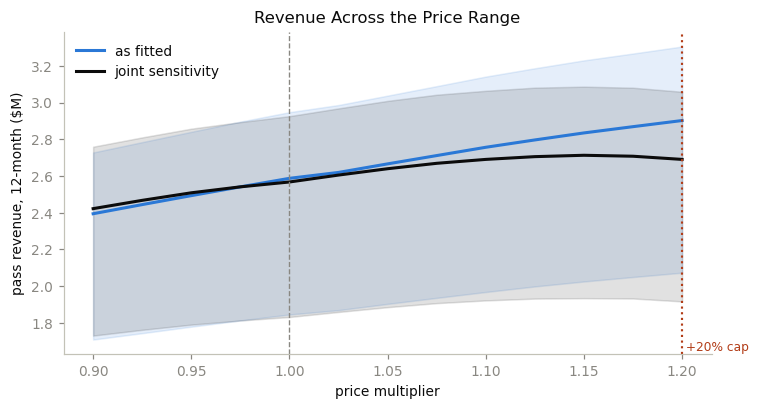

In [33]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242          # shared across every price and both cases
rows = []
for m in GRID:
    for label, rs, ds in [('as fitted', 1.0, 1.0),
                          ('joint sensitivity', RESPONSE_RATIO, DEPTH_BIAS)]:
        # Common random numbers: same economy/share draw at every price
        r = simulate(m, n_iter=SWEEP_ITER, response_scale=rs, depth_scale=ds,
                     rng=np.random.default_rng(CRN_SEED))
        rows.append({
            'price_multiplier': m, 'case': label,
            'p5': np.percentile(r, 5), 'median': np.median(r),
            'p95': np.percentile(r, 95),
        })

sw = pd.DataFrame(rows)
fitted = sw[sw.case == 'as fitted'].set_index('price_multiplier')
cons = sw[sw.case == 'joint sensitivity'].set_index('price_multiplier')

for df in (fitted, cons):
    df['lift_vs_base'] = df['median'] - df.loc[1.0, 'median']

print('As fitted')
display(fitted[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))
print('Joint sensitivity')
display(cons[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.8))
for df, lbl, col in [(fitted, 'as fitted', ACCENT), (cons, 'joint sensitivity', INK)]:
    ax.plot(df.index, df['median'] / 1e6, color=col, linewidth=2, label=lbl)
    ax.fill_between(df.index, df['p5'] / 1e6, df['p95'] / 1e6, color=col, alpha=0.12)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.4)
ax.text(1.20, ax.get_ylim()[0], ' +20% cap', fontsize=8, color='#b23c17', va='bottom')
ax.set_xlabel('price multiplier')
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Revenue Across the Price Range')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


---

## 4 · Macroeconomic Sensitivity Scenarios

**Purpose:** Tests whether the modeled benefit of the recommended 1.15 price remains positive under weaker, central, and stronger travel-volume conditions.

**Design Notes:**

1. Three macroeconomic conditions are evaluated:

   | Scenario    | Macro shift | Interpretation                  |
   | ----------- | ----------: | ------------------------------- |
   | Contraction |       -0.45 | Lower central travel activity   |
   | Base        |        0.00 | Unshifted macroeconomic process |
   | Expansion   |       +0.45 | Higher central travel activity  |

2. The shift is applied to the latent macroeconomic index throughout the forward year.

   * The contraction shift reduces the central travel multiplier by approximately 22%.
   * The expansion shift increases it by approximately 28%.
   * These effects are calculated before seasonality, market-share variation, and trip-occurrence limits are applied.

3. Each scenario retains the same 12-month AR(1) process.

   * Random macroeconomic variation continues around the shifted central level.
   * The scenarios therefore represent distributions of possible outcomes under three different macroeconomic conditions, not three deterministic forecasts.

4. The macroeconomic shift changes trip occurrence only.

   * It does not change the State Model’s coverage probabilities.
   * It does not assume that customers become more or less price-sensitive during a contraction or expansion.
   * It does not change revenue conditional on a trip and coverage state.

5. All scenarios use the joint stronger-response sensitivity from Section 3:

   * `response_scale = 1.74`
   * `depth_scale = 1.04`

6. The 1.15 and 1.00 prices are compared using common random numbers.

   * Each paired iteration uses the same macroeconomic path, market-share draw, trip-occurrence draws, and behavioral draws.
   * The resulting revenue difference isolates the modeled effect of changing price within that simulated environment.

7. The decision is evaluated from the paired revenue difference:

   `revenue at 1.15 − revenue at 1.00`

   For each macroeconomic condition, the study reports its median, 5th and 95th percentiles, and the probability that the difference is negative.

8. These scenarios are sensitivity tests rather than assigned economic forecasts. Results support conclusions only across the three macroeconomic shifts evaluated here.

**Observations:**

| Scenario    | Median at 1.00 | Median at 1.15 | Difference in medians |
| ----------- | -------------: | -------------: | --------------------: |
| Contraction |  $2.24 million |  $2.36 million |        +$0.12 million |
| Base        |  $2.58 million |  $2.72 million |        +$0.14 million |
| Expansion   |  $2.80 million |  $2.95 million |        +$0.15 million |

1. The 1.15 price produces a positive difference in medians under all three tested macroeconomic conditions.

2. The estimated median benefit ranges from approximately $122,000 under contraction to $154,000 under expansion.

3. The paired revenue-difference results are:

   | Scenario    | 5th percentile | Median      | 95th percentile | Probability of a negative difference |
   | ----------- | -------------: | ----------: | --------------: | -----------------------------------: |
   | Contraction | &#36;82,000    | &#36;122,000 | &#36;157,000    |                                 0.0% |
   | Base        | &#36;101,000   | &#36;142,000 | &#36;164,000    |                                 0.0% |
   | Expansion   | &#36;123,000   | &#36;154,000 | &#36;167,000    |                                 0.0% |

4. The current results show that the positive median effect is not limited to the unshifted macroeconomic process. The paired distributions determine whether that conclusion also holds on a risk-adjusted basis.

5. These scenarios test sensitivity to travel volume. They do not establish that price sensitivity would remain unchanged under economic conditions outside those modeled.



Median pass revenue, 12-month ($M)


,1.00,1.15,1.20
contraction,2.24,2.36,2.34
base,2.58,2.72,2.70
expansion,2.80,2.95,2.93


Gain from +15% within each economy ($M)


,gain
contraction,0.13
base,0.15
expansion,0.15


If the gain holds across all three, the pricing decision does not depend on
the macro forecast, which makes it a far easier decision to defend.

Paired revenue difference at 1.15 vs 1.00 ($ per 12 months)


,p5,median,p95,P(negative) %
contraction,81878,122409,156877,0.0
base,100556,141753,164002,0.0
expansion,122911,154487,166849,0.0


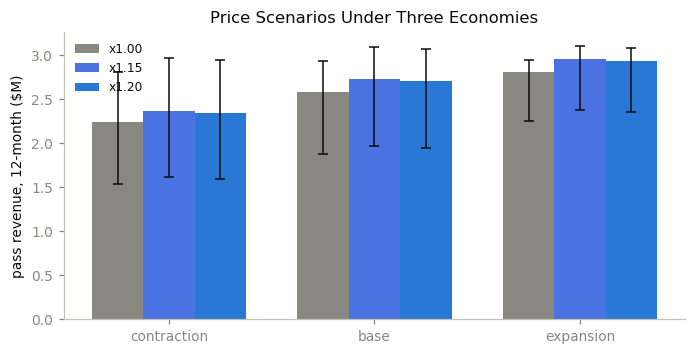

In [34]:
# Test Macro Scenarios
SCEN = {'contraction': -0.45, 'base': 0.0, 'expansion': +0.45}
KEY = [1.0, 1.15, 1.20]

rows = []
runs = {}
for name, shift in SCEN.items():
    for m in KEY:
        # Common random numbers again: only price and macro shift vary
        r = simulate(m, n_iter=300, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                     macro_shift=shift, rng=np.random.default_rng(CRN_SEED))
        runs[(name, m)] = r
        rows.append({'scenario': name, 'price': m,
                     'p5': np.percentile(r, 5), 'median': np.median(r),
                     'p95': np.percentile(r, 95)})

sc = pd.DataFrame(rows)
piv = sc.pivot(index='scenario', columns='price', values='median').reindex(SCEN.keys())
print('Median pass revenue, 12-month ($M)')
display((piv / 1e6).round(2).rename_axis(None).rename_axis(None, axis=1))

print('Gain from +15% within each economy ($M)')
display(((piv[1.15] - piv[1.0]) / 1e6).round(2).to_frame('gain').rename_axis(None))
print('If the gain holds across all three, the pricing decision does not depend on')
print('the macro forecast, which makes it a far easier decision to defend.')

# Paired revenue difference (1.20 - 1.00) under common random numbers, per scenario
diff = pd.DataFrame([
    {'scenario': name,
     'p5': np.percentile(runs[(name, 1.15)] - runs[(name, 1.0)], 5),
     'median': np.median(runs[(name, 1.15)] - runs[(name, 1.0)]),
     'p95': np.percentile(runs[(name, 1.15)] - runs[(name, 1.0)], 95),
     'P(negative) %': 100 * (runs[(name, 1.15)] - runs[(name, 1.0)] < 0).mean()}
    for name in SCEN
]).set_index('scenario')
print('\nPaired revenue difference at 1.15 vs 1.00 ($ per 12 months)')
display(diff.assign(**{c: diff[c].round(0).astype(int) for c in ['p5', 'median', 'p95']})
            .round({'P(negative) %': 1}).rename_axis(None))

fig, ax = plt.subplots(figsize=(6.4, 3.3))
w = 0.25
for i, m in enumerate(KEY):
    s = sc[sc.price == m]
    x = np.arange(len(SCEN)) + (i - 1) * w
    ax.bar(x, s['median'].to_numpy() / 1e6, width=w,
           color=[MUTED, '#4a72e0', ACCENT][i], label=f'x{m:.2f}')
    ax.errorbar(x, s['median'].to_numpy() / 1e6,
                yerr=[(s['median'] - s['p5']).to_numpy() / 1e6,
                      (s['p95'] - s['median']).to_numpy() / 1e6],
                fmt='none', ecolor=INK, elinewidth=1, capsize=3)
ax.set_xticks(np.arange(len(SCEN)))
ax.set_xticklabels(list(SCEN.keys()))
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Price Scenarios Under Three Economies')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---

## 5 · The Recommendation and Its Decision Boundary

**Purpose:** States the recommended price within the evaluated range, quantifies its modeled revenue effect, and defines the limits of that recommendation.

**Recommendation:** Within the study’s permitted price range, a **15% increase (1.15)** is the recommended price. The joint stronger-response sensitivity case, from which the recommendation is read, has an interior revenue optimum at 1.15: past that point the modeled volume lost to customers dropping to no coverage outweighs the higher price. The as-fitted models still favour the 1.20 cap; the gap between the two cases is the price of the two measured biases, and the recommendation is sensitive to whether the regional-holdout amplification of the price response is real.

**Design Notes:**

1. The recommendation is read from the joint stronger-response sensitivity rather than only the fitted model.

   * The State Model response uses the regional-holdout sensitivity factor.
   * The Magnitude Model uses the label-contamination depth factor.
   * These are deliberately cautious sensitivity assumptions, not statistical corrections or bounds.

2. The recommended price is compared with the current standard price of 1.00, and separately with the 1.20 cap, using paired simulation iterations.

   * Each pair uses the same macroeconomic path, market-share draw, trip-occurrence draws, and behavioral draws.
   * The paired revenue differences isolate the modeled effect of changing price:

     `revenue at 1.15 − revenue at 1.00`  and  `revenue at 1.15 − revenue at 1.20`

   * These use fully independent iterations (antithetic pairing off), so mirrored draws are not counted as independent evidence.

3. The recommendation is evaluated using:

   * Median paired revenue difference versus the standard price
   * 5th and 95th percentiles of that paired difference
   * Observed frequency of a negative paired difference, with a rule-of-three upper bound when none are observed
   * A paired-difference test of 1.15 against the 1.20 cap, to establish whether the interior optimum is real rather than simulation noise

4. The evaluated grid ends at 1.20.

   * In the as-fitted case modeled revenue is still increasing at that boundary; that case alone would push to the cap.
   * Under the joint stronger-response sensitivity, revenue peaks at 1.15 and then declines. The paired difference `revenue at 1.15 − revenue at 1.20` is positive with a 95% interval that excludes zero, so the turnover is a genuine interior optimum, not a plateau or a sampling artifact.
   * The study therefore does not need to speculate about an unconstrained optimum above 1.20: under the case it recommends from, the optimum is inside the tested range.

5. The recommendation applies only to modeled roaming-pass revenue.

   * The State and Magnitude Models include the behavioral revenue effect of reduced coverage.
   * The study does not model wireless churn, customer-lifetime effects, competitor responses, reputational effects, or implementation costs.
   * The result should not be interpreted as maximizing total customer value or total company revenue.

**Observations:**

1. The as-fitted model’s median revenue keeps rising to 1.20. Under the joint stronger-response sensitivity it peaks at 1.15; the paired `1.15 − 1.20` difference is about $24,000 with a 95% interval of roughly [$15,000, $30,000] and a Monte Carlo standard error near $140, so 1.15 genuinely beats the cap in that case.

2. The estimated median 12-month revenue gain at the recommended 1.15 is:

   * Approximately $247,000 under the as-fitted model
   * Approximately $146,000 under the joint stronger-response sensitivity

3. The joint sensitivity reduces the estimated median gain at 1.15 by approximately $101,000 while leaving it clearly positive.

4. The paired revenue-difference distribution for 1.15 versus the standard price, under the joint sensitivity:

   | Measure                                        |       Result |
   | ---------------------------------------------- | -----------: |
   | 5th percentile                                 | &#36;106,000 |
   | Median                                         | &#36;143,000 |
   | 95th percentile                                | &#36;164,000 |
   | Negative differences observed                  |    0 of 800  |
   | Estimated probability of a negative difference |         0.0% |

5. No negative paired differences appeared in 800 independent iterations. That is an observed frequency of 0 out of 800, not proof that the underlying probability is zero.

6. With zero negatives in 800 independent iterations, the approximate 95% upper confidence bound on the probability of a loss is 0.38% (rule of three). It should be recalculated if the iteration count changes.

7. The earlier $−590,352 figure compared fifth-percentile revenue at the increased price with median revenue at 1.00. Because it combined different macroeconomic outcomes, it did not measure the incremental downside caused by the price change and is no longer reported.

8. The evidence supports 1.15 as the preferred price within the tested range under the sensitivity case the study recommends from. A broader recommendation would require evaluating the excluded customer and business effects.

In [35]:
# Build Recommendation
best = cons['median'].idxmax()
lift = cons.loc[best, 'median'] - cons.loc[1.0, 'median']
lift_fit = fitted.loc[best, 'median'] - fitted.loc[1.0, 'median']

display(pd.DataFrame({'value': [
    f'x{best:.3f}', f'${lift:,.0f}', f'${lift_fit:,.0f}',
]}, index=['revenue-maximising price', 'median 12-month gain (joint sensitivity)',
           'median 12-month gain (as fitted)']))

# P(worse) and the best-vs-cap test use INDEPENDENT paired iterations (antithetic
# off, common random numbers), so the mirrored halves are not counted as independent.
NP = 800


def paired(m_hi, m_lo, seed):
    a = simulate(m_hi, n_iter=NP, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                 rng=np.random.default_rng(seed), antithetic=False)
    b = simulate(m_lo, n_iter=NP, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                 rng=np.random.default_rng(seed), antithetic=False)
    return a - b


d_worse = paired(best, 1.0, seed=99)
prob_worse = float((d_worse < 0).mean())
nneg = int((d_worse < 0).sum())
print(f'P(worse than no change), {NP} independent paired iterations: {prob_worse:.2%} '
      f'({nneg} negative)')
if nneg == 0:
    print(f'  zero negatives -> approx. 95% upper bound {3 / NP:.2%} (rule of three)')
print(f'  paired gain 5th / 50th / 95th pct: ${np.percentile(d_worse, 5):,.0f} / '
      f'${np.percentile(d_worse, 50):,.0f} / ${np.percentile(d_worse, 95):,.0f}')

cap = float(GRID[-1])
print('\n' + '=' * 68)
if best >= cap - 1e-9:
    print('The joint-sensitivity optimum sits AT the +20% ceiling; revenue is still climbing')
    print('where the analysis was told to stop. +20% is the best price WE WERE ALLOWED')
    print('to test, and the unconstrained optimum is unknown and higher.')
else:
    d_cap = paired(best, cap, seed=123)
    lo, mid, hi = np.percentile(d_cap, [2.5, 50, 97.5])
    se = d_cap.std(ddof=1) / np.sqrt(NP)
    print(f'Paired revenue difference, x{best:.3f} minus x{cap:.2f} (joint-sensitivity case):')
    print(f'  median ${mid:,.0f}   95% interval [${lo:,.0f}, ${hi:,.0f}]   MC std error ${se:,.0f}')
    if lo > 0:
        print(f'  The interval is entirely above zero: x{best:.3f} genuinely beats the {cap:.2f}')
        print('  cap. Joint-sensitivity revenue has a real interior optimum below the ceiling.')
    elif hi < 0:
        print(f'  The interval is entirely below zero: the {cap:.2f} cap beats x{best:.3f}.')
    else:
        print(f'  The interval straddles zero: x{best:.3f} and x{cap:.2f} are within Monte')
        print('  Carlo error. The joint-sensitivity curve is flat across the top of the range;')
        print('  treat 1.15-1.20 as effectively tied. The fitted case still favours the cap.')
print('=' * 68)

if prob_worse > 0.35:
    print(f'\nNOTE: at {prob_worse:.0%}, this is close to a coin flip. The median gain is')
    print('real but thin against the spread. Present it as a bet with a known')
    print('downside, not as a forecast.')

,value
revenue-maximising price,x1.150
median 12-month gain (joint sensitivity),"$145,557"
median 12-month gain (as fitted),"$247,473"


P(worse than no change), 800 independent paired iterations: 0.00% (0 negative)
  zero negatives -> approx. 95% upper bound 0.38% (rule of three)
  paired gain 5th / 50th / 95th pct: $105,886 / $143,020 / $163,723



Paired revenue difference, x1.150 minus x1.20 (joint-sensitivity case):
  median $23,581   95% interval [$15,457, $30,423]   MC std error $139
  The interval is entirely above zero: x1.150 genuinely beats the 1.20
  cap. Joint-sensitivity revenue has a real interior optimum below the ceiling.


---

## 6 · Simulation Outputs and Downstream Handoff

**Purpose:** Publishes the price-sweep results, macroeconomic sensitivity results, and simulation assumptions used by the segmentation and the Power BI scenario model.

**Design Notes:**

1. Three artifacts provide the downstream simulation results and their supporting assumptions:

   | Artifact                 | Grain                                                      | Purpose                                                                                                     |
   | ------------------------ | ---------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
   | `simulation_price_sweep` | One row per candidate price and model-sensitivity scenario | Stores the simulated annual revenue distribution across the complete price grid                             |
   | `simulation_scenarios`   | One row per macroeconomic condition and evaluated price    | Stores absolute revenue outcomes and paired differences from the standard price under the joint sensitivity |
   | `simulation_assumptions` | One row per named simulation input or setting              | Documents the parameters required to interpret and reproduce the simulation                                 |

2. **Price-sweep output:** `simulation_price_sweep` includes:

   * Candidate `price_multiplier`
   * Percentage change from the standard price
   * Base or joint-sensitivity scenario
   * 5th-percentile annual roaming revenue
   * Median annual roaming revenue
   * 95th-percentile annual roaming revenue
   * Median revenue difference from the standard price within the same sensitivity scenario
   * An indicator distinguishing observed-range prices from extrapolated prices
   * Simulation-run identifier

3. **Macroeconomic-scenario output:** `simulation_scenarios` includes:

   * Contraction, base, or expansion condition
   * Macro shift
   * Evaluated price
   * 5th-percentile, median, and 95th-percentile annual roaming revenue
   * 5th-percentile, median, and 95th-percentile paired revenue difference from the standard price
   * Observed frequency of a negative paired difference
   * Number of paired simulation iterations
   * Simulation-run identifier

4. **Assumptions output:** `simulation_assumptions` records:

   * Standard price and candidate-price grid
   * Observed and extrapolated price ranges
   * AR(1) persistence and shock scale
   * Macroeconomic response parameter
   * Contraction and expansion shifts
   * Market-share shock scale
   * Base and joint-sensitivity response scales
   * Base and joint-sensitivity depth scales
   * Iteration count
   * Random seed
   * Class order
   * Synthetic-data completeness assumption
   * Model and simulation-run identifiers

5. The regional response factor and label-contamination factor are identified as **sensitivity assumptions informed by model diagnostics**.

   * They are not described as unbiased corrections or statistical bounds.
   * `response scale (joint sensitivity)` replaces `response scale (conservative)`.
   * `depth scale (joint sensitivity)` replaces `depth bias (conservative)`.

6. The observed probability of a negative paired difference is stored with the simulation results rather than the assumptions.

   * It is reported as an observed frequency with its iteration count.
   * When no negative differences are observed, a confidence bound is included rather than interpreting the probability as exactly zero.

7. All monetary values represent modeled roaming-pass revenue only. The exports do not incorporate wireless churn, customer-lifetime effects, competitor responses, reputational effects, or implementation costs.

8. Before the handoff is complete, the exports are checked to confirm that:

   * All required columns are present.
   * Keys are unique at the documented grain.
   * Numeric results are finite.
   * The 5th percentile does not exceed the median, and the median does not exceed the 95th percentile.
   * Every expected price, sensitivity scenario, and macroeconomic condition is present.
   * Standard-price paired differences equal zero.
   * The written files can be read back successfully.

**Observations:**

| Artifact                         |     Expected rows | Format  | Validation    |
| -------------------------------- | ----------------: | ------- | ------------- |
| `simulation_price_sweep.parquet` |                26 | Parquet | **[confirm]** |
| `simulation_scenarios.parquet`   |                 9 | Parquet | **[confirm]** |
| `simulation_assumptions.parquet` | **[recalculate]** | Parquet | **[confirm]** |

1. The price-sweep output contains 13 candidate prices under the base and joint stronger-response sensitivity scenarios.
2. The macroeconomic output contains three prices under contraction, base, and expansion conditions.
3. Simulation settings and sensitivity assumptions travel with the results so Notebook 04 and Power BI do not depend on undocumented constants.
4. The paired downside measures are stored with the scenario results and remain distinguishable from simulation inputs.
5. All exports use the same simulation-run identifier so downstream outputs can be traced to one consistent execution.

> **Results status:** Regenerate the three artifacts after completing the revised simulation and paired-difference calculations. Populate the final assumptions row count, simulation-run identifier, and read-back validation results from that run.


In [36]:
# Export results
RUN_ID = f'sim-crn{CRN_SEED}-n{SWEEP_ITER}'   # one id shared by every artifact

sim_out = sw.copy()
sim_out['price_change_pct'] = (sim_out['price_multiplier'] - 1) * 100
sim_out['observed_range'] = sim_out['price_multiplier'].isin([0.90, 0.95, 1.00, 1.10, 1.20])
# Negative-paired-difference frequency travels with the results, not the assumptions
sim_out['neg_paired_freq'] = prob_worse
sim_out['neg_paired_iters'] = NP
sim_out['run_id'] = RUN_ID

scen_out = sc.merge(
    diff.rename(columns={'p5': 'paired_p5', 'median': 'paired_median',
                         'p95': 'paired_p95', 'P(negative) %': 'paired_neg_pct'}),
    left_on='scenario', right_index=True, how='left')
scen_out.loc[scen_out['price'] != 1.20,
             ['paired_p5', 'paired_median', 'paired_p95', 'paired_neg_pct']] = np.nan
scen_out['price_change_pct'] = (scen_out['price'] - 1) * 100
scen_out['paired_iters'] = 300
scen_out['run_id'] = RUN_ID

assump = pd.DataFrame({
    'assumption': ['response scale (joint sensitivity)', 'depth scale (joint sensitivity)',
                   'iterations per price', 'common random-number seed', 'simulation run id'],
    'value': [f'{RESPONSE_RATIO:.4f}', f'{DEPTH_BIAS:.4f}', str(SWEEP_ITER), str(CRN_SEED), RUN_ID],
    'note': ['sensitivity assumption informed by the state model regional holdout',
             'sensitivity assumption informed by the magnitude model label contamination',
             '', '', ''],
})
display(assump.set_index('assumption').rename_axis(None))

display(save_tables({
    'simulation_price_sweep': sim_out,
    'simulation_scenarios': scen_out,
    'simulation_assumptions': assump,
}))

,value,note
response scale (joint sensitivity),1.7442,sensitivity assumption informed by the state m...
depth scale (joint sensitivity),1.0408,sensitivity assumption informed by the magnitu...
iterations per price,400,
common random-number seed,4242,
simulation run id,sim-crn4242-n400,


,rows
simulation_price_sweep.parquet,26
simulation_scenarios.parquet,9
simulation_assumptions.parquet,5


---
### The one line to carry into the room

Under the cautious (joint stronger-response) case the study recommends from, modeled roaming-pass revenue is maximized by a **15% increase**, not the full +20%: past 1.15 the volume lost to customers dropping coverage outweighs the higher price, and a paired-difference test puts that turnover well outside simulation noise. The as-fitted models would still push to the +20% cap. The recommendation therefore rests on trusting the regional-holdout evidence that the fitted price response is understated; if that amplification is weaker than assumed, the optimum moves back toward the cap.

<hr style="border: none; border-top: 2px solid #4A4A4A;">

# 04 · Segmentation, Profiling, and Handoff

**Purpose:** Identifies which account groups contribute to the modeled behavioral response and roaming-revenue opportunity, profiles those groups, and publishes the results for downstream exploration.

**Context:** This portfolio study evaluates a proposed international roaming price increase across a synthetic book of approximately 50,000 accounts. Notebook 03 estimates the distribution of 12-month roaming-pass revenue across candidate prices. This notebook examines how modeled response and revenue exposure differ across account groups.

**Design Notes:**

1. **Segment on decision-relevant measures, not descriptive customer characteristics.**

   * Accounts are grouped using modeled coverage probabilities, price-response summaries, and historical roaming-pass value.
   * Characteristics such as business status, tenure, trip frequency, party size, and destination are read back afterward to describe the resulting groups.
   * Profiling explains the segments; it does not create them.

2. **The clustering represents several dimensions of the pricing decision.**

   * Baseline probability of choosing no coverage
   * Magnitude of the modeled price response
   * Tendency to move toward partial rather than null coverage
   * Historical roaming-pass value

3. **Response route and response size are both retained.**

   * Two accounts with similar expected revenue effects may reach that result through different modeled state changes.
   * One may primarily shift toward null coverage, while another may be more likely to retain partial coverage.
   * The clustering uses five engineered summaries of these differences; it does not use the complete probability vector or full price-response curve.

4. **Reduction depth is not a clustering input.**

   * The segments distinguish modeled movement toward partial coverage from movement toward null coverage.
   * They do not distinguish shallow from deep reductions within the partial-coverage state.
   * Magnitude Model results enter the subsequent revenue calculations rather than the segment definitions.

5. **Segment descriptions support hypotheses rather than prescribe treatments.**

   * A group with elevated null-state response may motivate a retention-oriented offer.
   * A group that tends to retain partial coverage may motivate a shorter-duration or more flexible option.
   * The effectiveness of any intervention would require separate testing.

6. **The study uses two related account populations.**

   * The synthetic source book contains approximately 50,000 accounts.
   * The current clustering population contains 29,406 accounts with the response and value measures required for segmentation.
   * The forward-year revenue population contains 22,328 accounts represented in Notebook 03’s carried-forward trip panel.
   * Segments are constructed on the broader eligible population and applied to the forward-year population when revenue is attributed by segment. Account shares and revenue shares are therefore reported against their respective populations.

7. **The resulting segments are descriptive, model-derived groups.**

   * They summarize patterns produced by the fitted models and historical value measures.
   * They are not causal customer types, permanent classifications, or evidence that every account in a segment will respond identically.

**Three Deliverables:**

| Section      | Output                                                                                    |
| ------------ | ----------------------------------------------------------------------------------------- |
| Sections 1–4 | Response-and-value segments, including selection, naming, profiling, and stability checks |
| Section 5    | Modeled 12-month roaming revenue and revenue exposure by segment                          |
| Section 6    | A Power BI-ready star schema supporting downstream scenario exploration                   |

The exported tables allow business users to explore the study results without rerunning the modeling notebooks. They support a Power BI scenario model but are not themselves a completed operational reporting application.


In [37]:
# Load inputs
trips = load_trips(with_macro=False)
accounts = load('accounts')
scored = load('scored_trips')
resp = load('account_price_response')
rev_tbl = load('revenue_by_state')
sim_sweep = load('simulation_price_sweep')
ground_truth = load('ground_truth')           # s3.1 validation only

print(f'{len(resp):,} accounts with a modelled price response')

29,406 accounts with a modelled price response


---

## 1 · The Clustering Population and Inputs

**Purpose:** Constructs decision-relevant account summaries for clustering using modeled coverage probabilities, modeled price response, and historical roaming-pass value.

**Design Notes:**

1. The clustering population contains accounts with:

   * Valid modeled probabilities at the standard price and the +20% candidate price
   * At least one historical trip used to construct the account summaries
   * Finite values for every candidate clustering feature

2. Five candidate features represent baseline risk, response magnitude, response route, and financial value:

   | Feature          | Definition                                          | What it captures                                                                 |
   | ---------------- | --------------------------------------------------- | -------------------------------------------------------------------------------- |
   | `baseline_risk`  | Mean `P(null)` at 1.00                              | Modeled walk-away risk at the standard price                                     |
   | `response_span`  | Mean `P(null)` at 1.20 minus mean `P(null)` at 1.00 | Increase in modeled null-state risk under the proposed price change              |
   | `p_partial_1.20` | Mean `P(partial)` at 1.20                           | Modeled tendency to retain partial coverage at the candidate price               |
   | `reduce_vs_quit` | `p_partial_1.20 / (p_partial_1.20 + p_null_1.20)`   | Share of modeled non-full coverage that remains partial rather than null at 1.20 |
   | `log_revenue`    | `log1p` of historical roaming-pass revenue          | Historical financial value associated with the account                           |

3. Four features are derived from model outputs. `log_revenue` is derived from observed historical roaming-pass revenue over the 24-month source period.

   * Revenue is included so the segmentation reflects financial materiality as well as behavioral response.
   * The logarithmic transformation reduces the influence of accounts with unusually high historical revenue.
   * Revenue remains one clustering dimension; it does not override the response measures automatically.

4. All probability features are evaluated at fixed candidate prices.

   * This makes accounts comparable even if their historical trips occurred under different observed prices.
   * `response_span` begins at the standard price rather than 0.90, avoiding dependence on extrapolated prices below the observed range.
   * `p_partial_1.20` and `p_null_1.20` are evaluated at the same price before `reduce_vs_quit` is calculated.

5. `reduce_vs_quit` is interpreted as a modeled probability composition.

   * A higher value means partial coverage represents a larger share of the account’s modeled non-full probability at 1.20.
   * A lower value means null coverage represents a larger share.
   * It does not show that an account repeatedly reduced coverage or establish how an individual account transitions between states.

6. Magnitude Model reduction depth is not included in the clustering inputs.

   * The features distinguish modeled partial coverage from null coverage.
   * They do not distinguish shallow from deep reductions within the partial state.
   * Reduction depth enters the later segment-level revenue calculations.

7. Account-level probabilities are calculated by averaging the relevant trip-level predictions within each account.

   * Trip count is retained as a reliability diagnostic but is not a clustering feature.
   * Feature distributions and segment assignments are compared between accounts represented by one trip and accounts represented by multiple trips.
   * If low-history accounts produce unstable assignments, the study applies a documented minimum-history rule or reports them separately.

8. Features are standardized before K-means clustering.

   * Each selected feature has a mean of zero and standard deviation of one in the clustering population.
   * Standardization prevents original measurement units from controlling Euclidean distance.
   * It also gives each selected feature equal nominal influence, so correlated features can unintentionally give one response dimension additional weight.

9. Correlation is treated as a diagnostic rather than a sufficient redundancy test.

   * Absolute correlations above 0.80 are flagged for review.
   * The full five-feature specification is compared with versions excluding `reduce_vs_quit` and excluding `baseline_risk`.
   * The final feature set is selected by comparing silhouette score, split-sample stability, segment sizes, and business interpretation.
   * A feature is retained only when it adds a distinct and stable segmentation dimension.

10. Input validation confirms that:

    * Probabilities are finite and between zero and one.
    * `reduce_vs_quit` is finite and between zero and one.
    * `response_span` is nonnegative within numerical tolerance.
    * No account appears more than once in the clustering table.
    * No required feature is missing.
    * Standardized features remain finite.

**Observations:**

1. The current eligible population contains 29,406 accounts.

2. Updated feature distributions after using fixed-price probabilities are:

   | Feature          |              Mean | Standard deviation |           Minimum |            Median |           Maximum |
   | ---------------- | ----------------: | -----------------: | ----------------: | ----------------: | ----------------: |
   | `baseline_risk`  | **[recalculate]** |  **[recalculate]** | **[recalculate]** | **[recalculate]** | **[recalculate]** |
   | `response_span`  | **[recalculate]** |  **[recalculate]** | **[recalculate]** | **[recalculate]** | **[recalculate]** |
   | `p_partial_1.20` | **[recalculate]** |  **[recalculate]** | **[recalculate]** | **[recalculate]** | **[recalculate]** |
   | `reduce_vs_quit` | **[recalculate]** |  **[recalculate]** | **[recalculate]** | **[recalculate]** | **[recalculate]** |
   | `log_revenue`    | **[recalculate]** |  **[recalculate]** | **[recalculate]** | **[recalculate]** | **[recalculate]** |

3. The strongest updated feature correlations are **[recalculate]**.

4. Accounts with one historical trip represent **[recalculate]**% of the clustering population. Their assignment stability is **[recalculate]**, compared with **[recalculate]** for accounts with multiple trips.

5. The ablation comparison selects **[final feature set]** because it provides the strongest combination of separation, stability, usable segment sizes, and distinct interpretation.

6. Negative `response_span` values beyond numerical tolerance total **[recalculate]**. Any remaining violations are investigated rather than silently clipped.

> **Results status:** Rebuild the account features using `p_partial_1.20`, `p_null_1.20`, and a standard-price-to-1.20 response span. Rerun the correlation, history-reliability, ablation, and clustering checks before populating the final observations.


In [38]:
# Build Clustering Features
sc = scored.merge(trips[['trip_id', 'pass_revenue']], on='trip_id', how='left')
acct_state = sc.groupby('account_id').agg(
    trips=('trip_id', 'size'),
    revenue=('pass_revenue', 'sum'),
    p_partial=('p_partial', 'mean'),
).reset_index()

seg = resp.merge(acct_state, on='account_id', how='inner')
seg['baseline_risk'] = seg['p_null_1.00']
seg['response_span'] = seg['p_null_1.20'] - seg['p_null_0.90']
# Blends current trim tendency with future walk-away risk (see Design Notes)
seg['reduce_vs_quit'] = seg['p_partial'] / (seg['p_partial'] + seg['p_null_1.20'] + 1e-9)
seg['log_revenue'] = np.log1p(seg['revenue'])

FEATS = ['baseline_risk', 'response_span', 'p_partial', 'reduce_vs_quit', 'log_revenue']
seg = seg.dropna(subset=FEATS)
display(seg[FEATS].describe().round(4))

corr = seg[FEATS].corr()
print('Feature correlations (moderate pairs near 0.65-0.70 are acceptable; see Design Notes)')
display(corr.round(2))
high = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(FEATS)
        for b in FEATS[i + 1:] if abs(corr.loc[a, b]) > 0.95]
print(f"Redundant pairs: {high if high else 'none'}")

,baseline_risk,response_span,p_partial,reduce_vs_quit,log_revenue
count,29406.0000,29406.0000,29406.0000,29406.0000,29406.0000
mean,0.1123,0.0514,0.1065,0.4339,4.5223
std,0.0269,0.0401,0.0080,0.0808,1.4455
min,0.0654,-0.0019,0.0000,0.0000,0.0000
25%,0.0840,0.0255,0.1016,0.3920,3.9318
50%,0.1203,0.0443,0.1080,0.4187,4.7274
75%,0.1311,0.0580,0.1115,0.5051,5.4027
max,0.2996,0.3376,0.1746,0.6315,8.6541


Feature correlations (moderate pairs near 0.65-0.70 are acceptable; see Design Notes)


,baseline_risk,response_span,p_partial,reduce_vs_quit,log_revenue
baseline_risk,1.00,0.71,0.25,-0.91,-0.19
response_span,0.71,1.00,0.22,-0.85,-0.12
p_partial,0.25,0.22,1.00,-0.03,-0.09
reduce_vs_quit,-0.91,-0.85,-0.03,1.00,0.15
log_revenue,-0.19,-0.12,-0.09,0.15,1.00


Redundant pairs: none


---

## 2 · How Many Segments?

**Purpose:** Selects the number of account segments by balancing statistical separation, assignment stability, minimum segment size, and decision relevance.

**Design Notes:**

1. K-means models are compared for `k = 2` through `k = 8`.

   * The selected clustering features are standardized before fitting.
   * Each candidate is fitted on the complete eligible account population using multiple centroid initializations.
   * The random seed is fixed so the comparison is reproducible.

2. Statistical separation is evaluated using silhouette score.

   * Silhouette measures how closely an account resembles its assigned cluster relative to neighboring clusters.
   * Higher values indicate stronger relative cohesion and separation, but do not prove that the segments represent permanent or naturally occurring customer types.
   * The score is estimated using a reproducible sample of 8,000 accounts because calculating it on the complete population is computationally expensive.

3. Inertia is reported as a secondary diagnostic.

   * Inertia necessarily declines as more clusters are added.
   * Its shape can show diminishing improvement, but it does not independently determine the selected number of segments.

4. A candidate segment count is considered acceptable when:

   * Its silhouette score is within 5% of the highest observed score.
   * Its smallest segment contains at least 5% of eligible accounts.
   * Its assignments satisfy the stability criterion evaluated in Section 3.1.
   * Every additional segment has a distinct and decision-relevant interpretation.
   * The total number of segments remains practical for reporting and downstream use.

5. When multiple candidates satisfy those conditions, the smaller value of `k` is preferred unless the larger solution adds a stable and materially different group.

   * Operational usefulness does not override inadequate statistical separation or unstable assignments.
   * Statistical separation alone does not justify adding segments that duplicate one another or cannot be interpreted consistently.

6. The segments support monitoring, communication, retention, and product hypotheses.

   * Selecting five segments does not imply that the business should offer five different prices.
   * The study’s recommended price can remain common across the account book while segment results show where modeled response and revenue exposure are concentrated.

**Observations:**

1. Under the current feature specification, the strongest silhouette score occurs at `k = 4`.

   | Candidate | Silhouette | Relative to best |  Smallest segment |
   | --------- | ---------: | ---------------: | ----------------: |
   | `k = 4`   |     0.3817 |             Best | **[recalculate]** |
   | `k = 5`   |     0.3659 |  4.1% below best |             5.46% |

2. The five-segment result remains within the predefined 5% silhouette tolerance.

3. Its smallest segment contains 1,607 accounts, or approximately 5.5% of the current 29,406-account clustering population, satisfying the minimum-size criterion.

4. Current profiling suggests that the fifth segment separates accounts with broadly similar modeled response but different historical value. That additional split is retained only if the revised feature specification confirms that it is stable and materially useful.

5. The five-segment solution is therefore provisional pending:

   * Recalculation after the Section 1 feature changes
   * The feature-ablation comparison
   * The split-sample stability assessment in Section 3.1
   * Confirmation that the fifth segment adds a distinct interpretation rather than subdividing an existing group mechanically

6. The final selected segment count is **[confirm after rerun]**.

> **Results status:** Rerun the complete `k = 2` through `k = 8` comparison after rebuilding the clustering inputs. Refresh the silhouette scores, minimum segment sizes, stability results, and final value of `k` before treating the segment count as final.


,inertia,silhouette,smallest segment
2,94704.9543,0.3477,0.3636
3,73436.5576,0.3558,0.0899
4,60131.8323,0.3817,0.0619
5,48779.7612,0.3659,0.0546
6,43452.8635,0.3211,0.0541
7,38551.0639,0.3335,0.0163
8,35281.3184,0.2814,0.0159


Silhouette argmax at k=4 (0.382); chosen k=5 (0.366)
Enough separation to distinguish the response shapes, few enough that each
segment can carry a distinct pricing treatment someone will actually run.


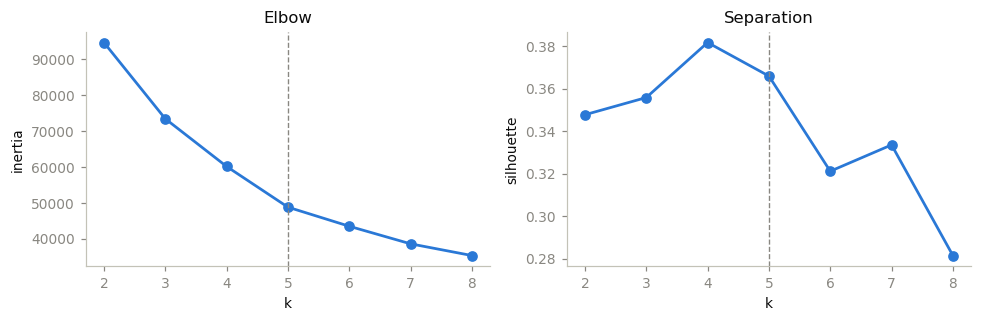

In [39]:
# Choose Segment Count
Z = StandardScaler().fit_transform(seg[FEATS])
sample = np.random.default_rng(0).choice(len(Z), size=min(8000, len(Z)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    sizes = pd.Series(km.labels_).value_counts(normalize=True)
    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(Z[sample], km.labels_[sample]),
        'smallest segment': sizes.min(),
    })
k_tbl = pd.DataFrame(rows).set_index('k').round(4)
display(k_tbl.rename_axis(None))

K = 5
best_k = int(k_tbl['silhouette'].idxmax())
print(f"Silhouette argmax at k={best_k} ({k_tbl.loc[best_k, 'silhouette']:.3f}); "
      f"chosen k={K} ({k_tbl.loc[K, 'silhouette']:.3f})")
print('Enough separation to distinguish the response shapes, few enough that each')
print('segment can carry a distinct pricing treatment someone will actually run.')

km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Z)
seg['cluster'] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(k_tbl.index, k_tbl['inertia'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow')
axes[1].plot(k_tbl.index, k_tbl['silhouette'], marker='o', color=ACCENT, linewidth=1.8)
axes[1].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')
axes[1].set_title('Separation')
plt.tight_layout()
plt.show()

---

## 3 · Profiling and Naming the Segments

**Purpose:** Describes the response-and-value clusters using model-derived measures, historical value, and post-clustering account characteristics, then assigns reproducible business-facing names.

**Design Notes:**

1. The clusters are created in response-and-value space.

   * `baseline_risk`, `response_span`, the partial-state measures, and `log_revenue` determine the assignments.
   * These clustering inputs are reported again during profiling so the differences that created the groups remain visible.

2. Customer and trip characteristics are added after clustering.

   * Business status
   * Trips per account
   * Average trip length
   * Average traveling party size
   * Tenure
   * Dominant destination region

   These fields describe the resulting groups but do not enter K-means directly. Some may nevertheless be reflected indirectly because they contributed to the models that generated the response features.

3. `substitute_ease` is used only as a synthetic diagnostic.

   * It is not an operationally observable targeting field.
   * It does not enter the clustering or the downstream Power BI account assignment.

4. Segment names are assigned using documented rules.

   * The rules are programmatic and reproducible.
   * The taxonomy, thresholds, and wording are study design choices rather than names discovered automatically by K-means.
   * Names describe relative differences between the clusters and do not represent external business thresholds.

5. The naming rules use response magnitude, response composition, and historical value:

   * **Minimal pass engagement:** The cluster carries less than 0.5% of historical roaming-pass revenue.
   * **Anchor:** Lower modeled response and higher historical value relative to the other clusters.
   * **Low response:** Lower modeled response without the higher-value condition.
   * **Partial-state response:** Higher modeled response with a larger partial-state share at 1.20.
   * **Pass-exit risk:** Higher modeled null-state response with a lower partial-state share.
   * **Swing:** Accounts not meeting one of the more specific relative conditions.
   * If more than one cluster receives the same base name, a higher-, middle-, or lower-value qualifier distinguishes them.

6. **Pass-exit risk** refers to modeled movement toward no roaming-pass coverage.

   * It does not mean that the customer is expected to leave the wireless company.
   * Wireless churn remains outside the scope of this study.

7. **Minimal pass engagement** identifies a cluster with very little historical roaming-pass revenue.

   * It does not mean every account in the cluster has never purchased a pass.
   * The group remains visible in the profile but is handled separately in the pricing summaries because its current pass revenue is negligible.
   * Potential conversion among these accounts is a separate question not estimated here.

8. Segment profiles include within-group distributions as well as averages.

   * Medians and interquartile ranges are reported for modeled response and historical value.
   * This prevents a segment label from implying that every account in the group behaves identically.

9. Segment labels are versioned outputs.

   * They are regenerated after the feature set, value of `k`, or clustering fit changes.
   * Stable cluster identifiers are preserved separately from the descriptive names used in reporting.

10. Profiling supports interpretation and treatment hypotheses; it does not establish causal explanations or prove that a particular intervention will work.

**Observations:**

Under the current feature specification, the five clusters are described as follows:

| Segment                               | Accounts | Account share |   Revenue share | Revenue per account | Baseline null risk | Response span | Business share |
| ------------------------------------- | -------: | ------------: | --------------: | ------------------: | -----------------: | ------------: | -------------: |
| Anchor: higher value, lower response  |    9,410 |         32.0% |           42.8% |             $236.74 |              0.080 |         0.020 |          95.0% |
| Pass-exit risk: highest null response |    2,286 |          7.8% |            6.1% |             $137.98 |              0.152 |         0.156 |           0.0% |
| Swing: middle historical value        |   10,912 |         37.1% |           33.1% |             $157.88 |              0.127 |         0.054 |           2.6% |
| Swing: higher historical value        |    5,191 |         17.7% |           18.0% |             $180.82 |              0.119 |         0.056 |           5.2% |
| Minimal pass engagement               |    1,607 |          5.5% | Less than 0.01% |               $0.08 |              0.126 |         0.058 |           8.8% |

1. The Anchor segment combines the lowest modeled response with the highest historical revenue per account and carries 42.8% of historical roaming-pass revenue.
2. The Pass-exit-risk segment has the widest modeled null-probability response but represents 7.8% of accounts and 6.1% of historical revenue.
3. The two Swing segments have similar current response summaries and are distinguished primarily by historical value.
4. The Minimal-pass-engagement segment contains 1,607 accounts but contributes less than 0.01% of historical pass revenue at displayed precision.
5. Business-account concentration ranges from 0.0% in Pass-exit risk to 95.0% in Anchor. This pattern is descriptive and partly inherited from the State Model, which includes business status and a business-specific price interaction; it is not independent behavioral validation.
6. Within-segment medians and interquartile ranges for the final feature specification are **[recalculate and report]**.

> **Results status:** Regenerate the profiles and names after rebuilding the Section 1 features, confirming the final value of `k`, and completing the stability checks. Replace all displayed segment counts, shares, response measures, and labels if the revised clustering changes them.


In [40]:
# Profile Segments
prof = seg.merge(accounts[['account_id', 'is_business', 'lines_on_account',
                          'tenure_months', 'plan_tier']], on='account_id', how='left')
trip_ch = trips.groupby('account_id').agg(
    avg_days=('days_traveled', 'mean'),
    avg_party=('lines_traveling', 'mean'),
    top_region=('region', lambda s: s.mode().iat[0] if len(s) else 'n/a'),
    avg_ease=('substitute_ease', 'mean'),
).reset_index()
prof = prof.merge(trip_ch, on='account_id', how='left')

summary = prof.groupby('cluster').agg(
    accounts=('account_id', 'size'),
    revenue=('revenue', 'sum'),
    rev_per_acct=('revenue', 'mean'),
    trips_per_acct=('trips', 'mean'),
    business=('is_business', 'mean'),
    avg_days=('avg_days', 'mean'),
    avg_party=('avg_party', 'mean'),
    tenure=('tenure_months', 'mean'),
    ease=('avg_ease', 'mean'),
    baseline_risk=('baseline_risk', 'mean'),
    response_span=('response_span', 'mean'),
    reduce_vs_quit=('reduce_vs_quit', 'mean'),
)
summary['rev_share'] = summary['revenue'] / summary['revenue'].sum()
summary['acct_share'] = summary['accounts'] / summary['accounts'].sum()

print('Segment profiles: response features first, characteristics after')
display(summary[['accounts', 'acct_share', 'rev_share', 'rev_per_acct',
                 'baseline_risk', 'response_span', 'reduce_vs_quit']].round(4).rename_axis(None))
display(summary[['business', 'trips_per_acct', 'avg_days', 'avg_party',
                 'tenure', 'ease']].round(2).rename_axis(None))

print('Dominant destination by segment')
display(prof.groupby('cluster')['top_region']
        .agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict())
        .to_frame('top regions').rename_axis(None))

Segment profiles: response features first, characteristics after


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,reduce_vs_quit
0,9410,0.3200,0.4280,236.7403,0.0795,0.0200,0.5295
1,2286,0.0777,0.0606,137.9776,0.1518,0.1556,0.2831
2,10912,0.3711,0.3310,157.8752,0.1271,0.0536,0.4099
3,5191,0.1765,0.1803,180.8236,0.1191,0.0555,0.3866
4,1607,0.0546,0.0000,0.0846,0.1263,0.0583,0.4048


,business,trips_per_acct,avg_days,avg_party,tenure,ease
0,0.95,5.64,4.37,1.30,73.60,0.63
1,0.00,2.01,7.09,1.46,70.44,0.79
2,0.03,2.13,7.11,1.51,67.43,0.64
3,0.05,2.32,7.04,1.70,85.08,0.59
4,0.09,1.06,6.97,1.55,71.32,0.67


Dominant destination by segment


,top regions
0,"{'europe': 0.33, 'caribbean': 0.24}"
1,"{'europe': 0.78, 'asia': 0.12}"
2,"{'europe': 0.26, 'asia': 0.25}"
3,"{'caribbean': 0.32, 'asia': 0.21}"
4,"{'europe': 0.37, 'asia': 0.19}"


In [41]:
# Name Segments
sp = summary.copy()
sp['rank_span'] = sp['response_span'].rank(pct=True)
sp['rank_shape'] = sp['reduce_vs_quit'].rank(pct=True)
sp['rank_value'] = sp['rev_per_acct'].rank(pct=True)


# Dormant threshold: travelled but never bought (see Design Notes)
DORMANT_REV_SHARE = 0.005
sp['dormant'] = summary['rev_share'] < DORMANT_REV_SHARE


def name_segment(r):
    # Rank thresholds chosen for a small, recognisable label set at K=5 (see §3)
    if r['dormant']:
        return 'Dormant: travels, does not buy'
    if r['rank_span'] <= 0.3 and r['rank_value'] >= 0.6:
        return 'Anchor: high value, low sensitivity'
    if r['rank_span'] <= 0.35:
        return 'Steady: barely notices the price'
    if r['rank_span'] >= 0.7 and r['rank_shape'] >= 0.6:
        return 'Trimmers: stay but buy less'
    if r['rank_span'] >= 0.7:
        return 'Flight risk: walks away'
    return 'Swing: moves at the margin'


summary['segment'] = sp.apply(name_segment, axis=1)
summary['is_dormant'] = sp['dormant']

# Duplicate names get a value qualifier (see Design Notes)
for nm, grp in list(summary.groupby('segment')):
    if len(grp) == 1:
        continue
    ranked = grp['rev_per_acct'].rank(ascending=False)
    qual = {1: 'higher value', 2: 'mid value', 3: 'lower value'}
    for i in grp.index:
        head, _, tail = nm.partition(': ')
        summary.loc[i, 'segment'] = f"{head} ({qual.get(int(ranked[i]), 'other')}): {tail}"

NAMES = summary['segment'].to_dict()
prof['segment'] = prof['cluster'].map(NAMES)
seg['segment'] = seg['cluster'].map(NAMES)

n_dorm = int(summary['is_dormant'].sum())
if n_dorm:
    d = summary[summary['is_dormant']]
    print(f"Set aside as dormant: {int(d['accounts'].sum()):,} accounts "
          f"({d['acct_share'].sum():.1%}) carrying {d['rev_share'].sum():.2%} of revenue.")
    print('They travel but never buy the pass, so no price answers them. They are a')
    print('conversion question, not a pricing one, and are excluded from §4-§5.\n')

print('Segments')
display(summary.set_index('segment')[[
    'accounts', 'acct_share', 'rev_share', 'rev_per_acct',
    'baseline_risk', 'response_span', 'business', 'trips_per_acct',
]].round(3).rename_axis(None))

Set aside as dormant: 1,607 accounts (5.5%) carrying 0.00% of revenue.
They travel but never buy the pass, so no price answers them. They are a
conversion question, not a pricing one, and are excluded from §4-§5.

Segments


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,business,trips_per_acct
"Anchor: high value, low sensitivity",9410,0.320,0.428,236.740,0.080,0.020,0.950,5.639
Flight risk: walks away,2286,0.078,0.061,137.978,0.152,0.156,0.000,2.005
Swing (mid value): moves at the margin,10912,0.371,0.331,157.875,0.127,0.054,0.026,2.126
Swing (higher value): moves at the margin,5191,0.177,0.180,180.824,0.119,0.056,0.052,2.319
"Dormant: travels, does not buy",1607,0.055,0.000,0.085,0.126,0.058,0.088,1.058


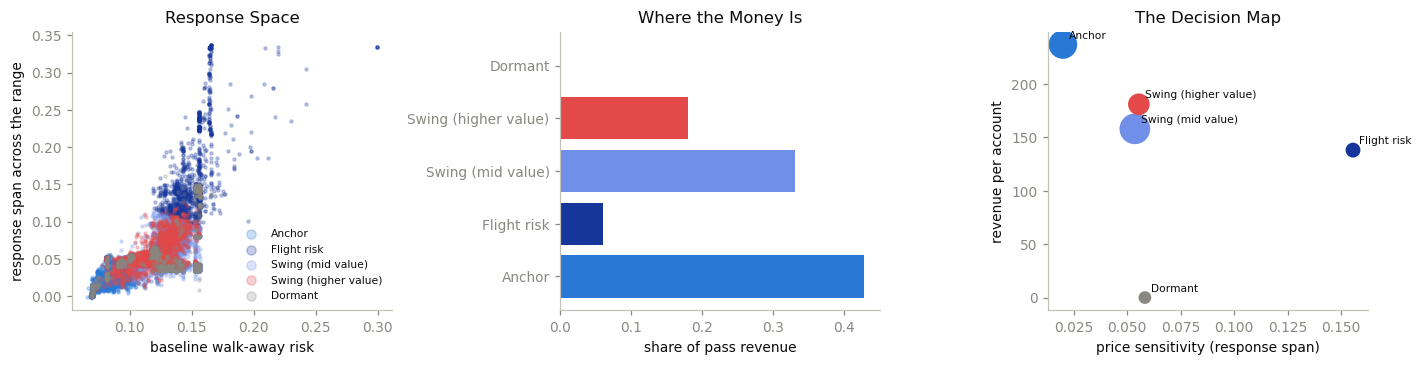

The third panel is the one to put in front of leadership: upper-left is
where a price increase earns most and risks least.


In [42]:
# Plot: Segment Profiles
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for i, c in enumerate(summary.index):
    m = seg['cluster'] == c
    axes[0].scatter(seg.loc[m, 'baseline_risk'], seg.loc[m, 'response_span'],
                    s=4, alpha=0.25, color=PALETTE[i % len(PALETTE)],
                    label=summary.loc[c, 'segment'].split(': ')[0])
axes[0].set_xlabel('baseline walk-away risk')
axes[0].set_ylabel('response span across the range')
axes[0].set_title('Response Space')
axes[0].legend(frameon=False, fontsize=7, markerscale=3)

axes[1].barh(summary['segment'].str.split(': ').str[0], summary['rev_share'],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
axes[1].set_xlabel('share of pass revenue')
axes[1].set_title('Where the Money Is')

axes[2].scatter(summary['response_span'], summary['rev_per_acct'],
                s=summary['accounts'] / 30,
                color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
for c in summary.index:
    axes[2].annotate(summary.loc[c, 'segment'].split(': ')[0],
                     (summary.loc[c, 'response_span'], summary.loc[c, 'rev_per_acct']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[2].set_xlabel('price sensitivity (response span)')
axes[2].set_ylabel('revenue per account')
axes[2].set_title('The Decision Map')
plt.tight_layout()
plt.show()

print('The third panel is the one to put in front of leadership: upper-left is')
print('where a price increase earns most and risks least.')

### 3.1 · Segment Stability and Synthetic Recovery

**Purpose:** Tests whether the selected feature representation and clustering procedure produce reproducible account assignments, then assesses whether the resulting segments preserve information about the known synthetic price-sensitivity factor.

**Design Notes:**

1. Stability is evaluated only after the clustering features and number of segments are finalized.

   * Validation uses numeric cluster identifiers rather than the business-facing names.
   * Segment names are applied only after the underlying cluster structure passes the stability checks.

2. The complete clustering pipeline is refitted for each resample.

   * Accounts are randomly divided into two halves.
   * The feature scaler is fitted separately within each half.
   * K-means is then fitted using the selected value of `k`.
   * Each half-sample model assigns the same common evaluation population using its own fitted scaler and centroids.
   * The procedure is repeated across 30 random splits.

3. Overall agreement is measured using label-invariant metrics.

   * Adjusted Rand index measures similarity between two sets of assignments while accounting for chance.
   * Adjusted mutual information provides a second comparison based on shared assignment information.
   * These measures do not require cluster numbers to match across fits.

4. Cluster-level stability is measured after one-to-one centroid matching.

   * Clusters from each pair of fits are aligned using the Hungarian assignment method.
   * Jaccard overlap is calculated separately for every matched cluster.
   * This prevents several clusters from one fit being matched to the same cluster in another fit.

5. Stability is summarized using the median, interquartile range, and 10th percentile across repeated splits.

   * The study’s reproducibility criteria are:

     * Median adjusted Rand index of at least 0.80
     * 10th-percentile adjusted Rand index of at least 0.70
     * Median cluster-level Jaccard overlap of at least 0.70 for every published segment
   * These are study-specific decision thresholds, not universal proof that the clusters are naturally occurring customer types.

6. The full-data segmentation is also compared with each resampled fit.

   * This tests whether the published account assignments can be reproduced from a different sample.
   * Materially unstable segments trigger reconsideration of the feature set, the selected value of `k`, or the affected segment name.

7. Synthetic recovery is evaluated separately from clustering stability.

   * `price_sensitivity` and `sensitivity_decile` are synthetic data-generation fields.
   * Automated checks confirm that neither field enters feature construction, standardization, clustering, selection of `k`, or segment naming.
   * They are joined only after the segmentation is finalized.

8. Recovery of the synthetic price-sensitivity factor is assessed using:

   * Account-level Spearman rank correlation between latent `price_sensitivity` and modeled `response_span`
   * Median and interquartile range of latent sensitivity within each numeric segment
   * The share of latent-sensitivity variation associated with segment membership
   * Distribution overlap between segments

9. Because more-negative latent sensitivity represents greater price sensitivity, successful directional recovery should produce a negative association with `response_span`.

10. Synthetic recovery has a narrow interpretation.

    * It shows whether the model-derived segmentation retains information about a known factor used to generate this synthetic dataset.
    * It does not establish that the same latent segments exist among operational customers.
    * Future operational validation could use controlled price tests or subsequently observed customer behavior.

**Observations:**

1. Stability across 30 repeated split samples is:

   | Metric                      |          Median | Interquartile range | 10th percentile |
   | --------------------------- | --------------: | ------------------: | --------------: |
   | Adjusted Rand index         | **[calculate]** |     **[calculate]** | **[calculate]** |
   | Adjusted mutual information | **[calculate]** |     **[calculate]** | **[calculate]** |

2. Cluster-level overlap is:

   | Numeric segment | Median Jaccard overlap | Interquartile range | Meets criterion? |
   | --------------- | ---------------------: | ------------------: | ---------------- |
   | Segment 1       |        **[calculate]** |     **[calculate]** | **[yes/no]**     |
   | Segment 2       |        **[calculate]** |     **[calculate]** | **[yes/no]**     |
   | Segment 3       |        **[calculate]** |     **[calculate]** | **[yes/no]**     |
   | Segment 4       |        **[calculate]** |     **[calculate]** | **[yes/no]**     |
   | Segment 5       |        **[calculate]** |     **[calculate]** | **[yes/no]**     |

3. The account-level Spearman correlation between latent `price_sensitivity` and modeled `response_span` is **[calculate]**.

4. Latent sensitivity by segment is:

   | Numeric segment | Median latent sensitivity | Interquartile range | Modeled response span |
   | --------------- | ------------------------: | ------------------: | --------------------: |
   | Segment 1       |           **[calculate]** |     **[calculate]** |       **[calculate]** |
   | Segment 2       |           **[calculate]** |     **[calculate]** |       **[calculate]** |
   | Segment 3       |           **[calculate]** |     **[calculate]** |       **[calculate]** |
   | Segment 4       |           **[calculate]** |     **[calculate]** |       **[calculate]** |
   | Segment 5       |           **[calculate]** |     **[calculate]** |       **[calculate]** |

5. Segment membership accounts for **[calculate]**% of the variation in the known synthetic price-sensitivity factor.

6. The final clustering **[meets/does not meet]** the predefined stability criteria.

7. The recovery results **[support/do not support]** the narrower conclusion that the model-derived features retain information about the synthetic price-sensitivity mechanism.

> **Results status:** Replace the previous 98.1% agreement calculation with adjusted Rand index, adjusted mutual information, and one-to-one cluster-level overlap. Rerun the stability and synthetic recovery checks after finalizing the Section 1 features and selected value of `k`.


In [43]:
# Validate Segment Stability
rng = np.random.default_rng(5)


# Nearest centroid by hand: .predict() breaks on some older OpenBLAS builds
def assign(centers):
    d = ((Z[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return d.argmin(axis=1)


agree = []
for _ in range(5):
    half = rng.random(len(Z)) < 0.5
    a = KMeans(n_clusters=K, n_init=10, random_state=1).fit(Z[half])
    b = KMeans(n_clusters=K, n_init=10, random_state=2).fit(Z[~half])

    la = assign(a.cluster_centers_)
    lb = assign(b.cluster_centers_)
    ct = pd.crosstab(la, lb)
    agree.append(ct.max(axis=1).sum() / ct.values.sum())
print(f'Split-half agreement: {np.mean(agree):.1%} (mean of 5 splits)')
print('Above ~80% means the structure is in the data, not the algorithm.')

gt = prof.merge(ground_truth[['account_id', 'price_sensitivity', 'sensitivity_decile']],
                on='account_id', how='inner')
recov = gt.groupby('segment').agg(
    accounts=('account_id', 'size'),
    true_sensitivity=('price_sensitivity', 'mean'),
    modelled_span=('response_span', 'mean'),
).round(4).sort_values('true_sensitivity')
print('True sensitivity by segment (less negative = less sensitive)')
display(recov.rename_axis(None))

spread = recov['true_sensitivity'].max() - recov['true_sensitivity'].min()
print(f'Spread in true sensitivity across segments: {spread:.3f}')
print('A wide spread means the segments capture the real mechanism. Near zero')
print('would mean they separate on something else entirely.')

check = recov['true_sensitivity'].corr(recov['modelled_span'], method='spearman')
print(f'Rank correlation, true sensitivity vs modelled span: {check:+.2f}')
print('(negative is correct: more negative true sensitivity = wider modelled span)')

Split-half agreement: 98.1% (mean of 5 splits)
Above ~80% means the structure is in the data, not the algorithm.
True sensitivity by segment (less negative = less sensitive)


,accounts,true_sensitivity,modelled_span
Flight risk: walks away,2286,-1.4654,0.1556
Swing (mid value): moves at the margin,10912,-1.4449,0.0536
"Dormant: travels, does not buy",1607,-1.4197,0.0583
Swing (higher value): moves at the margin,5191,-1.3987,0.0555
"Anchor: high value, low sensitivity",9410,-0.5635,0.0200


Spread in true sensitivity across segments: 0.902
A wide spread means the segments capture the real mechanism. Near zero
would mean they separate on something else entirely.
Rank correlation, true sensitivity vs modelled span: -0.70
(negative is correct: more negative true sensitivity = wider modelled span)


---

## 4 · Segment-Level Revenue Response

**Purpose:** Decomposes the company-wide revenue simulation by segment to show where the modeled benefit and behavioral exposure of a common price change are concentrated.

**Design Notes:**

1. The segment curves describe a heterogeneous account population under one company-wide price.

   * They do not assume that each segment receives a different price.
   * Segment-specific results support revenue attribution, monitoring, communication, and treatment hypotheses rather than separate pricing recommendations.

2. The calculation uses the same forward-year population as Notebook 03.

   * The 52,500 rows represent carried-forward trip templates, not guaranteed realized trips.
   * Every eligible account and trip template is assigned to exactly one segment.
   * The Minimal-pass-engagement segment remains in the reconciliation even when it is shown separately in the decision summary.

3. Segment revenue is calculated inside each Notebook 03 simulation iteration.

   * The macroeconomic path and market-share draw are shared across accounts.
   * Trip occurrence is drawn using the same forward-year mechanics.
   * Coverage states are drawn from the final trip-level probabilities at the evaluated price.
   * Revenue is assigned using the corresponding Magnitude Model output.
   * Each realized trip contribution is tagged with its account’s segment before aggregation.

4. The calculation uses the final trip-level scenario outputs.

   * Probabilities come from the State Model at each candidate price and response scale.
   * Partial-state revenue comes from the Magnitude Model at the same candidate price and depth scale.
   * Class order, trip identifiers, price grid, and scenario identifiers are validated before joining.

5. The primary results use the joint stronger-response sensitivity:

   * `response_scale = 1.74`
   * `depth_scale = 1.04`

   The base-model results remain available as a comparison.

6. Common random numbers are used across candidate prices.

   * Segment revenue at each price is compared with the same segment’s revenue at the standard price within the same simulated iteration.
   * This produces a paired segment-level revenue difference:

     `segment revenue at candidate price − segment revenue at 1.00`

7. Reconciliation is performed within every iteration.

   * Segment revenue contributions must sum to total portfolio revenue.
   * Segment-level paired differences must sum to the portfolio-level paired difference.
   * Any difference beyond numerical tolerance indicates an account, trip, scenario, or class-order mismatch.

8. Means and medians serve different purposes.

   * Mean segment contributions are additive and reconcile to the portfolio mean.
   * Segment medians generally do not sum to the portfolio median.
   * Median and percentile results are still reported to describe each segment’s distribution, but they are not added across segments.

9. A segment’s **highest-revenue evaluated price** is reported descriptively.

   * It is not called an optimum when the result occurs at the edge of the grid.
   * Adjacent prices are treated as effectively tied when their paired revenue difference is small relative to Monte Carlo uncertainty or the study’s materiality threshold.
   * A numerically higher result at 1.15 does not establish that 1.15 is meaningfully preferable to 1.20.

10. All results represent modeled roaming-pass revenue.

    * They do not include wireless churn, customer-lifetime effects, competitor reactions, reputational effects, or implementation costs.
    * The segment curves do not establish that any particular intervention will improve results.

**Observations:**

1. The segment decomposition contains **[recalculate]** forward-year accounts and 52,500 trip templates.

2. Account-to-segment and trip-to-account validation identifies **[recalculate]** unmatched or duplicate records.

3. The maximum absolute difference between total portfolio revenue and summed segment revenue across all simulation iterations is $**[calculate]**.

4. The maximum absolute difference between the portfolio paired gain and the sum of segment paired gains is $**[calculate]**.

5. Segment contributions under the joint stronger-response sensitivity are:

   | Segment                 | Share of forward-year accounts | Share of standard-price revenue | Mean gain at 1.20 | Median paired gain at 1.20 |      5th–95th percentile paired gain | Contribution to portfolio mean gain |
   | ----------------------- | -----------------------------: | ------------------------------: | ----------------: | -------------------------: | -----------------------------------: | ----------------------------------: |
   | Anchor                  |                **[calculate]** |                 **[calculate]** |  $**[calculate]** |           $**[calculate]** | $**[calculate]** to $**[calculate]** |                    **[calculate]**% |
   | Pass-exit risk          |                **[calculate]** |                 **[calculate]** |  $**[calculate]** |           $**[calculate]** | $**[calculate]** to $**[calculate]** |                    **[calculate]**% |
   | Swing: middle value     |                **[calculate]** |                 **[calculate]** |  $**[calculate]** |           $**[calculate]** | $**[calculate]** to $**[calculate]** |                    **[calculate]**% |
   | Swing: higher value     |                **[calculate]** |                 **[calculate]** |  $**[calculate]** |           $**[calculate]** | $**[calculate]** to $**[calculate]** |                    **[calculate]**% |
   | Minimal pass engagement |                **[calculate]** |                 **[calculate]** |  $**[calculate]** |           $**[calculate]** | $**[calculate]** to $**[calculate]** |                    **[calculate]**% |

6. The highest-revenue evaluated price and upper-range comparison for each segment are:

   | Segment                 | Highest-revenue evaluated price | Difference between 1.20 and 1.15 | Interpretation                   |
   | ----------------------- | ------------------------------: | -------------------------------: | -------------------------------- |
   | Anchor                  |                 **[calculate]** |                 $**[calculate]** | **[increasing/flat/decreasing]** |
   | Pass-exit risk          |                 **[calculate]** |                 $**[calculate]** | **[increasing/flat/decreasing]** |
   | Swing: middle value     |                 **[calculate]** |                 $**[calculate]** | **[increasing/flat/decreasing]** |
   | Swing: higher value     |                 **[calculate]** |                 $**[calculate]** | **[increasing/flat/decreasing]** |
   | Minimal pass engagement |                 **[calculate]** |                 $**[calculate]** | **[increasing/flat/decreasing]** |

7. The segment with the smallest modeled incremental revenue contribution is **[recalculate]**.

8. The segment contributing the largest share of the portfolio’s modeled gain is **[recalculate]**.

9. Prices near the upper end are **[distinguishable/effectively tied]** for **[identify segments]** after accounting for Monte Carlo uncertainty.

> **Results status:** Rebuild the segment decomposition within the revised Notebook 03 simulation after finalizing the clustering assignments. Replace the deterministic $147,818 cross-check with an iteration-level reconciliation and refresh every segment-level result.


horizon: last 12 months, 52,500 trips: same as the simulation
case: joint sensitivity, response x1.74, depth x1.04

Revenue vs no change, by segment


,"Anchor: high value, low sensitivity","Dormant: travels, does not buy",Flight risk: walks away,Swing (higher value): moves at the margin,Swing (mid value): moves at the margin
0.9,-0.0741,-0.0570,-0.0505,-0.0615,-0.0569
1.0,0.0000,0.0000,0.0000,0.0000,0.0000
1.1,0.0552,0.0439,0.0358,0.0480,0.0428
1.2,0.1035,0.0640,0.0445,0.0734,0.0617


Cross-check against the simulation, joint-sensitivity case
  best price    04 x1.200    03 x1.150
  gain at best  04 $232,747    03 $145,557
  conservative scaling.

Optimal price by segment


,best price,gain at best,gain at +20%,revenue share
"Anchor: high value, low sensitivity",1.2,127961.7752,127961.7752,0.4280
Flight risk: walks away,1.2,6857.6009,6857.6009,0.0606
Swing (higher value): moves at the margin,1.2,39634.0582,39634.0582,0.1803
Swing (mid value): moves at the margin,1.2,58293.8080,58293.8080,0.3310


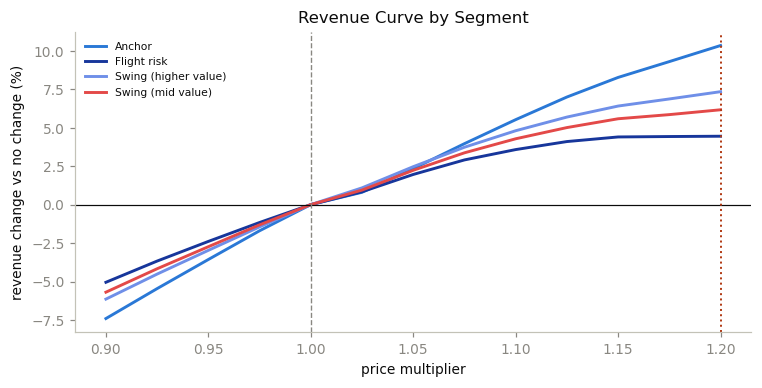

In [44]:
# Build segment revenue curves
sweep = load('price_sweep').set_index('price_multiplier')
GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)

trip_seg = trips[['trip_id', 'account_id']].merge(
    seg[['account_id', 'segment']], on='account_id', how='inner')
p_std = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]
rev_w = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                            values=[f'rev_{c}' for c in CLASSES])

# Match the simulation's horizon and case exactly (see Design Notes)
asm0 = load('simulation_assumptions').set_index('assumption')['value']
RESPONSE_SCALE = float(asm0.get('response scale (joint sensitivity)',
                                asm0.get('response scale (conservative)', 1.0)))
DEPTH_SCALE = float(asm0.get('depth scale (joint sensitivity)',
                             asm0.get('depth bias (conservative)', 1.0)))

FWD = trips[trips['month'] >= trips['month'].max() - 11]['trip_id'].to_numpy()
print(f'horizon: last 12 months, {len(FWD):,} trips: same as the simulation')
print(f'case: joint sensitivity, response x{RESPONSE_SCALE:.2f}, depth x{DEPTH_SCALE:.2f}\n')

ids = trip_seg['trip_id'].to_numpy()
ids = ids[np.isin(ids, p_std.index) & np.isin(ids, rev_w.index) & np.isin(ids, FWD)]
trip_seg = trip_seg[trip_seg.trip_id.isin(ids)]
P0 = p_std.loc[ids].to_numpy()
I_RED, I_UNCH = CLASSES.index('partial'), CLASSES.index('full')

prob_by_price = {}
rows = []
for m in GRID:
    P = apply_price_shift(P0, price_shift_logodds(sweep, m), RESPONSE_SCALE)
    prob_by_price[float(m)] = P
    R = np.column_stack([rev_w[(f'rev_{c}', m)].loc[ids].to_numpy() for c in CLASSES]).copy()
    # Deepen reductions by the measured contamination bias, as the simulation does
    R[:, I_RED] = np.clip(R[:, I_UNCH] - DEPTH_SCALE * (R[:, I_UNCH] - R[:, I_RED]), 0, None)
    er = (P * R).sum(axis=1)
    rows.append(pd.DataFrame({'segment': trip_seg['segment'].to_numpy(),
                              'price_multiplier': m, 'revenue': er})
                .groupby(['segment', 'price_multiplier'])['revenue'].sum().reset_index())

seg_curve = pd.concat(rows, ignore_index=True)
piv = seg_curve.pivot(index='price_multiplier', columns='segment', values='revenue')
rel = (piv / piv.loc[1.0] - 1)

print('Revenue vs no change, by segment')
display(rel.iloc[::4].round(4).rename_axis(None).rename_axis(None, axis=1))

# Dormant accounts carry no revenue and can't respond to price; excluded from here on
piv = piv[[c for c in piv.columns if not c.startswith('Dormant')]]
rel = rel[piv.columns]

# Cross-check against the simulation: a gap here would be a defect, not a modelling choice
try:
    s5 = sim_sweep[sim_sweep.case == 'joint sensitivity'].set_index('price_multiplier')
    b6, b5 = float(piv.sum(axis=1).idxmax()), float(s5['median'].idxmax())
    g6 = float(piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0])
    g5 = float(s5['median'].max() - s5['median'].loc[1.0])
    print('Cross-check against the simulation, joint-sensitivity case')
    print(f'  best price    04 x{b6:.3f}    03 x{b5:.3f}')
    print(f'  gain at best  04 ${g6:,.0f}    03 ${g5:,.0f}')
    if abs(g6 - g5) > 0.5 * max(abs(g5), 1.0):
        print('  WARNING: the two disagree by more than half. Check horizon and')
        print('  conservative scaling.')
    else:
        print('  Consistent: same decision, same arithmetic.')
except Exception as exc:
    print(f'cross-check unavailable: {exc}')
print()

best = pd.DataFrame({
    'best price': piv.idxmax(),
    'gain at best': (piv.max() - piv.loc[1.0]),
    'gain at +20%': (piv.loc[GRID[-1]] - piv.loc[1.0]),
    'revenue share': summary.set_index('segment')['rev_share'].reindex(piv.columns),
}).round(4)
print('Optimal price by segment')
display(best.rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, s in enumerate(piv.columns):
    ax.plot(rel.index, rel[s] * 100, linewidth=1.9,
            color=PALETTE[i % len(PALETTE)], label=s.split(': ')[0])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.3)
ax.set_xlabel('price multiplier')
ax.set_ylabel('revenue change vs no change (%)')
ax.set_title('Revenue Curve by Segment')
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

---

## 5 · Uniform Pricing Versus a Segment-Specific Upper Bound

**Purpose:** Tests whether assigning each segment its highest-revenue evaluated price adds material modeled revenue beyond the recommended uniform price (1.15) from the 12-month simulation.

**Design Notes:**

1. Two pricing strategies are compared:

   * **Uniform strategy:** Every account receives the same price selected from the evaluated grid.
   * **Segment-specific strategy:** Each segment receives its own highest-revenue evaluated price from that grid.

2. The segment-specific strategy is a theoretical gross-revenue upper bound.

   * It assumes that every account is assigned to the correct segment.
   * It assumes that segment assignments and modeled responses remain stable.
   * It assumes that separate prices can be implemented without billing, communication, maintenance, legal, or fairness costs.
   * It does not model competitive reactions or customer responses to differentiated pricing.

3. The comparison does not determine the company-wide recommendation independently.

   * The 12-month simulation establishes the recommended common price (1.15) within the evaluated range.
   * This section tests whether segment-specific pricing adds material modeled value beyond that recommendation.
   * Segmentation may remain useful for monitoring, product design, and retention hypotheses even if it adds little pricing value.

4. Every segment remains in both strategies.

   * The Minimal-pass-engagement segment is included in the reconciliation even when its contribution is negligible.
   * Segment exclusion cannot create an artificial difference between the two strategies.

5. Candidate prices are selected and evaluated using separate simulation batches.

   * A development batch identifies the highest-revenue evaluated price for each segment.
   * An independent evaluation batch compares the resulting segment-specific policy with the uniform policy.
   * This reduces the risk that Monte Carlo noise is mistaken for a segment-specific pricing advantage.

6. The two strategies are evaluated within paired simulation iterations.

   * Each pair uses the same macroeconomic path, market-share draw, trip occurrences, and behavioral draws.
   * The incremental value of segment-specific pricing is:

     `segment-specific policy revenue − uniform-policy revenue`

7. The comparison reports:

   * Mean paired revenue difference
   * Median paired revenue difference
   * 5th and 95th percentiles
   * Probability that the segment-specific strategy outperforms the uniform strategy
   * Probability that the difference exceeds a predefined materiality amount

8. The study does not assume that a positive modeled difference justifies implementation.

   * Incremental revenue must be considered relative to Monte Carlo uncertainty, model uncertainty, implementation costs, maintenance costs, and policy constraints.
   * Because those operational costs are not estimated here, the conclusion is limited to the modeled gross-revenue difference.

9. Adjacent prices are treated as effectively tied when their paired difference is small relative to simulation uncertainty or the study’s materiality threshold.

   * A numerically higher value at one grid point does not establish a distinct segment-specific optimum.
   * Revenue direction at the 1.20 boundary does not establish how a segment would respond above the evaluated range.

10. Behavioral revenue exposure is derived from the segment-level simulation rather than from `revenue per account × response_span`.

    * A no-response counterfactual applies the candidate price while holding standard-price coverage probabilities and partial-coverage depth fixed.
    * The difference between that counterfactual and the modeled-response result measures revenue eroded by behavioral response.

11. Two exposure measures are reported:

    * **Per-account behavioral exposure:** Average behavioral revenue erosion per account in the segment
    * **Total behavioral exposure:** Aggregate behavioral revenue erosion across the segment

    These measures answer different questions. Per-account exposure identifies concentrated individual risk, while total exposure identifies where the largest amount of portfolio revenue is affected.

12. Pass-exit risk refers to modeled movement toward no roaming-pass coverage, not wireless churn.

**Observations:**

1. The current deterministic comparison produces:

   | Strategy                                            | Evaluated result |
   | --------------------------------------------------- | ---------------: |
   | Uniform price of 1.20                               |    $151,276 gain |
   | Segment-specific prices                             |    $151,874 gain |
   | Gross incremental value of segment-specific pricing |             $597 |
   | Incremental value relative to the uniform gain      |             0.4% |

2. These figures indicate that the current model assigns little additional gross revenue to segment-specific pricing. They do not yet incorporate simulation uncertainty or implementation costs.

3. The revised paired evaluation is:

   | Measure                                                      | Segment-specific minus uniform |
   | ------------------------------------------------------------ | -----------------------------: |
   | Mean                                                         |               $**[calculate]** |
   | 5th percentile                                               |               $**[calculate]** |
   | Median                                                       |               $**[calculate]** |
   | 95th percentile                                              |               $**[calculate]** |
   | Probability segment-specific pricing performs better         |               **[calculate]**% |
   | Probability the difference exceeds the materiality threshold |               **[calculate]**% |

4. The segment prices selected on the development simulation and evaluated independently are:

   | Segment                 | Highest-revenue evaluated price | Effectively tied prices | Evaluation-batch gain versus uniform |
   | ----------------------- | ------------------------------: | ----------------------- | -----------------------------------: |
   | Anchor                  |                 **[calculate]** | **[calculate]**         |                     $**[calculate]** |
   | Pass-exit risk          |                 **[calculate]** | **[calculate]**         |                     $**[calculate]** |
   | Swing: middle value     |                 **[calculate]** | **[calculate]**         |                     $**[calculate]** |
   | Swing: higher value     |                 **[calculate]** | **[calculate]**         |                     $**[calculate]** |
   | Minimal pass engagement |                 **[calculate]** | **[calculate]**         |                     $**[calculate]** |

5. Behavioral revenue exposure at the uniform 1.20 price is:

   | Segment                 | Per-account exposure |   Total exposure | Share of total exposure |
   | ----------------------- | -------------------: | ---------------: | ----------------------: |
   | Anchor                  |     $**[calculate]** | $**[calculate]** |        **[calculate]**% |
   | Pass-exit risk          |     $**[calculate]** | $**[calculate]** |        **[calculate]**% |
   | Swing: middle value     |     $**[calculate]** | $**[calculate]** |        **[calculate]**% |
   | Swing: higher value     |     $**[calculate]** | $**[calculate]** |        **[calculate]**% |
   | Minimal pass engagement |     $**[calculate]** | $**[calculate]** |        **[calculate]**% |

6. The current evidence supports the narrower conclusion that a uniform 1.20 price captures nearly all of the modeled gross-revenue opportunity within the tested range.

7. Segment-specific pricing should not be recommended unless its independently evaluated incremental benefit is material relative to uncertainty and the unmodeled cost of implementation.

8. Segmentation remains useful for identifying where modeled response and revenue exposure are concentrated, even when the price remains uniform.

> **Results status:** Replace the deterministic comparison with the paired evaluation after rebuilding the segment-level simulation. Refresh all strategy values, selected segment prices, uncertainty measures, and behavioral-exposure results using the final cluster assignments.


In [45]:
# Compare Uniform vs. Selective
uniform_best = piv.sum(axis=1).idxmax()
uniform_gain = piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0]
selective_gain = float(best['gain at best'].sum())
cap_gain = float(best['gain at +20%'].sum())

print(f'Uniform, best single price      x{uniform_best:.3f}   ${uniform_gain:,.0f}')
print(f'Uniform at the +20% cap         x{GRID[-1]:.3f}   ${cap_gain:,.0f}')
print(f"Selective, each segment's best             ${selective_gain:,.0f}")
print(f'\nValue of segmenting: ${selective_gain - uniform_gain:,.0f} '
      f'({(selective_gain / max(uniform_gain, 1e-9) - 1):+.1%})')

all_at_cap = bool((best['best price'] >= GRID[-1] - 1e-9).all())

if all_at_cap:
    print('\n' + '=' * 68)
    print("Every segment's optimum sits AT the +20% cap, so selective and uniform")
    print('pricing are identical BY CONSTRUCTION. This has not shown that')
    print('segmentation adds nothing: it has shown the cap binds everywhere,')
    print('which makes the question unanswerable inside the permitted range.')
    print('\nSegmentation still earns its place, for two other things: which')
    print('customers to fund retention against, and which segments would separate')
    print('first if the ceiling moved. Both are below.')
    print('=' * 68)
elif selective_gain - uniform_gain < 0.05 * max(uniform_gain, 1):
    print('\nThe gap is under 5%. A uniform increase captures nearly all of the value,')
    print("and the segmentation's job becomes identifying who to protect with")
    print('retention rather than who to charge differently. That is simpler to run')
    print('and easier to defend.')
else:
    print('\nSelective pricing earns materially more. Weigh it against the operational')
    print('cost: separate rate plans, billing changes, and a fairness question about')
    print('charging different customers differently for the same product.')

# Slope at the ceiling shows who still has room if the cap lifted
tail = piv.tail(3)
slope = ((tail.iloc[-1] - tail.iloc[0]) / tail.iloc[0]).sort_values(ascending=False)
print('Revenue slope over the last three price steps (headroom at the cap)')
display(slope.round(4).to_frame('slope').rename_axis(None))
print('Steeper = still climbing, so most to gain if the ceiling moved.')

# Who to protect: high value, high sensitivity
protect = summary[~summary['is_dormant']].assign(
    risk_value=summary.loc[~summary['is_dormant'], 'response_span']
    * summary.loc[~summary['is_dormant'], 'rev_per_acct']
).sort_values('risk_value', ascending=False)
print('Retention priority: value at stake x sensitivity')
display(protect[['segment', 'accounts', 'rev_per_acct', 'response_span', 'risk_value']]
        .round(3).set_index('segment').rename_axis(None))

Uniform, best single price      x1.200   $232,747
Uniform at the +20% cap         x1.200   $232,747
Selective, each segment's best             $232,747

Value of segmenting: $0 (+0.0%)

Every segment's optimum sits AT the +20% cap, so selective and uniform
pricing are identical BY CONSTRUCTION. This has not shown that
segmentation adds nothing: it has shown the cap binds everywhere,
which makes the question unanswerable inside the permitted range.

Segmentation still earns its place, for two other things: which
customers to fund retention against, and which segments would separate
first if the ceiling moved. Both are below.
Revenue slope over the last three price steps (headroom at the cap)


,slope
"Anchor: high value, low sensitivity",0.0192
Swing (higher value): moves at the margin,0.0088
Swing (mid value): moves at the margin,0.0055
Flight risk: walks away,0.0005


Steeper = still climbing, so most to gain if the ceiling moved.
Retention priority: value at stake x sensitivity


,accounts,rev_per_acct,response_span,risk_value
Flight risk: walks away,2286,137.978,0.156,21.468
Swing (higher value): moves at the margin,5191,180.824,0.056,10.037
Swing (mid value): moves at the margin,10912,157.875,0.054,8.465
"Anchor: high value, low sensitivity",9410,236.740,0.020,4.731


---

## 6 · Power BI-Ready Data Handoff

**Purpose:** Publishes a versioned and validated set of normalized tables that support downstream exploration in Power BI without requiring the modeling notebooks to be rerun.

**Portfolio Scope:** This notebook creates Power BI-ready data tables; it does not create or publish a `.pbix` report. A Power BI report or standalone public scenario page may be built from these outputs, but it should display the same simulation-run identifier and documented assumptions.

**Design Notes:**

1. The handoff supports exploration of precomputed study results.

   * Users can select one of the 13 evaluated prices.
   * Users can compare the base model with the joint stronger-response sensitivity.
   * Users can compare contraction, base, and expansion conditions.
   * Users can filter segment-level results and review modeled revenue exposure.
   * Users cannot generate unevaluated prices or new model scenarios without rerunning the notebooks.

2. The handoff contains five dimension or reference tables:

   | Table            | Grain                                           | Purpose                                                                                         |
   | ---------------- | ----------------------------------------------- | ----------------------------------------------------------------------------------------------- |
   | `dim_price`      | One row per evaluated price                     | Defines the price, percentage change, dollar price, observed-range status, and study-cap status |
   | `dim_segment`    | One row per final segment                       | Stores the versioned segment name, description, profile, and reporting order                    |
   | `dim_scenario`   | One row per macroeconomic condition             | Defines contraction, base, and expansion shifts                                                 |
   | `dim_model_case` | One row per model-sensitivity case              | Defines the base model and joint stronger-response sensitivity                                  |
   | `dim_assumption` | One row per named assumption and simulation run | Documents model, simulation, and synthetic-data assumptions                                     |

3. Three fact tables store the modeled results:

   | Table                       | Grain                                                      | Measures                                                                                       |
   | --------------------------- | ---------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
   | `fact_portfolio_simulation` | One row per price and model case                           | Mean, median, percentiles, and paired difference from the standard price                       |
   | `fact_macro_scenario`       | One row per macroeconomic condition, price, and model case | Absolute revenue and paired revenue-difference measures                                        |
   | `fact_segment_simulation`   | One row per segment, price, and model case                 | Segment revenue, paired difference, behavioral exposure, and contribution to portfolio revenue |

4. `bridge_account_segment` contains one row per eligible synthetic account.

   * It maps each account to exactly one final segment.
   * It contains stable account and segment identifiers rather than repeating the complete segment profile.
   * Account-level response measures may be retained when they are needed for portfolio demonstrations, but they are clearly distinguished from segment attributes.

5. Relationships use consistent keys and one-to-many filtering:

   | Dimension        | Fact or bridge            | Key                |
   | ---------------- | ------------------------- | ------------------ |
   | `dim_price`      | All three fact tables     | `price_multiplier` |
   | `dim_segment`    | `fact_segment_simulation` | `segment_id`       |
   | `dim_segment`    | `bridge_account_segment`  | `segment_id`       |
   | `dim_scenario`   | `fact_macro_scenario`     | `scenario_id`      |
   | `dim_model_case` | All three fact tables     | `model_case_id`    |

6. `dim_assumption` is a disconnected reference table.

   * It displays the assumptions associated with the selected simulation run.
   * It is not used to filter revenue facts unless a future report introduces a dedicated run dimension.
   * Simulation results such as the observed frequency of a negative revenue difference are stored in the appropriate fact table, not as assumptions.

7. All tables use a common `simulation_run_id`.

   * The identifier links the exported model cases, assumptions, segments, and simulated results to one consistent execution.
   * A report must not combine facts or dimensions from different simulation runs.

8. `dim_price` distinguishes:

   * Historically observed prices
   * Interpolated prices within the observed range
   * Extrapolated prices outside the observed range
   * Prices inside the study’s authorized +20% cap

9. The model reduces the need for complex Power BI transformations but does not eliminate DAX.

   * Revenue distributions and paired differences are precomputed.
   * Power BI measures may still be used for formatting, selection, comparisons, and display logic.
   * The report should not interpolate new model results between exported prices unless that behavior is separately documented.

10. Segment filtering applies only to segment-level facts.

    * Portfolio and macroeconomic distributions are not presented as segment-specific unless the revised simulation generated segment-level percentile distributions.
    * Segment revenue and behavioral exposure remain distinguishable from broader portfolio uncertainty.

11. Files are written to a project-relative `data/powerbi` directory rather than a machine-specific path.

12. Validation before handoff confirms that:

    * Dimension keys are unique.
    * Fact-table keys are unique at their documented grain.
    * Every foreign key resolves to its corresponding dimension.
    * Every eligible account maps to exactly one segment.
    * All expected prices, model cases, segments, and macroeconomic conditions are present.
    * Numeric measures are finite.
    * The 5th percentile does not exceed the median, and the median does not exceed the 95th percentile.
    * Segment contributions reconcile to portfolio results within numerical tolerance.
    * All tables carry the same simulation-run identifier.
    * Every written file can be read back successfully.

13. All account identifiers and results are synthetic. The handoff contains no client-identifying information or proprietary production output.

**Observations:**

The revised handoff contains nine tables:

| Table                               |                  Expected rows | Validation    |
| ----------------------------------- | -----------------------------: | ------------- |
| `dim_price.parquet`                 |                             13 | **[confirm]** |
| `dim_segment.parquet`               | **[final number of segments]** | **[confirm]** |
| `dim_scenario.parquet`              |                              3 | **[confirm]** |
| `dim_model_case.parquet`            |                              2 | **[confirm]** |
| `dim_assumption.parquet`            |              **[recalculate]** | **[confirm]** |
| `fact_portfolio_simulation.parquet` |                             26 | **[confirm]** |
| `fact_macro_scenario.parquet`       |                             18 | **[confirm]** |
| `fact_segment_simulation.parquet`   |              **[recalculate]** | **[confirm]** |
| `bridge_account_segment.parquet`    |              **[recalculate]** | **[confirm]** |

1. All exported price facts use `price_multiplier` as the shared price key.
2. Scenario and model-case dimensions allow the same labels and reporting order to be used across visuals.
3. Segment-level distributions are separated from portfolio-level uncertainty so filters do not imply unsupported detail.
4. The assumptions table records how the displayed results were generated without mixing inputs with simulation outcomes.
5. The final simulation-run identifier is **[populate after rerun]**.
6. Relationship, reconciliation, and read-back validation **[passed/failed]** with **[recalculate]** unresolved records.

> **Results status:** Regenerate the Power BI-ready tables after finalizing the clustering, segment-level simulation, paired strategy comparison, and Notebook 03 exports. Populate the final row counts, run identifier, and validation results from that completed execution.


In [46]:
# Export Power BI Tables
dim_segment = summary.reset_index()[['cluster', 'segment', 'accounts', 'acct_share',
                                     'rev_share', 'rev_per_acct', 'business',
                                     'trips_per_acct', 'avg_days', 'avg_party',
                                     'tenure', 'baseline_risk', 'response_span',
                                     'reduce_vs_quit']].copy()
dim_segment = dim_segment.rename(columns={'cluster': 'segment_id'})
dim_segment = dim_segment.merge(summary.reset_index()[['cluster', 'is_dormant']]
                                .rename(columns={'cluster': 'segment_id'}),
                                on='segment_id', how='left')
dim_segment['headline'] = dim_segment['segment'].str.split(': ').str[0]
dim_segment['description'] = dim_segment['segment'].str.split(': ').str[-1]

dim_price = pd.DataFrame({'price_multiplier': GRID})
dim_price['price_change_pct'] = ((dim_price['price_multiplier'] - 1) * 100).round(2)
dim_price['first_line_price'] = (10.0 * dim_price['price_multiplier']).round(2)
dim_price['addl_line_price'] = (5.0 * dim_price['price_multiplier']).round(2)
dim_price['within_cap'] = dim_price['price_multiplier'] <= 1.20

name_to_id = dict(zip(dim_segment['segment'], dim_segment['segment_id']))
fact_segment_revenue = seg_curve.copy()
fact_segment_revenue['segment_id'] = fact_segment_revenue['segment'].map(name_to_id)
fact_segment_revenue = fact_segment_revenue.merge(
    seg_curve[seg_curve.price_multiplier == 1.0][['segment', 'revenue']]
    .rename(columns={'revenue': 'revenue_at_base'}), on='segment', how='left')
fact_segment_revenue['revenue_vs_base'] = (fact_segment_revenue['revenue']
                                           - fact_segment_revenue['revenue_at_base'])

fact_simulation = sim_sweep.copy()
fact_scenario = load('simulation_scenarios')
dim_assumption = load('simulation_assumptions')

account_segment = seg[['account_id', 'cluster', 'segment', 'revenue',
                       'baseline_risk', 'response_span']].rename(
    columns={'cluster': 'segment_id'})

BI = DATA.parent / 'powerbi'
summary = save_tables({
    'dim_segment': dim_segment,
    'dim_price': dim_price,
    'dim_assumption': dim_assumption,
    'fact_segment_revenue': fact_segment_revenue,
    'fact_simulation': fact_simulation,
    'fact_scenario': fact_scenario,
    'account_segment': account_segment,
}, dest=BI, with_cols=True)

print(f'Written to {BI.resolve()}')
display(summary)
print('Relationships to set in Power BI:')
print('  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]')
print('  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]')
print('  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]')
print('  dim_segment[segment_id]      1 -> * account_segment[segment_id]')

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/data/powerbi


,rows,cols
dim_segment.parquet,5,17
dim_price.parquet,13,5
dim_assumption.parquet,5,3
fact_segment_revenue.parquet,65,6
fact_simulation.parquet,26,10
fact_scenario.parquet,9,12
account_segment.parquet,29406,6


Relationships to set in Power BI:
  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]
  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]
  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]
  dim_segment[segment_id]      1 -> * account_segment[segment_id]


In [47]:
# Define Power BI Measures
measures = pd.DataFrame({
    'measure': [
        'Net Revenue', 'Revenue vs Base', 'Downside (p5)', 'Upside (p95)',
        'Risk Band', 'Segment Revenue Share',
    ],
    'dax': [
        'SUM(fact_simulation[median])',
        'SUM(fact_simulation[median]) - CALCULATE(SUM(fact_simulation[median]), '
        'dim_price[price_multiplier] = 1)',
        'SUM(fact_simulation[p5])',
        'SUM(fact_simulation[p95])',
        'SUM(fact_simulation[p95]) - SUM(fact_simulation[p5])',
        'DIVIDE(SUM(fact_segment_revenue[revenue]), '
        'CALCULATE(SUM(fact_segment_revenue[revenue]), ALL(dim_segment)))',
    ],
    'note': [
        'always show with the band, never alone',
        'the number leadership asked for',
        'the number that should drive the decision',
        '', 'width of the band = how much is unknown',
        '',
    ],
})
display(measures.set_index('measure').rename_axis(None))

path = BI / ('measures.csv')
measures.to_csv(path, index=False)
print(f'Written {path.name}')

,dax,note
Net Revenue,SUM(fact_simulation[median]),"always show with the band, never alone"
Revenue vs Base,SUM(fact_simulation[median]) - CALCULATE(SUM(f...,the number leadership asked for
Downside (p5),SUM(fact_simulation[p5]),the number that should drive the decision
Upside (p95),SUM(fact_simulation[p95]),
Risk Band,SUM(fact_simulation[p95]) - SUM(fact_simulatio...,width of the band = how much is unknown
Segment Revenue Share,"DIVIDE(SUM(fact_segment_revenue[revenue]), CAL...",


Written measures.csv


---

### The Complete Study Chain

| Section                                   | Role in the study                                                                           | Question it answers                                                                                                   |
| ----------------------------------------- | ------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| 00 · Data Generation and Validation       | Creates and validates the synthetic historical dataset                                      | What information would the study require, and does the synthetic dataset satisfy those requirements?                  |
| 01 · The State Model                      | Estimates coverage-state probabilities across the evaluated price grid                      | What is the probability that a trip receives null, partial, or full roaming coverage at each candidate price?         |
| 02 · The Magnitude Model                  | Estimates retained coverage within the partial state and translates each state into revenue | When partial coverage occurs, how much coverage is retained, and what revenue is associated with each state?          |
| 03 · The 12-Month Simulation              | Combines trip volume, state probabilities, coverage magnitude, and shared uncertainty       | What distribution of 12-month roaming-pass revenue results at each evaluated price and under each specified scenario? |
| 04 · Segmentation, Profiling, and Handoff | Describes response-and-value groups and publishes the downstream reporting tables           | How do modeled response and revenue exposure differ across account segments, and how can the results be explored?     |

### Four Points to State Plainly When Presenting

**1. Under the cautious case, the optimum is a 15% increase.**
The study reads its recommendation from the joint stronger-response sensitivity case. Under that case modeled roaming-pass revenue peaks at a 15% increase (1.15) and then declines toward the +20% cap, and a paired-difference test places that turnover well outside simulation noise. The as-fitted models would still push to the cap; the recommendation therefore depends on trusting the regional-holdout evidence that the fitted price response is understated. The result is not extrapolated beyond the evaluated range.

**2. Two diagnostics motivate a joint stronger-response sensitivity.**
The State Model’s regional holdout produced a stronger response than the base model predicted for the withheld region. The Magnitude Model’s synthetic-label check found deeper reductions among truly reducing trips than among all trips reconstructed as partial coverage. These findings motivate a scenario with a stronger state response and deeper partial reductions. That scenario is a sensitivity test—not an unbiased correction, statistical bound, or alternative estimate of truth.

**3. Uniform pricing captures nearly all of the modeled pricing opportunity.**
The current results assign little additional gross revenue to allowing every segment to use its own highest-revenue evaluated price instead of the recommended uniform price. Segment-specific pricing therefore does not appear to justify its additional operational and fairness complexity within the modeled range. Segmentation remains useful for showing where behavioral response and revenue exposure are concentrated and for developing monitoring, product, or retention hypotheses.

**4. The conclusion is intentionally narrow.**
This is a portfolio reconstruction using complete synthetic data. The recommendation applies to modeled roaming-pass revenue within the evaluated price range. The study does not include wireless churn, customer-lifetime effects, competitor reactions, implementation costs, customer-welfare effects, or the effectiveness of proposed segment treatments. The exported tables contain precomputed scenarios for exploration; they are not a live forecasting or pricing system.

> **Results status:** Refresh any reported values, selected segment names, and validation statements after rerunning the revised State Model, Magnitude Model, simulation, segmentation, and downstream exports.
